In [1]:
library(ggplot2)
library(gridExtra)
library(plotly)
library(reshape2)
library(tidyverse)
library(FactoMineR) 
library(factoextra)
library(corrplot)
library(fastDummies)
library(dplyr)
library(stringr)
library(mclust)


Attachement du package : 'plotly'


L'objet suivant est masqué depuis 'package:ggplot2':

    last_plot


L'objet suivant est masqué depuis 'package:stats':

    filter


L'objet suivant est masqué depuis 'package:graphics':

    layout


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::combine() masks gridExtra::combine()
✖ dplyr::filter()  masks plotly::filter(), stats::filter()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa

corrplot 0.95 loaded

War

In [2]:
data<-read.csv("new_games.csv",header = TRUE)

In [3]:
summary(data)

     AppID             Name           Release.date       Estimated.owners  
 Min.   :     10   Length:122611      Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1985386                                                           
 3rd Qu.:2869560                                                           
 Max.   :4264350                                                           
                                                                           
    Peak.CCU          Required.age         Price             Discount     
 Min.   :0.000e+00   Min.   : 0.0000   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   1st Qu.: 0.0000   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   Median : 0.0000   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   Mean   : 0.1676   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+0

# Conversion des variables lues en tant que quantitatives en qualitatives

In [4]:
data[,"Estimated.owners"]=as.factor(data[,"Estimated.owners"])
data[,"Required.age"]=as.factor(data[,"Required.age"])
data[,"Windows"]=as.factor(data[,"Windows"])
data[,"Mac"]=as.factor(data[,"Mac"])
data[,"Linux"]=as.factor(data[,"Linux"])


summary(data)

     AppID             Name           Release.date      
 Min.   :     10   Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character  
 Mean   :1985386                                        
 3rd Qu.:2869560                                        
 Max.   :4264350                                        
                                                        
        Estimated.owners    Peak.CCU          Required.age   
 0 - 20000      :75404   Min.   :0.000e+00   0      :121339  
 0 - 0          :21641   1st Qu.:0.000e+00   17     :   828  
 20000 - 50000  :11396   Median :0.000e+00   13     :   175  
 50000 - 100000 : 5355   Mean   :5.459e+01   18     :   164  
 100000 - 200000: 3454   3rd Qu.:0.000e+00   16     :    32  
 200000 - 500000: 2853   Max.   :1.014e+06   10     :    26  
 (Other)        : 2508                       (Other):    47  
     Price             Discount        DLC.count

In [5]:
head(data$Positive)
head(data$Negative)
head(data$Positive-data$Negative)
head(data$Recommendations)

[1]   0 252  21   0   0   0

[1] 0 3 3 0 0 0

[1]   0 249  18   0   0   0

[1]   0 231   0   0   0   0

In [6]:
genres_uniques <- data$Genres %>%
  str_split(",") %>%          # Sépare les chaînes au niveau des virgules
  unlist() %>%                # Transforme la liste de listes en un seul vecteur
  str_trim() %>%              # Enlève les espaces inutiles (ex: " Indie" -> "Indie")
  unique()                    # Garde chaque genre une seule fois

# 2. Afficher le nombre total
length(genres_uniques)

# 3. Afficher la liste pour vérifier
print(genres_uniques)

[1] 34

 [1] ""                      "Adventure"             "Casual"               
 [4] "Indie"                 "Simulation"            "Action"               
 [7] "Early Access"          "Strategy"              "RPG"                  
[10] "Racing"                "Free To Play"          "Sports"               
[13] "Audio Production"      "Massively Multiplayer" "Animation & Modeling" 
[16] "Video Production"      "Violent"               "Gore"                 
[19] "Sexual Content"        "Nudity"                "Education"            
[22] "Design & Illustration" "Game Development"      "Utilities"            
[25] "Web Publishing"        "Accounting"            "Photo Editing"        
[28] "Software Training"     "Movie"                 "Documentary"          
[31] "Episodic"              "Short"                 "Tutorial"             
[34] "360 Video"            


In [7]:
categories_uniques <- data$Categories %>%
  str_split(",") %>%          # Sépare les chaînes au niveau des virgules
  unlist() %>%                # Transforme la liste de listes en un seul vecteur
  str_trim() %>%              # Enlève les espaces inutiles (ex: " Indie" -> "Indie")
  unique()                    # Garde chaque genre une seule fois

# 2. Afficher le nombre total
length(categories_uniques)

# 3. Afficher la liste pour vérifier
print(categories_uniques)

[1] 59

 [1] ""                             "Single-player"               
 [3] "Steam Trading Cards"          "Steam Cloud"                 
 [5] "Family Sharing"               "Steam Achievements"          
 [7] "VR Only"                      "Steam Leaderboards"          
 [9] "Tracked Controller Support"   "Steam Workshop"              
[11] "Full controller support"      "Steam Timeline"              
[13] "Multi-player"                 "PvP"                         
[15] "Online PvP"                   "Includes level editor"       
[17] "Partial Controller Support"   "Remote Play Together"        
[19] "Shared/Split Screen PvP"      "Co-op"                       
[21] "Shared/Split Screen Co-op"    "Shared/Split Screen"         
[23] "Online Co-op"                 "Cross-Platform Multiplayer"  
[25] "Remote Play on TV"            "In-App Purchases"            
[27] "Stats"                        "Custom Volume Controls"      
[29] "Adjustable Difficulty"        "Keyboard Only Option"    

In [8]:
tags_uniques <- data$Tags %>%
  str_split(",") %>%          # Sépare les chaînes au niveau des virgules
  unlist() %>%                # Transforme la liste de listes en un seul vecteur
  str_trim() %>%              # Enlève les espaces inutiles (ex: " Indie" -> "Indie")
  unique()                    # Garde chaque genre une seule fois

# 2. Afficher le nombre total
length(tags_uniques)

# 3. Afficher la liste pour vérifier
print(tags_uniques)

[1] 453

  [1] ""                                  "Adventure"                        
  [3] "Visual Novel"                      "Anime"                            
  [5] "Cute"                              "Casual"                           
  [7] "Card Game"                         "Solitaire"                        
  [9] "Puzzle"                            "Hidden Object"                    
 [11] "2D"                                "Colorful"                         
 [13] "Stylized"                          "Logic"                            
 [15] "Mystery"                           "Atmospheric"                      
 [17] "Family Friendly"                   "PvE"                              
 [19] "Tutorial"                          "Singleplayer"                     
 [21] "Tabletop"                          "Simulation"                       
 [23] "Strategy"                          "RTS"                              
 [25] "Wargame"                           "Grand Strategy"      

#  Suppresion de variables inutiles à l'exploration des données

In [9]:
data1 <- data %>% select(-c(AppID, About.the.game, Reviews,Movies,Header.image,Support.email,Support.url,Notes,Metacritic.url,Screenshots,Score.rank,Website))

In [10]:
head(data1)

,Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Supported.languages,Full.audio.languages,⋯,Recommendations,Average.playtime.forever,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Genres,Tags
,<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,[],[],⋯,0,0,0,0,0,,,,,
2,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],⋯,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute"
3,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],⋯,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop"
4,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,['Korean'],['Korean'],⋯,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",
5,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],⋯,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",
6,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,"['English', 'French', 'Italian', 'German', 'Spanish - Spain', 'Polish', 'Portuguese - Portugal', 'Russian', 'Turkish']","['English', 'Turkish']",⋯,0,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR Only,Family Sharing","Action,Adventure",


 # Analyse de la qualités des individus (les jeux vidéos): filtrage

In [11]:
dat_filtered <- data1 %>%
  mutate(
    # 1. Fusion des LANGUES (Supported + Audio)
    temp_langs = paste(Supported.languages, Full.audio.languages, sep = ","),
    Language= temp_langs %>%
      str_remove_all("[\\[\\]'\" ]") %>%
      str_replace_all("(?i)na|nan|null", "") %>%
      str_replace_all(",+", ",") %>%
      str_remove("^,") %>%
      str_remove(",$")
       ) %>%
    select(-temp_langs)

In [12]:
data2 = dat_filtered %>% select(-c(Supported.languages,Full.audio.languages))
summary(data2)

     Name           Release.date              Estimated.owners
 Length:122611      Length:122611      0 - 20000      :75404  
 Class :character   Class :character   0 - 0          :21641  
 Mode  :character   Mode  :character   20000 - 50000  :11396  
                                       50000 - 100000 : 5355  
                                       100000 - 200000: 3454  
                                       200000 - 500000: 2853  
                                       (Other)        : 2508  
    Peak.CCU          Required.age        Price             Discount     
 Min.   :0.000e+00   0      :121339   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   17     :   828   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   13     :   175   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   18     :   164   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+00   16     :    32   3rd Qu.:   5.240   3rd Qu.: 40.00  
 Max.   :1.014e+06   10     :    26   Max.   : 999.9

In [13]:
data_filtered <- data2 %>%
  filter(
    (Tags != "" ) |
    (Genres != "" ) |
    (Categories != "" ) |
    ( Language != "" )
  )


## Traitement des doublons (jeux qui ont le même nom)

In [14]:
data3 <- data_filtered %>%
  # 1. On trie par nom, puis par Peak.CCU du plus grand au plus petit
  # Comme ça, la ligne avec le plus gros score arrive en premier pour chaque jeu
  arrange(Name, Developers, Publishers, desc(Peak.CCU)) %>%
  
  # 2. On ne garde que la première occurrence pour chaque combinaison identique
  # R va garder la 1ère ligne rencontrée (donc celle avec le CCU max grâce au tri)
  distinct(Name, Developers, Publishers, .keep_all = TRUE)

In [15]:
nbr_suppr <- nrow(data_filtered) - nrow(data3)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 116 individus."


# Etude sur variables

## Variables quantitatives

In [16]:
data3[, "LPositive"] <- log(data3[, "Positive"]+1)

data3[, "LNegative"] <- log(data3[, "Negative"]+1)
data3[, "LRecommendations"] <- log(data3[, "Recommendations"]+1)
data3[,"LPeak.CCU"] <- log(data3[, "Peak.CCU"]+1)
data3[,"LDLC.count"] <- log(data3[, "DLC.count"]+1)
data3[,"LPrice"] <- log(data3[, "Price"]+1)

In [17]:
#data4 <- data3 %>% select(-c(Positive,Negative,Recommendations,Peak.CCU,DLC.count))

In [18]:
data5 <- data3 %>%
  mutate(LanguageCount = case_when(
      Language == "" ~ 0, # Cas où c'est vide
    TRUE ~ str_count(Language, ",") + 1              
  ))

In [19]:
data5[, "LAverage.playtime.forever"] <- log(data5[, "Average.playtime.forever"]+1)

data5[, "LMedian.playtime.forever"] <- log(data5[, "Median.playtime.forever"]+1)
data5[,"LLanguageCount"] <- log(data5[, "LanguageCount"]+1)

In [20]:
data5 <- data5 %>% select(-c(Average.playtime.forever,Median.playtime.forever,Price,LanguageCount,Peak.CCU,Positive,Negative,Recommendations,DLC.count))
summary(data5)

     Name           Release.date              Estimated.owners  Required.age   
 Length:114513      Length:114513      0 - 20000      :75337   0      :113288  
 Class :character   Class :character   0 - 0          :13649   17     :   782  
 Mode  :character   Mode  :character   20000 - 50000  :11395   13     :   175  
                                       50000 - 100000 : 5349   18     :   164  
                                       100000 - 200000: 3450   16     :    31  
                                       200000 - 500000: 2845   10     :    26  
                                       (Other)        : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                 

In [21]:
data_rename <- data5 %>%
  mutate(Estimated.owners = fct_recode(Estimated.owners,
    "0"           = "0 - 0",
    "0-20K"       = "0 - 20000",
    "20K-50K"     = "20000 - 50000",
    "50K-100K"    = "50000 - 100000",
    "100K-200K"   = "100000 - 200000",
    "200K-500K"   = "200000 - 500000",
    "500K-1M"     = "500000 - 1000000",
    "1M-2M"       = "1000000 - 2000000",
    "2M-5M"       = "2000000 - 5000000",
    "5M-10M"      = "5000000 - 10000000",
    "10M-20M"     = "10000000 - 20000000",
    "20M-50M"     = "20000000 - 50000000",
    "50M-100M"    = "50000000 - 100000000",
    "100M-200M"   = "100000000 - 200000000"
  ))

ordre_logique <- c(
  "0", "0-20K", "20K-50K", "50K-100K", "100K-200K", 
  "200K-500K", "500K-1M", "1M-2M", "2M-5M", "5M-10M", 
  "10M-20M", "20M-50M", "50M-100M", "100M-200M"
)

data_ready <- data_rename %>%
  mutate(Estimated.owners = fct_relevel(Estimated.owners, ordre_logique))

In [22]:
data_ready$Release.date <- sub(".*, ", "", data_ready$Release.date)
head(data_ready$Release.date)

[1] "2023" "2016" "2020" "2018" "2018" "2024"

In [23]:
data_ready$Release.date = as.factor(data_ready$Release.date)

In [24]:
#On regroupe aussi les jeux qui sont sortis en 2025 et 2026 et les jeux avant 2014
col=as.character(1997:2013)
data_ready <- data_ready %>%
  mutate(Release.date = fct_collapse(as.factor(Release.date),
    "1997-2013" =col,
    "2025-2026"= as.character(2025:2026)                                 
  ))

head(data_ready$Release.date)

[1] 2023 2016 2020 2018 2018 2024
13 Levels: 1997-2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 ... 2025-2026

In [25]:
summary(data_ready)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

# Etude des jeux avec le plus de succès : TOP 13

On commence par étudier à la main les similitudes entre les jeux les plus populaires c'est-à-dire les jeux avec le plus d'utilisateurs.

In [25]:
#Nobre de jeux par tranche d'utilisateurs
table(data_ready$Estimated.owners)


        0     0-20K   20K-50K  50K-100K 100K-200K 200K-500K   500K-1M     1M-2M 
    13649     75337     11395      5349      3450      2845      1150       720 
    2M-5M    5M-10M   10M-20M   20M-50M  50M-100M 100M-200M 
      400       124        50        31         9         4 

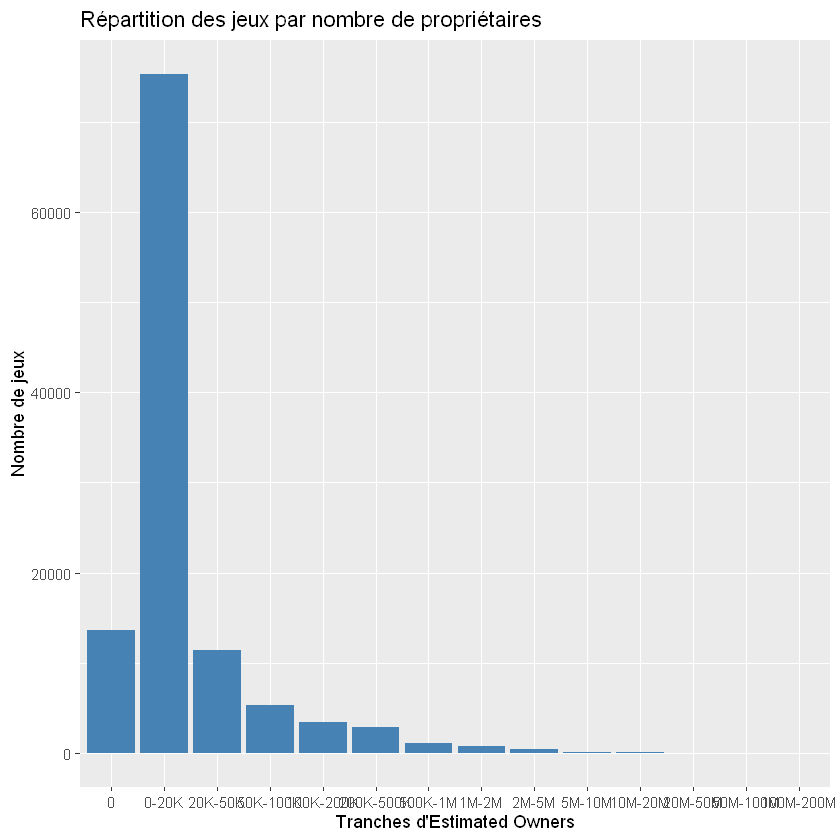

In [26]:
ggplot(data_ready, aes(x = Estimated.owners)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Répartition des jeux par nombre de propriétaires",
       x = "Tranches d'Estimated Owners",
       y = "Nombre de jeux")

On choisit pour l'instant d'analyser les caractéristiques des jeux avec plus de 50 millions d'utilisateurs soit 13 jeux d'après la table.

In [27]:
popular = data_ready %>% filter(Estimated.owners %in% c("50M-100M", "100M-200M")) %>% arrange(desc(Estimated.owners))

In [28]:
print(popular)

                        Name Release.date Estimated.owners Required.age
1              Apex Legends™         2020        100M-200M            0
2           Counter-Strike 2    1997-2013        100M-200M            0
3                     Dota 2    1997-2013        100M-200M            0
4        PUBG: BATTLEGROUNDS         2017        100M-200M           13
5         Black Myth: Wukong         2024         50M-100M           13
6              Call of Duty®         2022         50M-100M           17
7  Grand Theft Auto V Legacy         2015         50M-100M           17
8              Left 4 Dead 2    1997-2013         50M-100M            0
9                   Lost Ark         2022         50M-100M           17
10       New World: Aeternum         2021         50M-100M            0
11                  Palworld         2024         50M-100M            0
12           Team Fortress 2    1997-2013         50M-100M            0
13                  Unturned         2017         50M-100M      

On ne peut tirer des analyses que sur certaines variables:
- Le prix: Les 4 jeux avec plus de 100M d'utilisateurs sont gratuits, pour les jeux entre 50M et 100M il y a tout de même près de la moitié des jeux payant
- Les jeux sont tous présents sur windows (la plupart des jeux le sont même les moins populaires)
- Linux : 6 jeux sur 13 le supportent. C'est un taux très élevé par rapport à la moyenne du reste (13% pour tous les jeux contre 46% pour les jeux populaires), ce qui montre que ces jeux cherchent à être accessibles partout.
- Les métracritics scores sont élevées (plus de 88) mais 8/13 jeux ne sont pas notés. Metacritic ne note que les jeux qui ont reçu suffisamment de critiques de la part de la presse spécialisée au moment de leur sortie. Peut-être que certains jeux très populaires ont bâti leur succès sur le bouche-à-oreille et les évaluations joueurs plutôt que sur la presse traditionnelle.
- On retrouve beaucoup de AAA publishers : Electronic Arts, Valve, KRAFTON Inc.,Activision
- Tous les jeux ont le genre "action", beaucoup ont "free to play", "adventure"...
- Nb de langues quand même assez élevé pour les 4 premiers mais pas forcément pour les autres ( exemple 1 seule langue pour le dernier)

Pour y voir clair, on va comparer les moyennes des variables quatitatives entre le TOP 13 et le data set global.

In [29]:
summary(popular)

     Name              Release.date  Estimated.owners  Required.age
 Length:13          1997-2013:4     50M-100M :9       0      :8    
 Class :character   2017     :2     100M-200M:4       17     :3    
 Mode  :character   2022     :2     0        :0       13     :2    
                    2024     :2     0-20K    :0       1      :0    
                    2015     :1     20K-50K  :0       3      :0    
                    2020     :1     50K-100K :0       6      :0    
                    (Other)  :1     (Other)  :0       (Other):0    
    Discount       Windows      Mac       Linux   Metacritic.score   User.score
 Min.   : 0.000   False: 0   False:11   False:8   Min.   : 0       Min.   :0   
 1st Qu.: 0.000   True :13   True : 2   True :5   1st Qu.: 0       1st Qu.:0   
 Median : 0.000                                   Median : 0       Median :0   
 Mean   : 5.385                                   Mean   :35       Mean   :0   
 3rd Qu.: 0.000                                   3rd Qu

In [30]:
# 1. Liste des variables quantitatives à comparer (celles de ta photo)
vars_to_compare <- c("LPositive", "LNegative", "LRecommendations", "LPeak.CCU", 
                     "LDLC.count", "LPrice", "LAverage.playtime.forever", 
                     "LMedian.playtime.forever", "LLanguageCount","Discount","Metacritic.score","User.score",
                     "Achievements","Average.playtime.two.weeks","Median.playtime.two.weeks")

# 2. Calcul des moyennes pour data_ready
mean_ready <- data_ready %>%
  summarise(across(all_of(vars_to_compare), \(x) mean(x, na.rm = TRUE))) %>%
  pivot_longer(everything(), names_to = "Variable", values_to = "Moyenne_Ready")

# 3. Calcul des moyennes pour popular
mean_popular <- popular %>%
  summarise(across(all_of(vars_to_compare), \(x) mean(x, na.rm = TRUE))) %>%
  pivot_longer(everything(), names_to = "Variable", values_to = "Moyenne_Popular")

# 4. Fusion des deux et calcul de la différence en %
tableau_comparatif <- left_join(mean_ready, mean_popular, by = "Variable") %>%
  mutate(Augmentation_Pct = round(((Moyenne_Popular - Moyenne_Ready) / Moyenne_Ready) * 100, 2))

# Affichage du tableau
print(tableau_comparatif)

# A tibble: 15 × 4
   Variable                   Moyenne_Ready Moyenne_Popular Augmentation_Pct
   <chr>                              <dbl>           <dbl>            <dbl>
 1 LPositive                         2.42            13.6              462. 
 2 LNegative                         1.58            11.9              652. 
 3 LRecommendations                  1.17            12.1              935. 
 4 LPeak.CCU                         0.356           10.9             2958. 
 5 LDLC.count                        0.158            0.918            480. 
 6 LPrice                            1.31             0.959            -26.7
 7 LAverage.playtime.forever         1.20             9.22             670. 
 8 LMedian.playtime.forever          1.17             7.50             542. 
 9 LLanguageCount                    1.46             2.84              93.6
10 Discount                         19.6              5.38             -72.6
11 Metacritic.score                  2.70            35  

- Nombre de Langues (LanguageCount) : Le Top 13 affiche une moyenne de 20 langues contre 7,5 pour l'ensemble du dataset. Cela montre qu'un succès massif passe souvent par une stratégie de localisation mondiale agressive.

- Systèmes d'Exploitation : Alors que moins de 14% des jeux Steam supportent Linux dans l'ensemble du dataset (15 672 sur 114 513), près de 38% (5 sur 13) des titres les plus populaires le font. L'universalité technique semble être un prérequis du succès.

- Temps de jeu des deux dernières semaines (Average.playtime.two.weeks) : La moyenne est de 826 minutes (soit près de 14 heures par quinzaine) pour les jeux populaires, contre une moyenne globale de seulement 14,7 minutes. Cela souligne que les jeux populaires sont des "aspirateurs de temps" qui occupent les joueurs de manière continue.

- DLC (DLC.count) : Le Top 13 propose en moyenne 4,6 DLC par jeu, contre 0,55 globalement. Même les jeux gratuits du top (comme Apex Legends ou Dota 2) utilisent ces contenus additionnels pour enrichir l'expérience et monétiser l'audience.

- Recommandations (Recommendations) : C'est l'écart le plus vertigineux. Une moyenne de 862 000 recommandations pour le Top 13 contre seulement 954 pour la moyenne générale. Le succès sur Steam s'auto-alimente : plus un jeu est recommandé, plus il est visible, plus il attire d'utilisateurs.

- Scores Critiques (Metacritic.score) : Bien que beaucoup ne soient pas notés, la moyenne du Top 13 est de 35 (incluant les zéros) contre 2,7 globalement. Si l'on ne regarde que les jeux notés, le Top 13 se situe toujours dans l'excellence (>88).

In [34]:
top_13_genres <- popular %>%
  separate_rows(Genres, sep = ",") %>%
  mutate(Genres = str_trim(Genres)) %>%
  dplyr::count(Genres, sort = TRUE) #parce que il existe aussi une fonction count dans une autre librairie

top_13_genres

Genres,n
<chr>,<int>
Action,13
Adventure,8
Free To Play,7
RPG,4
Massively Multiplayer,3
Indie,2
Casual,1
Early Access,1
Strategy,1


In [35]:
top_13_categories <- popular %>%
  separate_rows(Categories, sep = ",") %>%
  mutate(Categories = str_trim(Categories)) %>%
  dplyr::count(Categories, sort = TRUE)

head(top_13_categories,10)

Categories,n
<chr>,<int>
Multi-player,12
Steam Achievements,10
Co-op,9
Camera Comfort,8
Custom Volume Controls,8
In-App Purchases,8
Online Co-op,8
Online PvP,8
Playable without Timed Input,8


In [36]:
top_13_langue <- popular %>%
  separate_rows(Language, sep = ",") %>%
  mutate(Language = str_trim(Language)) %>%
  dplyr::count(Language, sort = TRUE)
head(top_13_langue,10)

Language,n
<chr>,<int>
English,23
Spanish-Spain,17
French,15
German,15
SimplifiedChinese,14
Italian,13
Portuguese-Brazil,13
Spanish-Latimerica,13
Japanese,12


# CA

On va maintenant essayer de mettre en évidence la relation entre Estimated.owners et Genres à travers une CA. Pour ce faire il faut d'abord séparer et bien encoder les genres.

In [37]:
data_prep <- data_ready %>%
  select(Genres, Estimated.owners) %>%
  separate_rows(Genres, sep = ",") %>%
  mutate(Genres = trimws(Genres)) %>% #On enlève les espaces devant ou après mot
  filter(Genres != "") # On enlève les genres vides pour que le tableau de crée pas un genre ""

# Tableau de contingence
data_ca <- table(data_prep$Genres, data_prep$Estimated.owners)

In [38]:
head(data_ca,15)

                       
                            0 0-20K 20K-50K 50K-100K 100K-200K 200K-500K
  360 Video                 0     1       0        0         0         0
  Accounting                6    18       1        3         2         0
  Action                 4907 30032    4703     2252      1482      1338
  Adventure              4778 29338    5022     2322      1496      1141
  Animation & Modeling     67   342      26       13        12         7
  Audio Production         23   170      15        4         8         3
  Casual                 6596 35254    4350     1786      1049       740
  Design & Illustration    51   446      30       16        19         9
  Documentary               0     1       0        0         0         0
  Early Access           1350  7921     889      411       238       159
  Education                59   352      27        6         8         5
  Episodic                  0     1       0        0         0         0
  Free To Play           63

In [39]:
print(rowSums(data_ca))

            360 Video            Accounting                Action 
                    1                    30                 46155 
            Adventure  Animation & Modeling      Audio Production 
                45104                   477                   225 
               Casual Design & Illustration           Documentary 
                50192                   580                     1 
         Early Access             Education              Episodic 
                11091                   461                     1 
         Free To Play      Game Development                  Gore 
                12160                   320                   256 
                Indie Massively Multiplayer                 Movie 
                80610                  2525                     2 
               Nudity         Photo Editing                Racing 
                   94                   180                  4077 
                  RPG        Sexual Content                 Sh

Pb: Certains genres sont sous représentés comme 360 Video, Documentary,Episodic,Short,Movie, Tutorial qui n'apparaissentqu'une fois ou Accounting que 30 fois. Cela va poser problème poure l'interprétaion de la CA puisque celle-ci repose sur distance du Chi-deux qui accorde un poids très important aux petits effectifs. On va quand même réaliser la CA et voir ce que cela donne puis on décidera peut-être de ne pas étudier certains genres sous représentés. Une autre idée serait de regrouper les genres en sous effectifs mais cela n'a pas de sens niveau interprétation.

D'après Lukas, les jeux dans 360 Video, Documentary,Episodic, short et movies sont les mêmes (2 jeux ), on les supprime donc pour l'analyse. Et on va regrouper les jeux selon les groupes qu'il a trouvé.

In [51]:
data_genres <- data_ready %>%
  separate_rows(Genres, sep = ",") %>%
  mutate(presence = 1, Genres = paste0("Genres_", Genres)) %>%
  pivot_wider(names_from = Genres, values_from = presence, values_fill = 0)
data_genres <- data_genres %>%
  mutate(
    Genres_Mature = if_else(Genres_Gore == 1 | 
                           Genres_Nudity == 1 | 
                           `Genres_Sexual Content` == 1 | 
                           Genres_Violent == 1, 1, 0),

    #Pas besoin du Genre vidéo
      
    Genres_Outils = if_else(`Genres_Video Production` == 1 | 
                           `Genres_Design & Illustration` == 1 | 
                           `Genres_Animation & Modeling` == 1 | 
                           `Genres_Game Development` == 1 | 
                           `Genres_Audio Production` == 1 | 
                           `Genres_Photo Editing` == 1 | 
                           `Genres_Software Training` == 1 | 
                           Genres_Education == 1 | 
                           Genres_Utilities == 1 | 
                           `Genres_Web Publishing` == 1, 1, 0)
  ) %>%
  mutate(across(starts_with("Genres_"), as.factor))

cols_to_remove <- c("Genres_Gore", "Genres_Violent", "Genres_Video Production","Genres_Sexual Content","Genres_Nudity",
                    "Genres_Design & Illustration", "Genres_Animation & Modeling","Genres_Game Development",
                    "Genres_Audio Production","Genres_Photo Editing", "Genres_Software Training",
                    "Genres_Education", "Genres_Utilities", "Genres_Web Publishing","Genres_Movie","Genres_","Genres_360 Video","Genres_Tutorial","Genres_Short",
                   "Genres_Episodic","Genres_Documentary")

data_genres <- data_genres %>%
  select(-all_of(cols_to_remove))
summary(data_genres)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

In [54]:
# 1. On repart de data_genres et on ne garde que les colonnes qui nous intéressent
tab_contingence_genres <- data_genres %>%
  # On sélectionne les colonnes de genres (ex: Action, RPG, Outils...) et la variable cible
  select(Estimated.owners, starts_with("Genres_")) %>%
  # On transforme le tableau pour avoir une ligne par genre par jeu
  pivot_longer(cols = starts_with("Genres_"), 
               names_to = "Genre", 
               values_to = "Presence") %>%
  # On ne garde que les lignes où le genre est présent (Presence == 1)
  # Note : Si Presence est un facteur, utilise Presence == "1"
  filter(Presence == 1 | Presence == "1") %>%
  # On nettoie le nom du genre pour enlever le préfixe "Genres_"
  mutate(Genre = gsub("Genres_", "", Genre))

# 2. On crée le tableau de contingence final
data_ca_genres <- table(tab_contingence_genres$Genre, tab_contingence_genres$Estimated.owners)

# Affichage
print(data_ca_genres)

                       
                            0 0-20K 20K-50K 50K-100K 100K-200K 200K-500K
  Accounting                6    18       1        3         2         0
  Action                 4907 30032    4703     2252      1482      1338
  Adventure              4778 29338    5022     2322      1496      1141
  Casual                 6596 35254    4350     1786      1049       740
  Early Access           1350  7921     889      411       238       159
  Free To Play           6327  3236     926      541       410       350
  Indie                  8918 54440    8282     3710      2280      1816
  Massively Multiplayer   618  1068     231      152       119       134
  Mature                    4   428      43       24        12         7
  Outils                  270  1351     105       45        43        25
  Racing                  489  2753     346      194       122        97
  RPG                    2438 12509    2473     1340       828       694
  Simulation             28

### Test d'indépendance pour vérifier la pertinence de la CA

In [83]:
head(tab_contingence_genres,10)

Estimated.owners,Genre,Presence
<fct>,<chr>,<fct>
0-20K,Action,1
0-20K,Indie,1
0-20K,RPG,1
0-20K,Early Access,1
50K-100K,Action,1
50K-100K,Indie,1
50K-100K,Adventure,1
50K-100K,Casual,1
0-20K,Action,1


In [84]:
# 2. Réalisation du test du Khi-deux
test_result <- chisq.test(data_ca_genres)

# 3. Affichage du résultat
print(test_result)

Warning message in chisq.test(data_ca_genres):
"L’approximation du Chi-2 est peut-être incorrecte"



	Pearson's Chi-squared test

data:  data_ca_genres
X-squared = 22327, df = 182, p-value < 2.2e-16



On a un warning car certaines cases de tableau de contingences ont des effectifs théoriques très faibles. Mais comme ce n'est pas le cas pour toutes on considère le resultat plausible. On observe une p-valeur très faible donc on rejette l'hypothèse d'indépendance au niveau 1%. Faire une CA a donc du sens.

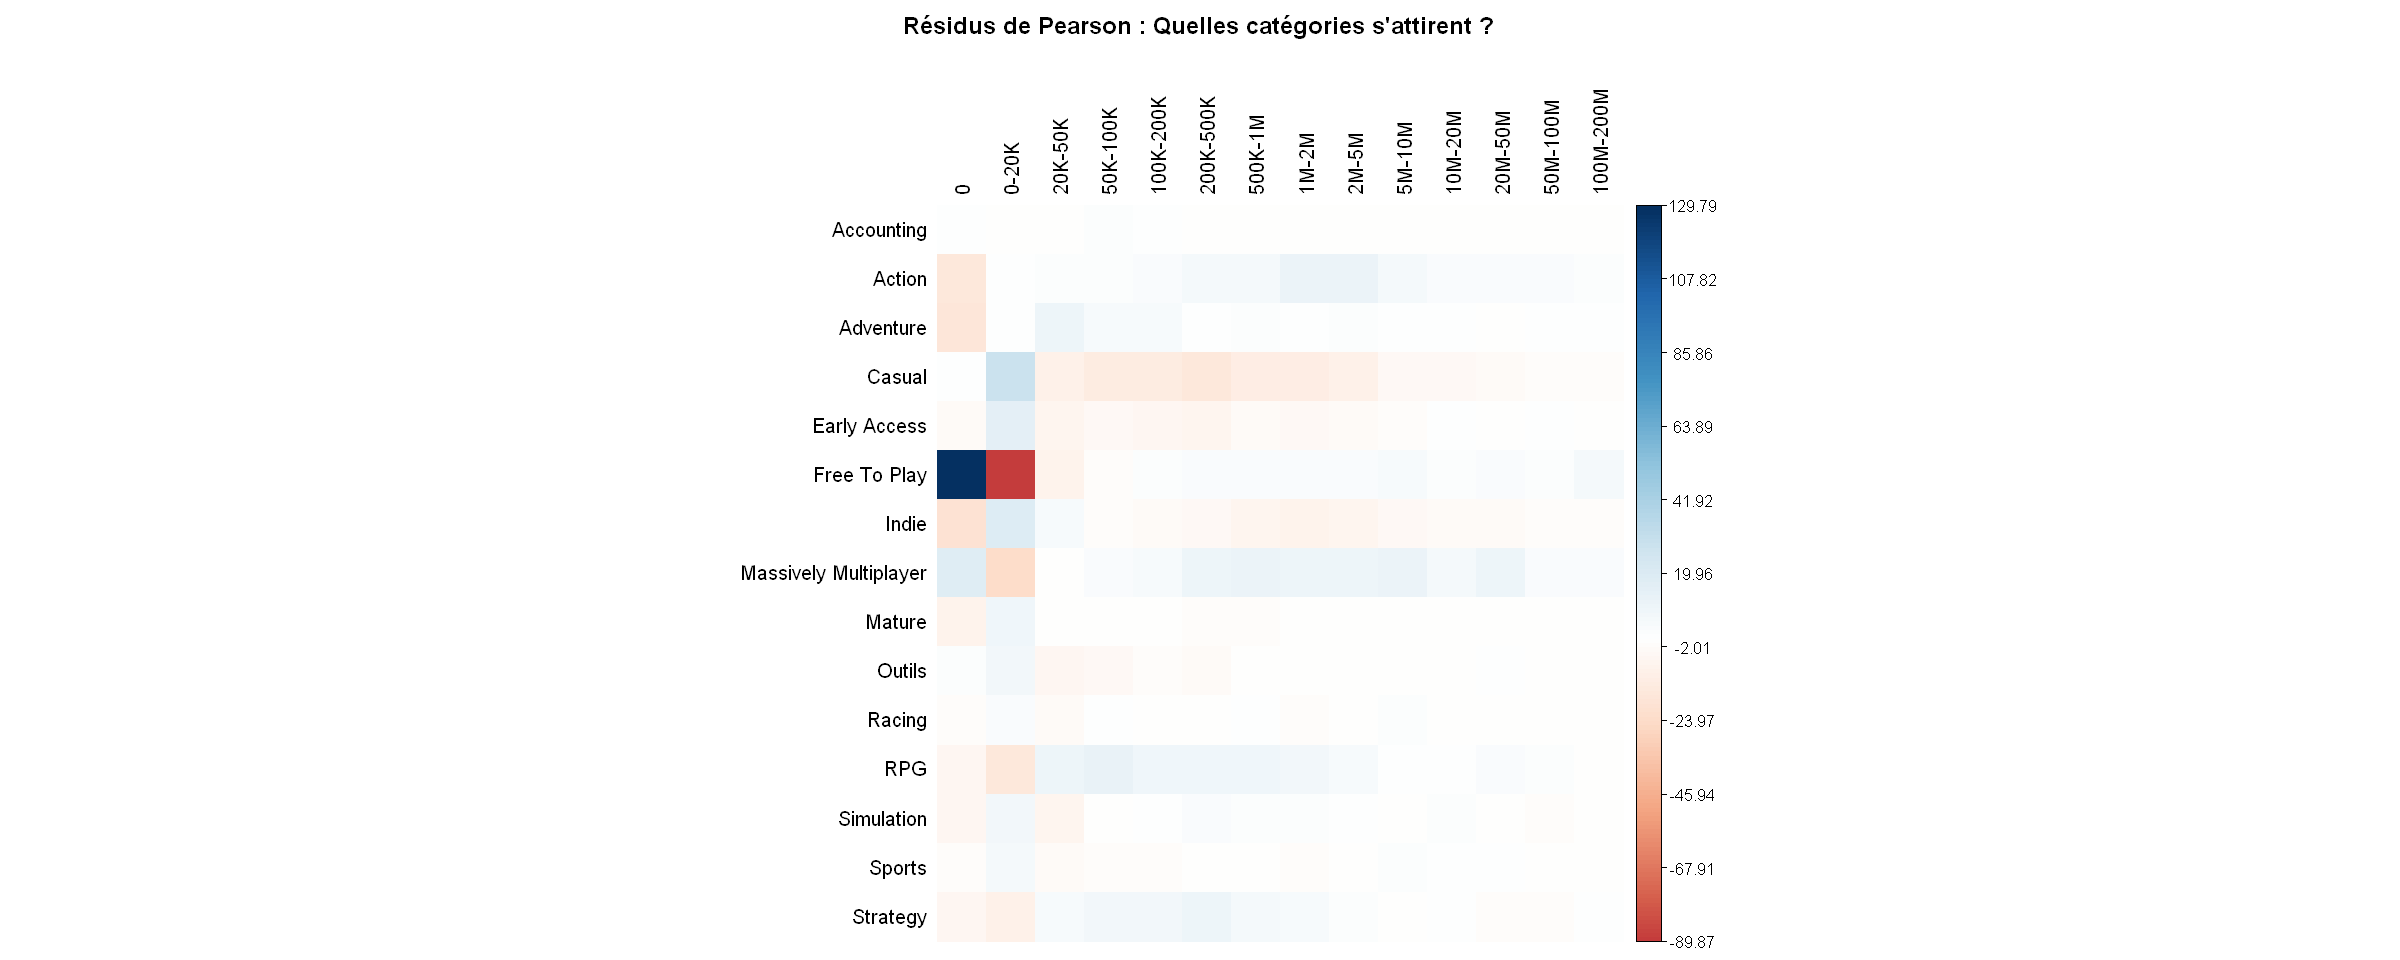

In [85]:
residus <- test_result$stdres

# Visualisation élégante des résidus
corrplot(residus, is.cor = FALSE, 
         method = "color", 
         tl.col = "black", 
         title = "Résidus de Pearson : Quelles catégories s'attirent ?",
         mar = c(0,0,2,0))

En statistiques, on considère généralement qu'un résidu est significatif lorsqu'il dépasse 2 ou est inférieur à -2.

Dans le graphique, la valeur de 129.79 pour le lien Free To Play / Tranche 0 est astronomique. Cela prouve que cette association est le moteur principal de la dépendance dans tes données.

Les nuances plus claires (autour de 20 ou 40) restent des liens extrêmement puissants à l'échelle statistique.

Le test d'indépendance du Khi-deux confirme l'existence d'un lien hautement significatif entre le genre et le volume d'utilisateurs. L'analyse des résidus de Pearson (Corrplot) vient valider les observations de l'Analyse des Correspondances : on observe une spécialisation des genres "Massively Multiplayer" et "RPG" dans les segments de succès massif, tandis que le modèle "Free To Play" présente un profil bimodal atypique, étant fortement corrélé soit à l'absence totale d'owners (tranche 0), soit aux succès extrêmes.

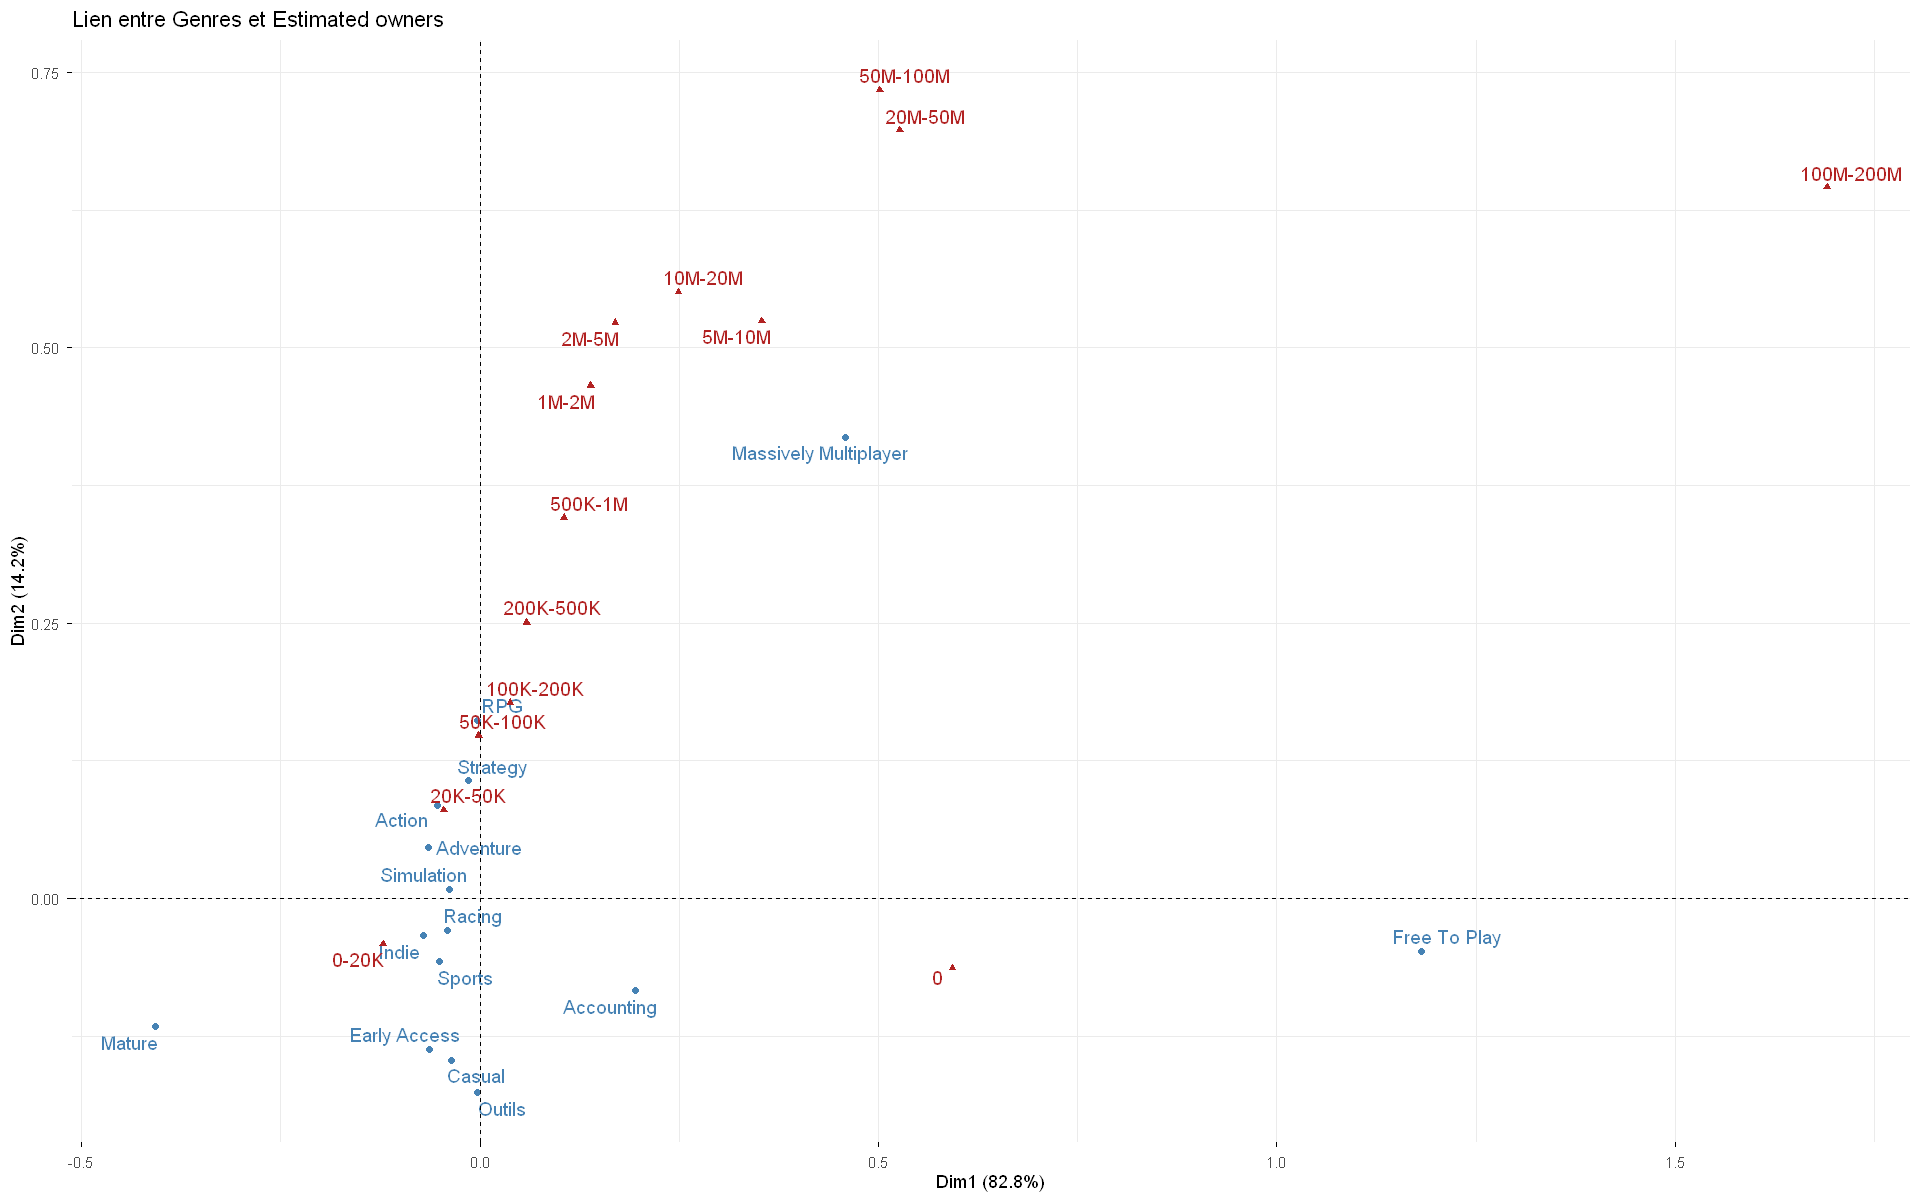

In [56]:
ca <- CA(data_ca_genres, graph = FALSE)
options(repr.plot.width = 16, repr.plot.height =10)
fviz_ca_biplot(ca, 
               repel = TRUE, 
               col.row = "steelblue", 
               col.col = "firebrick", 
               title = "Lien entre Genres et Estimated owners")

In [57]:
ca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,5.659973e-02,8.280148e+01,82.80148
dim 2,9.704390e-03,1.419685e+01,96.99833
dim 3,1.417225e-03,2.073301e+00,99.07163
dim 4,3.577115e-04,5.233070e-01,99.59493
dim 5,1.288013e-04,1.884274e-01,99.78336
dim 6,7.026386e-05,1.027911e-01,99.88615
dim 7,3.346015e-05,4.894988e-02,99.93510
dim 8,1.790654e-05,2.619603e-02,99.96130
dim 9,1.553988e-05,2.273376e-02,99.98403
dim 10,7.347402e-06,1.074874e-02,99.99478


**Qualité de représentation**

In [58]:
ca$row$cos2

,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5
Accounting,0.1642688803,0.030272070,0.0378416165,1.041540e-01,9.885894e-02
Action,0.2359113249,0.577645558,0.1426970816,1.358541e-02,2.882898e-02
Adventure,0.5626682840,0.292866637,0.0940115323,3.978016e-02,1.794871e-05
Casual,0.0564837096,0.932424559,0.0077132950,2.704173e-03,2.267107e-05
Early Access,0.1611197922,0.754059498,0.0569593271,7.436732e-04,8.064357e-03
Free To Play,0.9980490386,0.001643869,0.0002777446,1.425803e-08,2.606295e-05
Indie,0.7272430344,0.169861629,0.0928411442,1.795085e-03,8.364533e-04
Massively Multiplayer,0.4742637900,0.393701710,0.1158449687,4.316985e-03,9.437581e-03
Mature,0.9035318570,0.074352010,0.0033042148,2.500260e-03,2.876055e-03
Outils,0.0002929857,0.638121845,0.2766215771,2.802767e-02,1.665240e-04


Quel est le genre le mieux représenté par l'axe 1 ?

In [67]:
i = 1
idx = which.max(ca$row$cos2[,i])

print(paste("The genre",row.names(data_ca_genres)[idx], "is best represented by axis", i))

[1] "The genre Free To Play is best represented by axis 1"


On affiche la qualité de représentation des genres sur l'espace CA (dim 1-2) ainsi que des tranches d'utilisateurs.

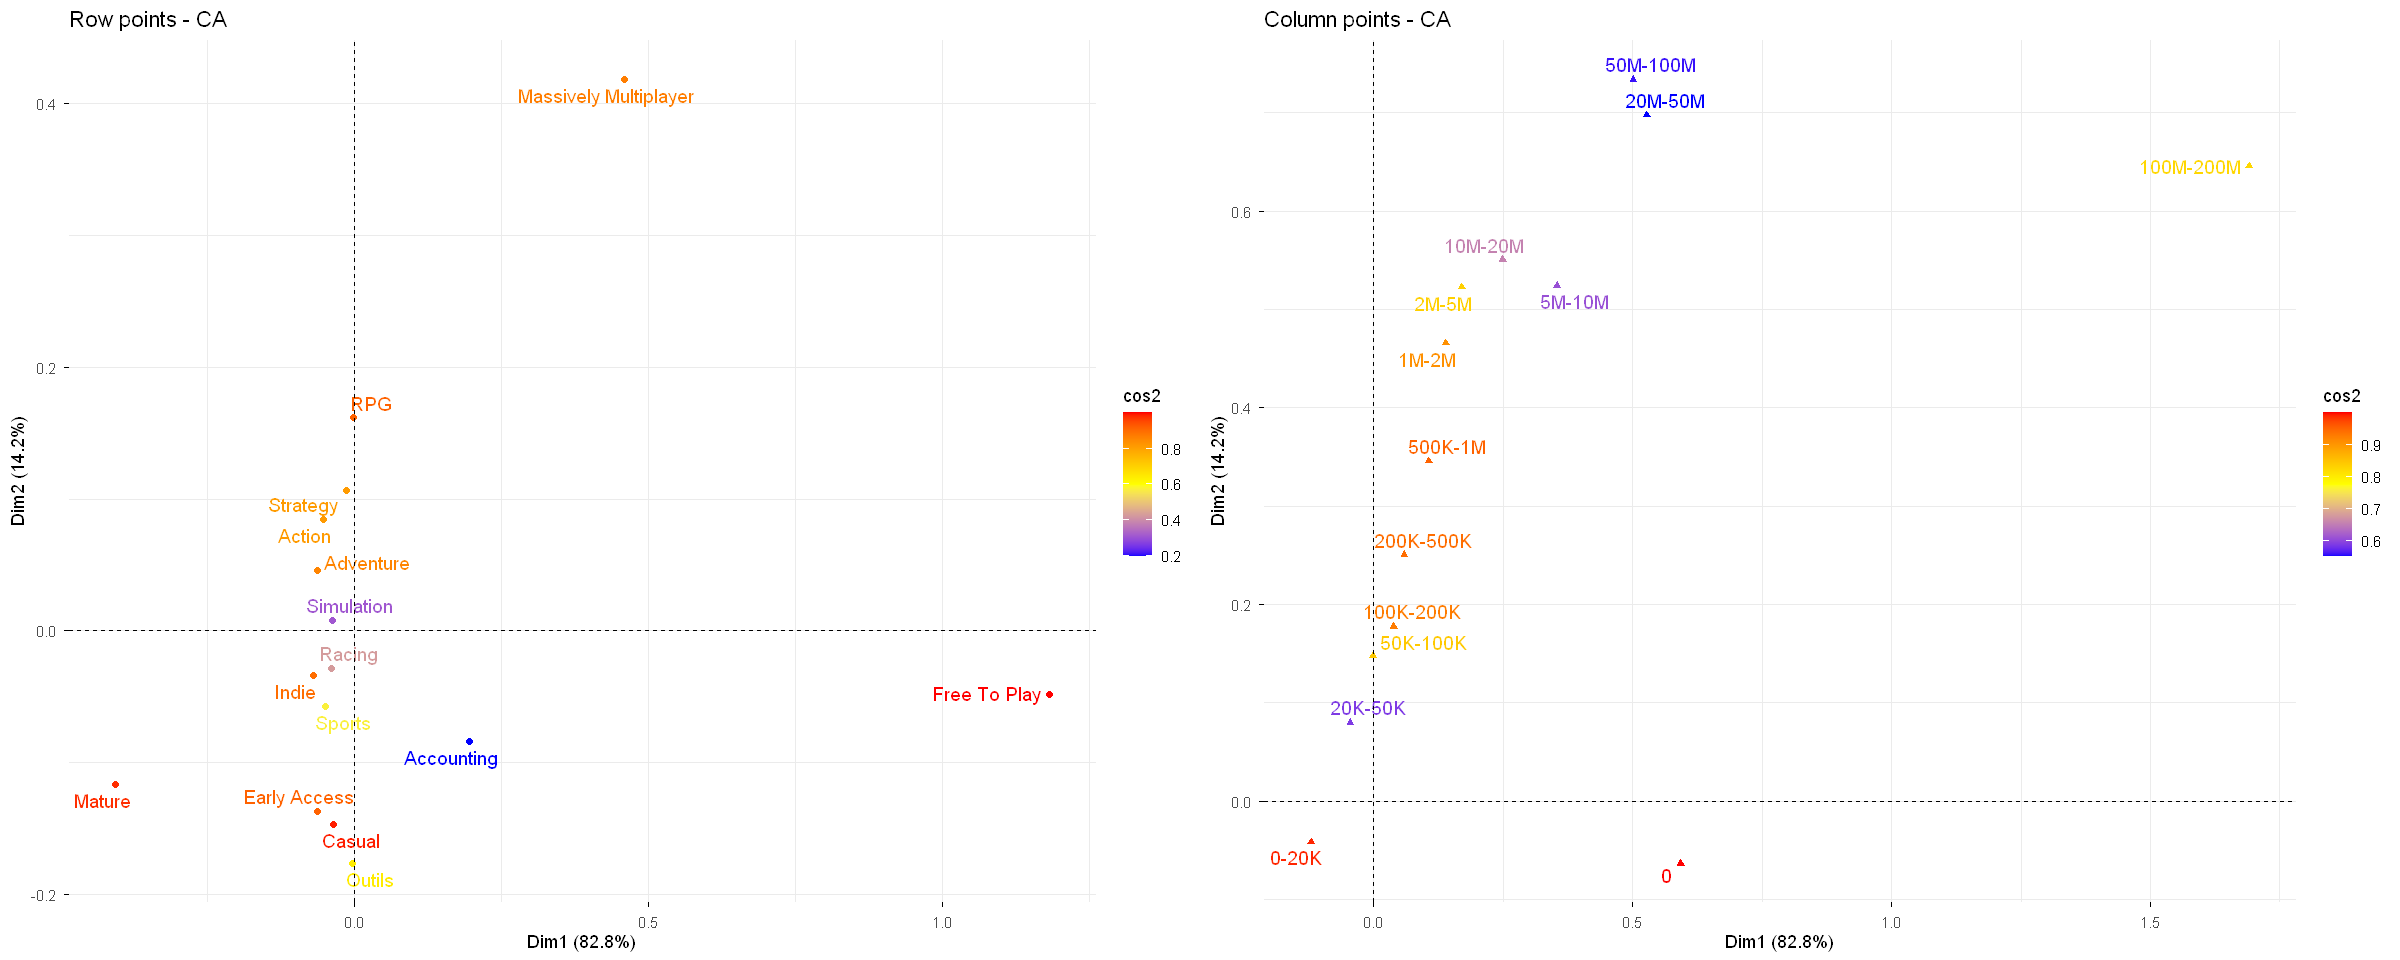

In [79]:
options(repr.plot.width = 20, repr.plot.height =8)
grid.arrange(fviz_ca_row(ca, col.row = "cos2",gradient.cols = c("blue", "yellow", "red"), repel = TRUE),fviz_ca_col(ca, col.col = "cos2",gradient.cols = c("blue", "yellow", "red"), repel = TRUE), ncol=2)

L'analyse de la qualité de représentation (cos²) révèle une structure de marché polarisée. La tranche 100M-200M sature l'Axe 1, confirmant son lien exclusif avec le modèle Free-to-Play malgré le faible effectif de cette catégorie. En revanche, les tranches intermédiaires (20M-100M) présentent une qualité de représentation plus faible ; leur position centrale sur l'Axe 1 suggère qu'elles ne sont pas systématiquement portées par la gratuité, mais constituent un segment hybride. Pour l'immense majorité des autres tranches (inférieures à 5 millions d'utilisateurs), leur proximité avec le centre de l'Axe 1 indique que le volume d'utilisateurs n'est plus le facteur discriminant principal, laissant l'Axe 2 (typologie des genres) expliquer la diversité de leurs profils.

**Contribution aux axes**

Particulièrement utile ici car on a des différences d'effectifs importantes.

Contribution des genres :

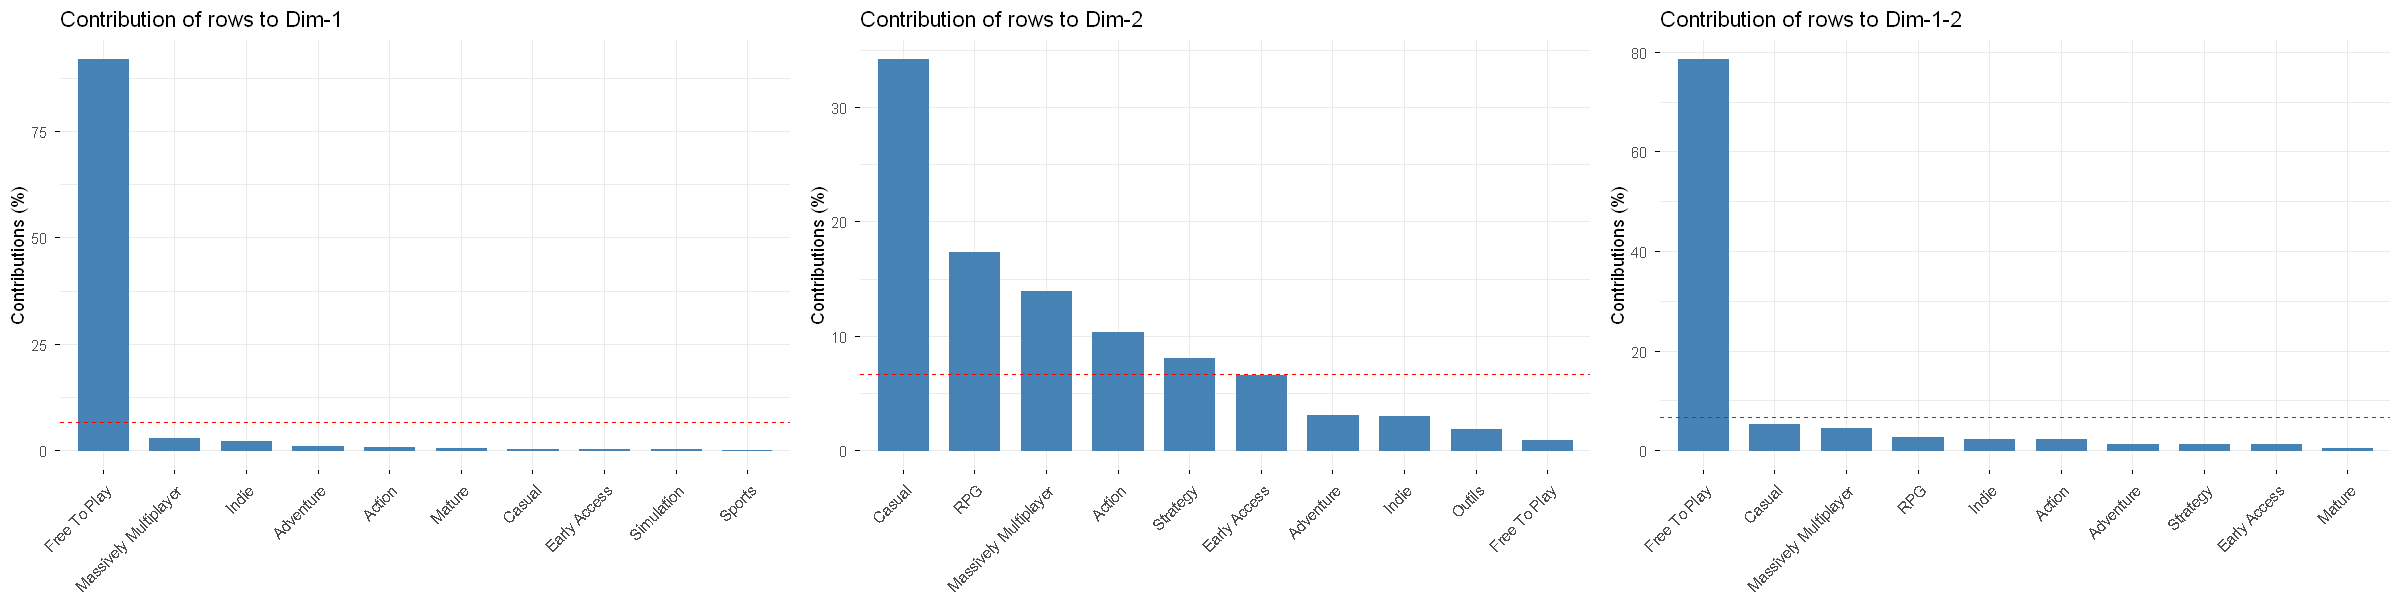

In [61]:
options(repr.plot.width = 20, repr.plot.height =5)
grid.arrange(fviz_contrib(ca, choice = "row", axes = 1, top = 10),fviz_contrib(ca, choice = "row", axes = 2, top = 10),fviz_contrib(ca, choice = "row", axes = 1:2, top = 10),ncol=3)

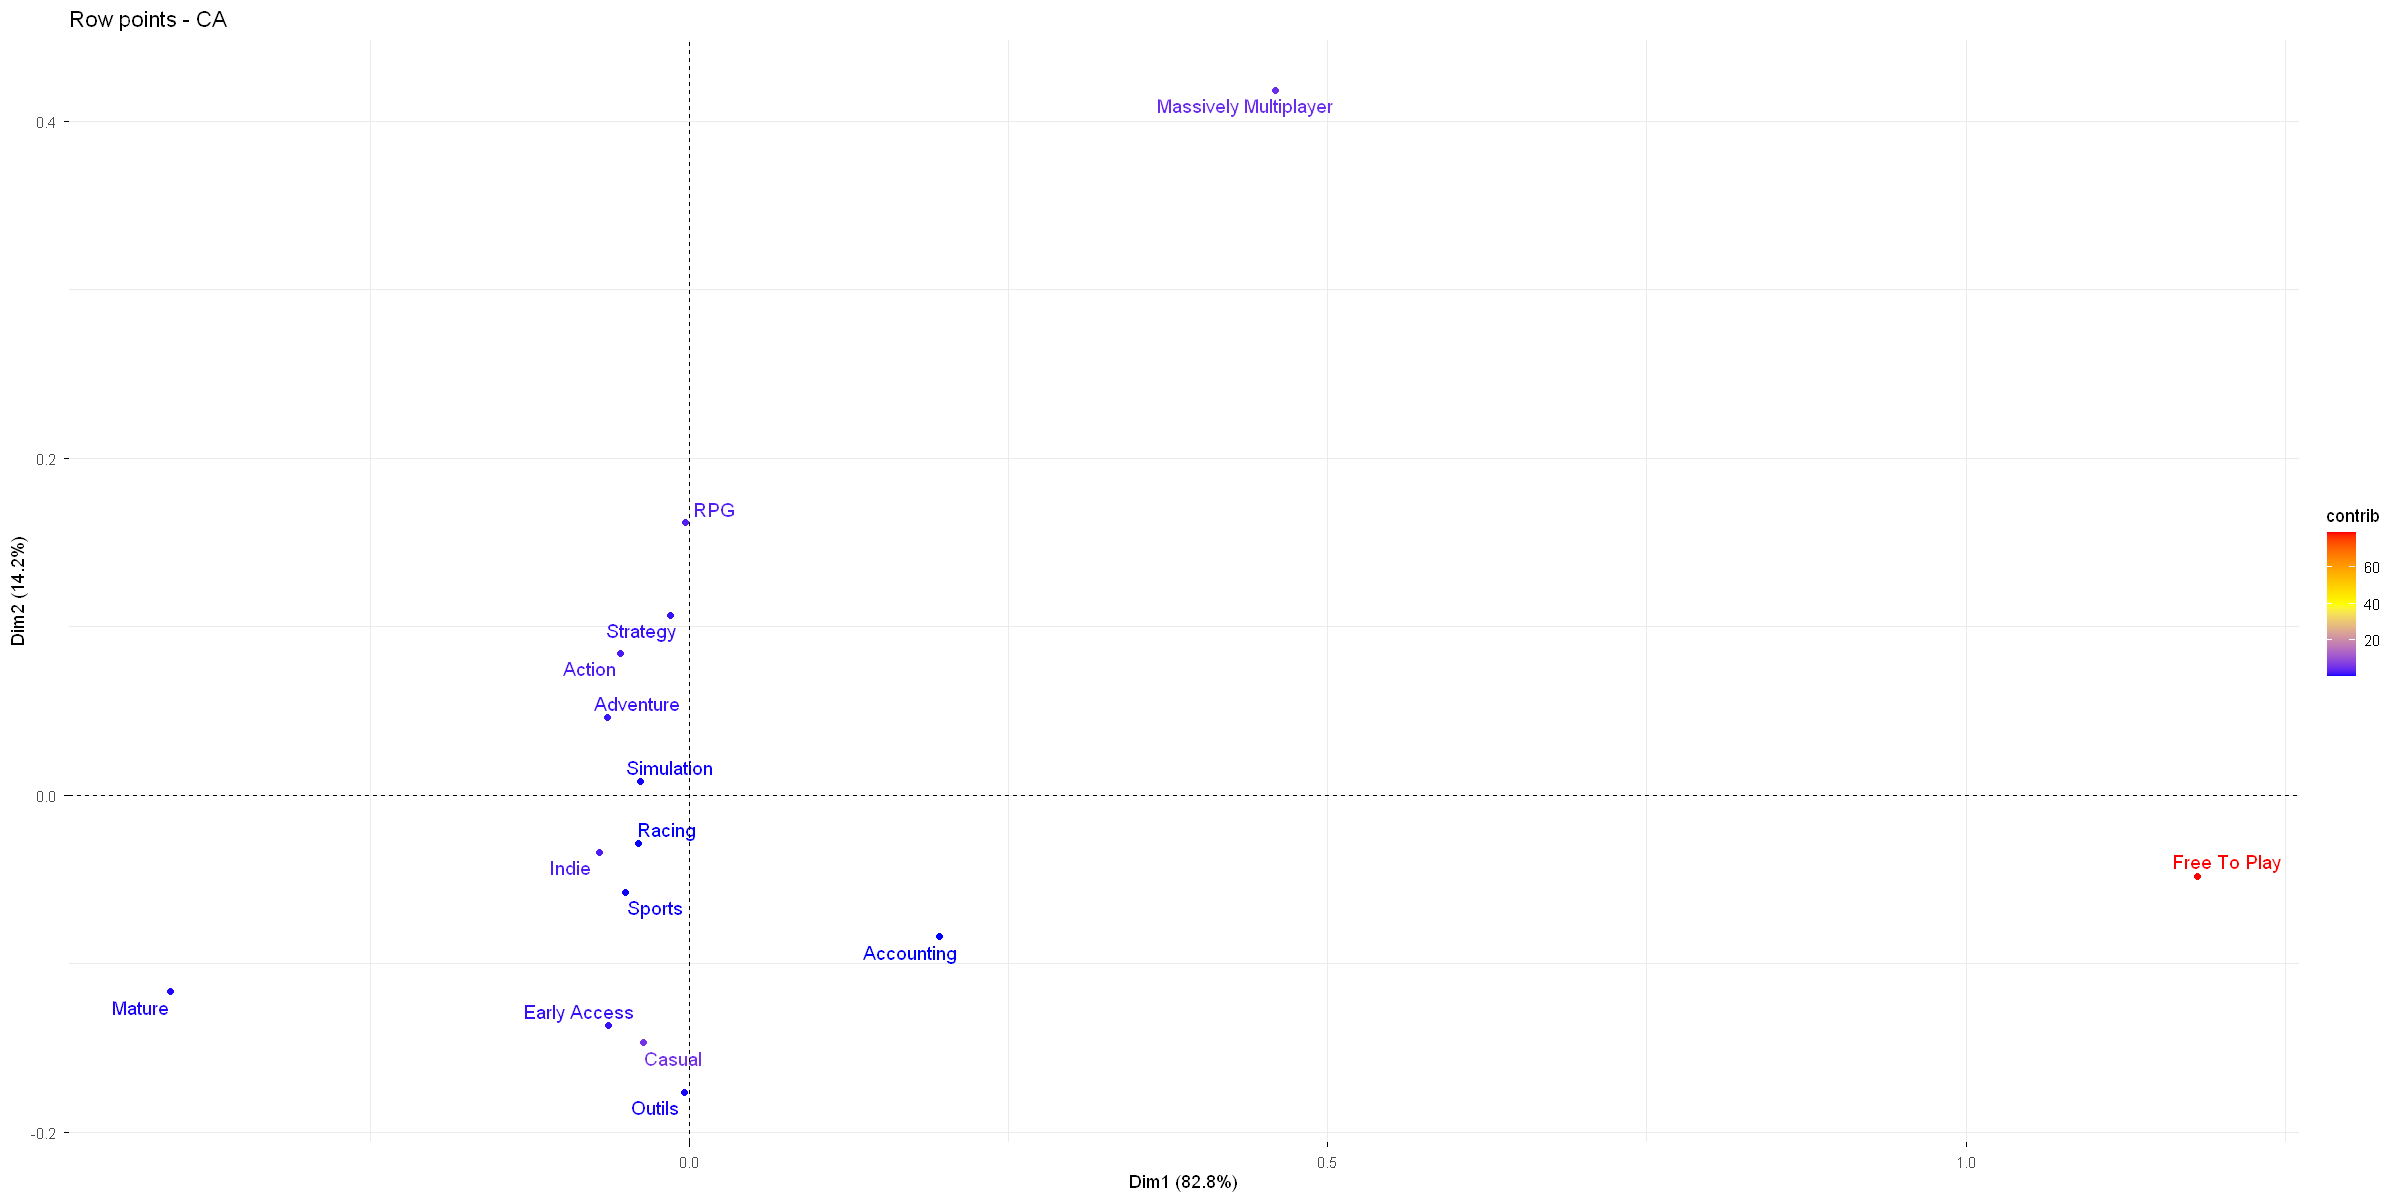

In [62]:
options(repr.plot.width = 20, repr.plot.height =10)
fviz_ca_row(ca, col.row = "contrib",
             gradient.cols = c("blue", "yellow", "red"), 
             repel = TRUE)

Contribution des tranches d'utilisateurs:

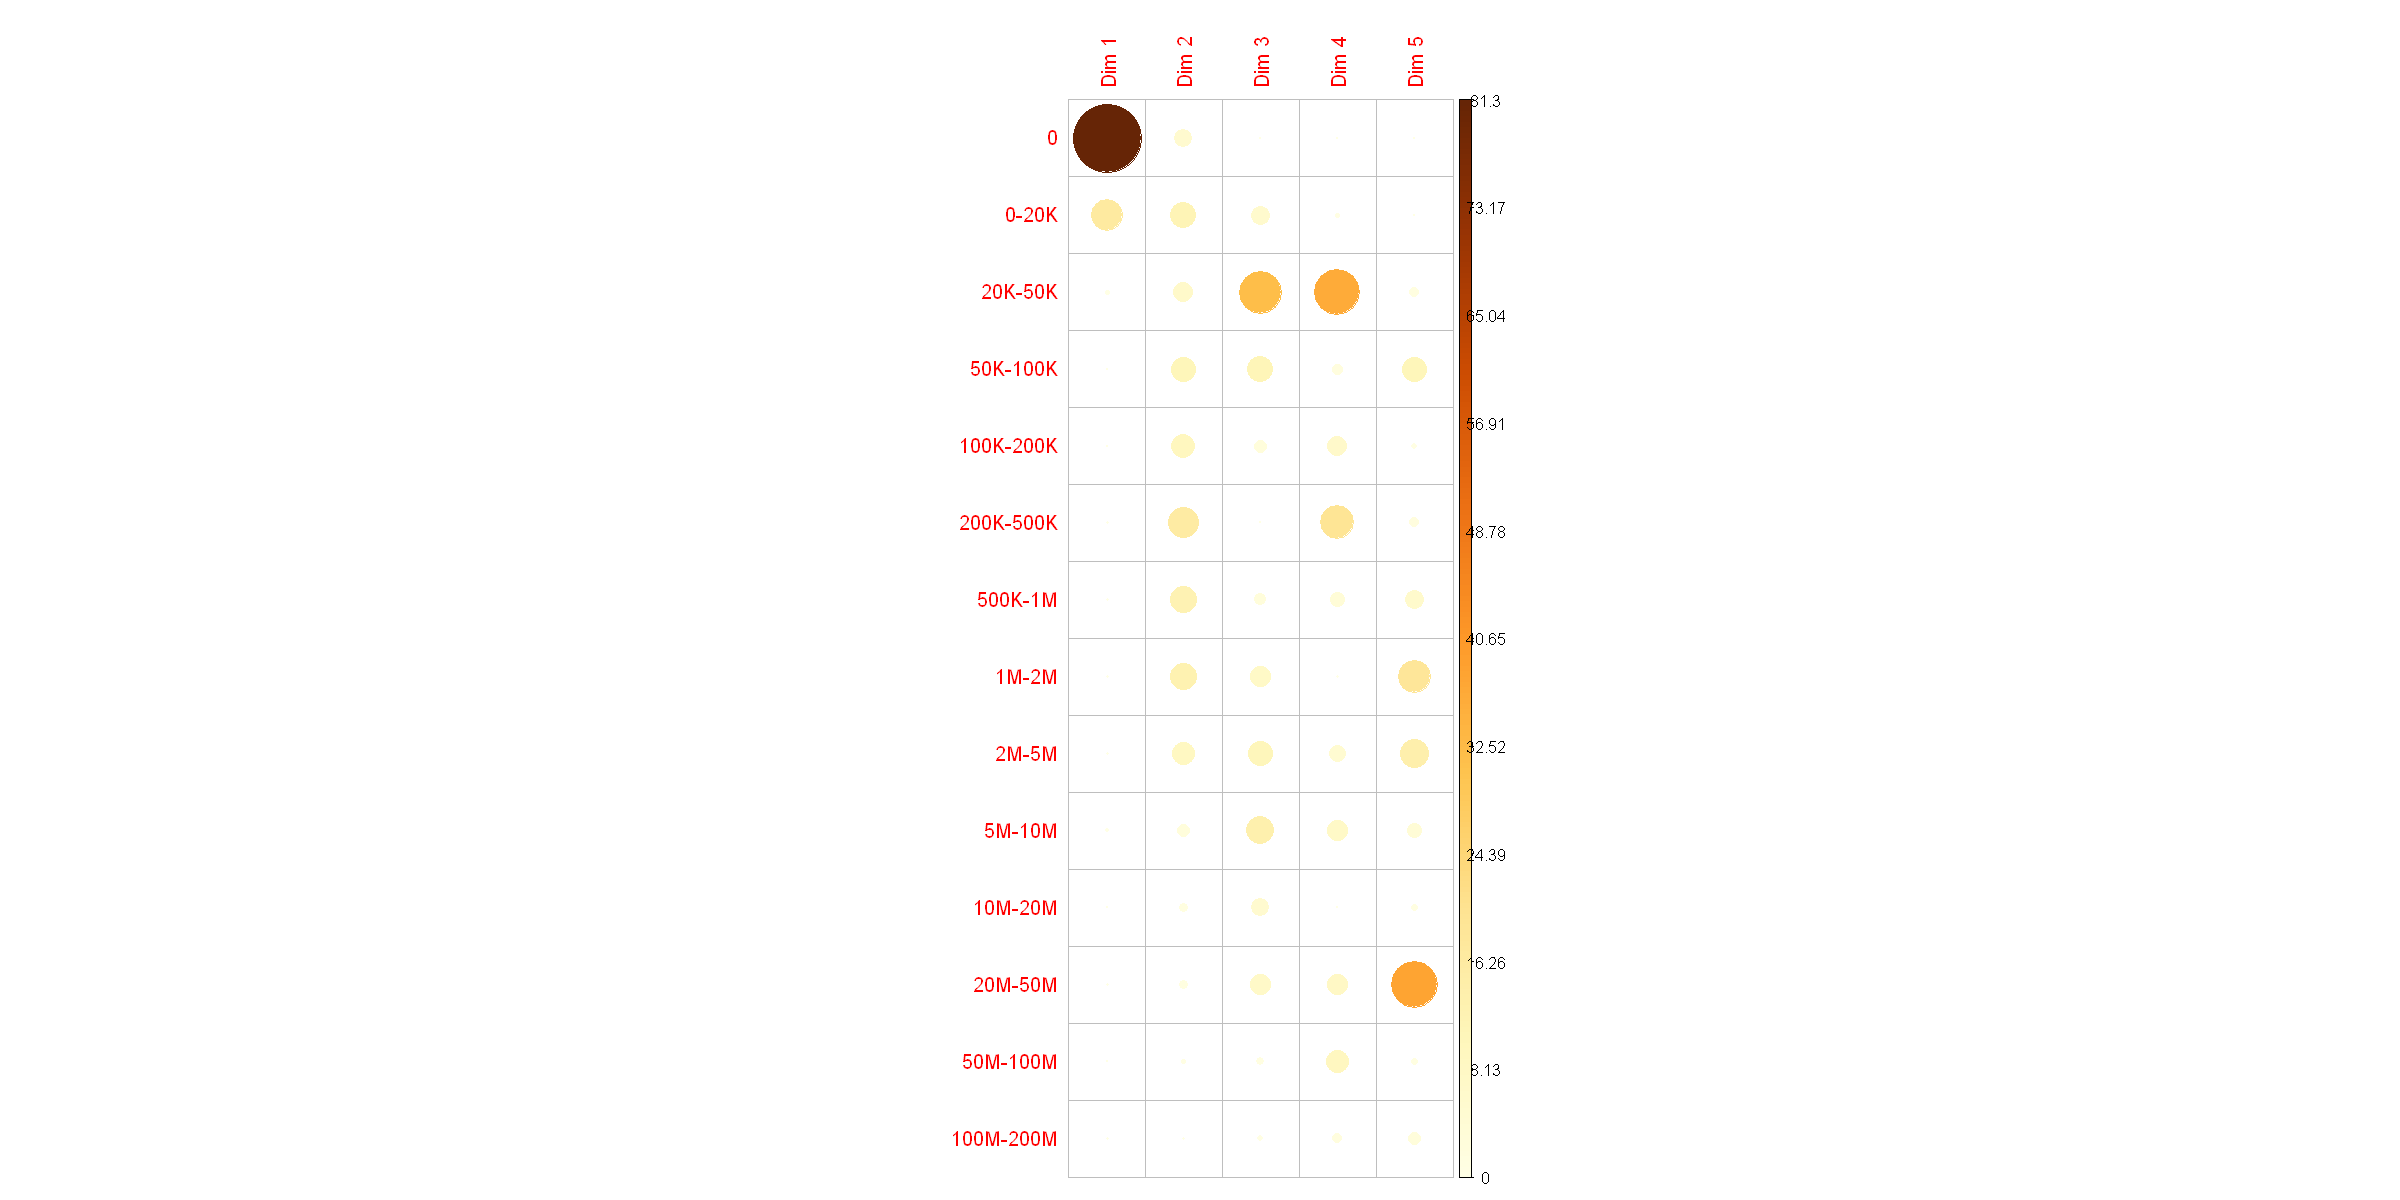

In [63]:
corrplot(ca$col$contrib, is.corr=FALSE)

Une singularité de profil : L'effectif de Free To Play n'est pas petit, il est bien représenté et contribu a lui même à l'axe 1, sa répartition entre les tranches d'utilisateurs est radicalement différente de celle des jeux payants. En CA, un point s'éloigne de l'origine (le centre) s'il s'écarte fortement du "profil moyen".

L'attraction vers les extrêmes : Sur l'axe 1, le Free To Play se projette très loin sur la droite, dans la même direction que la tranche 100M-200M. Cela signifie que, proportionnellement à leur nombre, les jeux gratuits réussissent beaucoup plus souvent à atteindre ces sommets d'audience que les jeux payants. On a bien vu que tout les jeux de cette tranche sont gratuits

L'axe du modèle économique : Le premier graphique montre que la variable la plus structurante de ton jeu de données est l'opposition entre le modèle "Premium" (à gauche, où s'entassent tous les autres genres) et le modèle "Gratuit" (à droite).

Lien avec la tranche "0" : On remarque aussi que le Free To Play est attiré vers le bas de l'axe 2, près de la tranche 0. Cela traduit la réalité brutale du genre : soit le jeu est un succès planétaire (100M+), soit il ne décolle jamais (tranche 0) car il n'y a pas de barrière à l'entrée pour les joueurs, mais aussi aucun revenu garanti à l'achat.

Le genre Free To Play contribue à lui seul à l'axe 1 et donc presque seul au plan 1-2. Cela pose un problème d'interprétation. **Passer Free to play en variable supplémentaire ??**

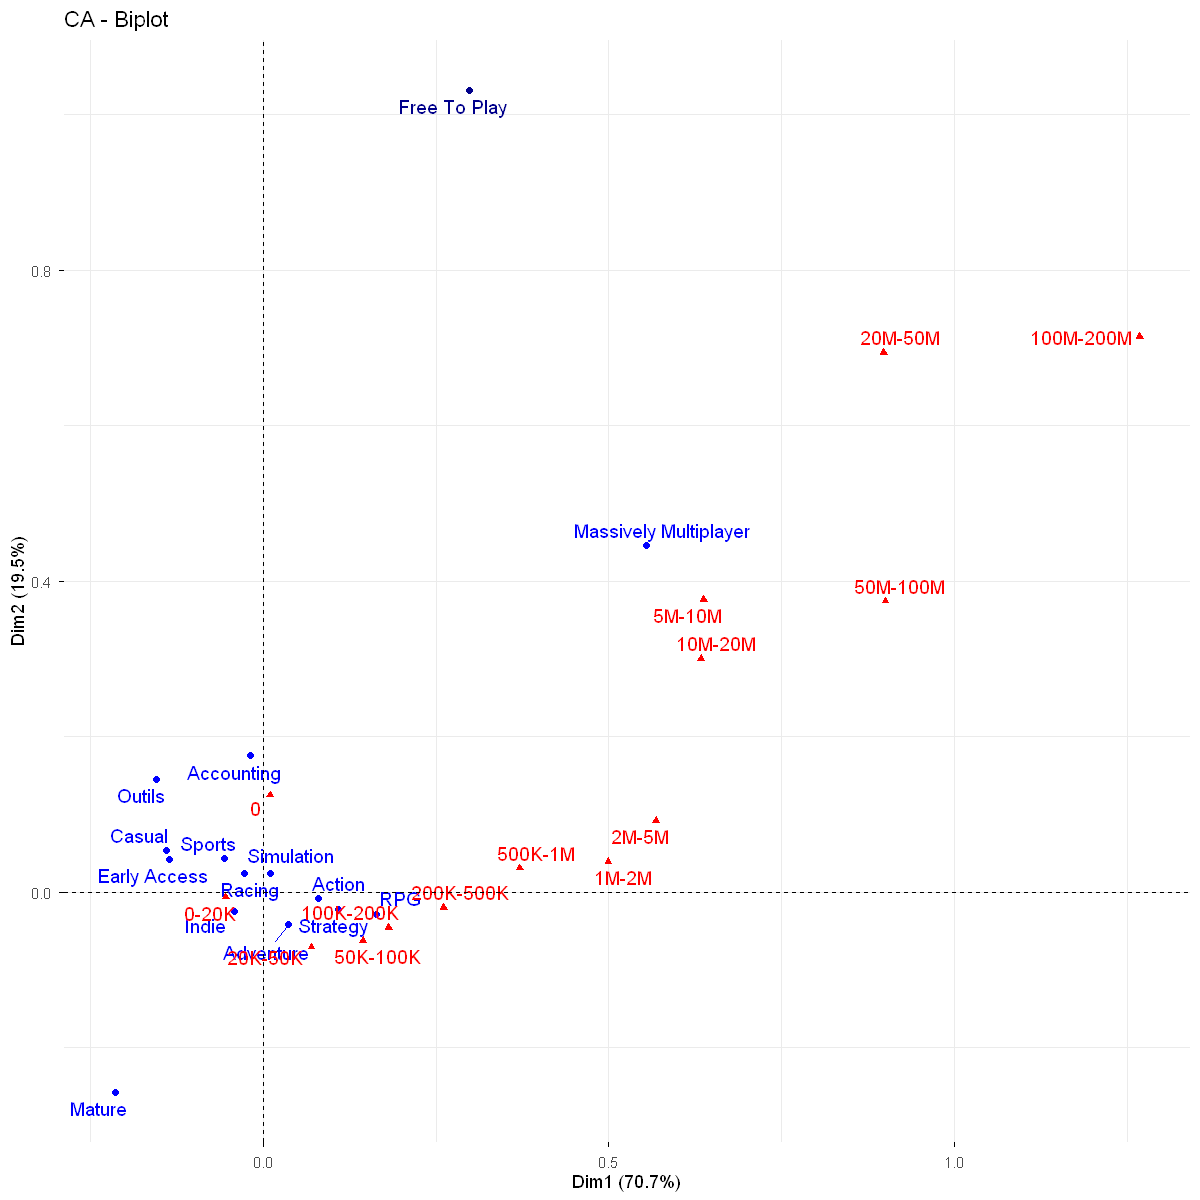

In [73]:
index_ftp <- which(rownames(data_ca_genres) == "Free To Play")

res.ca_sans_ftp <- CA(data_ca_genres, 
                      row.sup = index_ftp, 
                      graph = FALSE)

fviz_ca_biplot(res.ca_sans_ftp, repel = TRUE)

In [74]:
res.ca_sans_ftp$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,1.072721e-02,70.706715418,70.70672
dim 2,2.960211e-03,19.511761175,90.21848
dim 3,8.721056e-04,5.748346136,95.96682
dim 4,3.800967e-04,2.505347075,98.47217
dim 5,9.002233e-05,0.593367953,99.06554
dim 6,6.726099e-05,0.443340183,99.50888
dim 7,2.774321e-05,0.182864965,99.69174
dim 8,1.992905e-05,0.131359188,99.82310
dim 9,1.486601e-05,0.097986968,99.92109
dim 10,8.037057e-06,0.052974992,99.97406


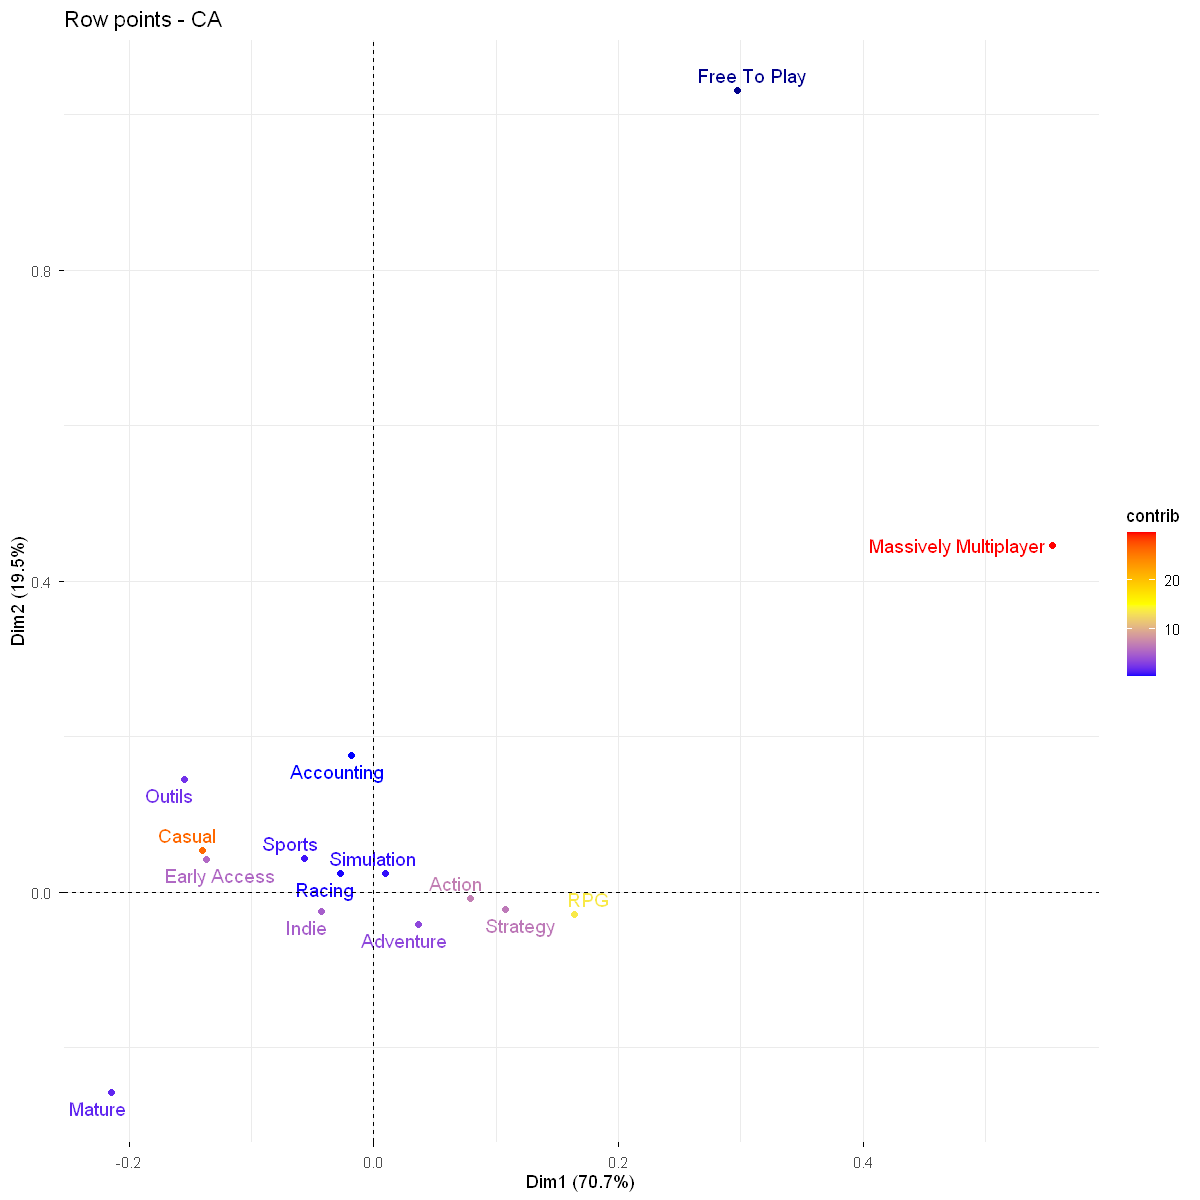

In [75]:
fviz_ca_row(res.ca_sans_ftp, col.row = "contrib",
             gradient.cols = c("blue", "yellow", "red"), 
             repel = TRUE)

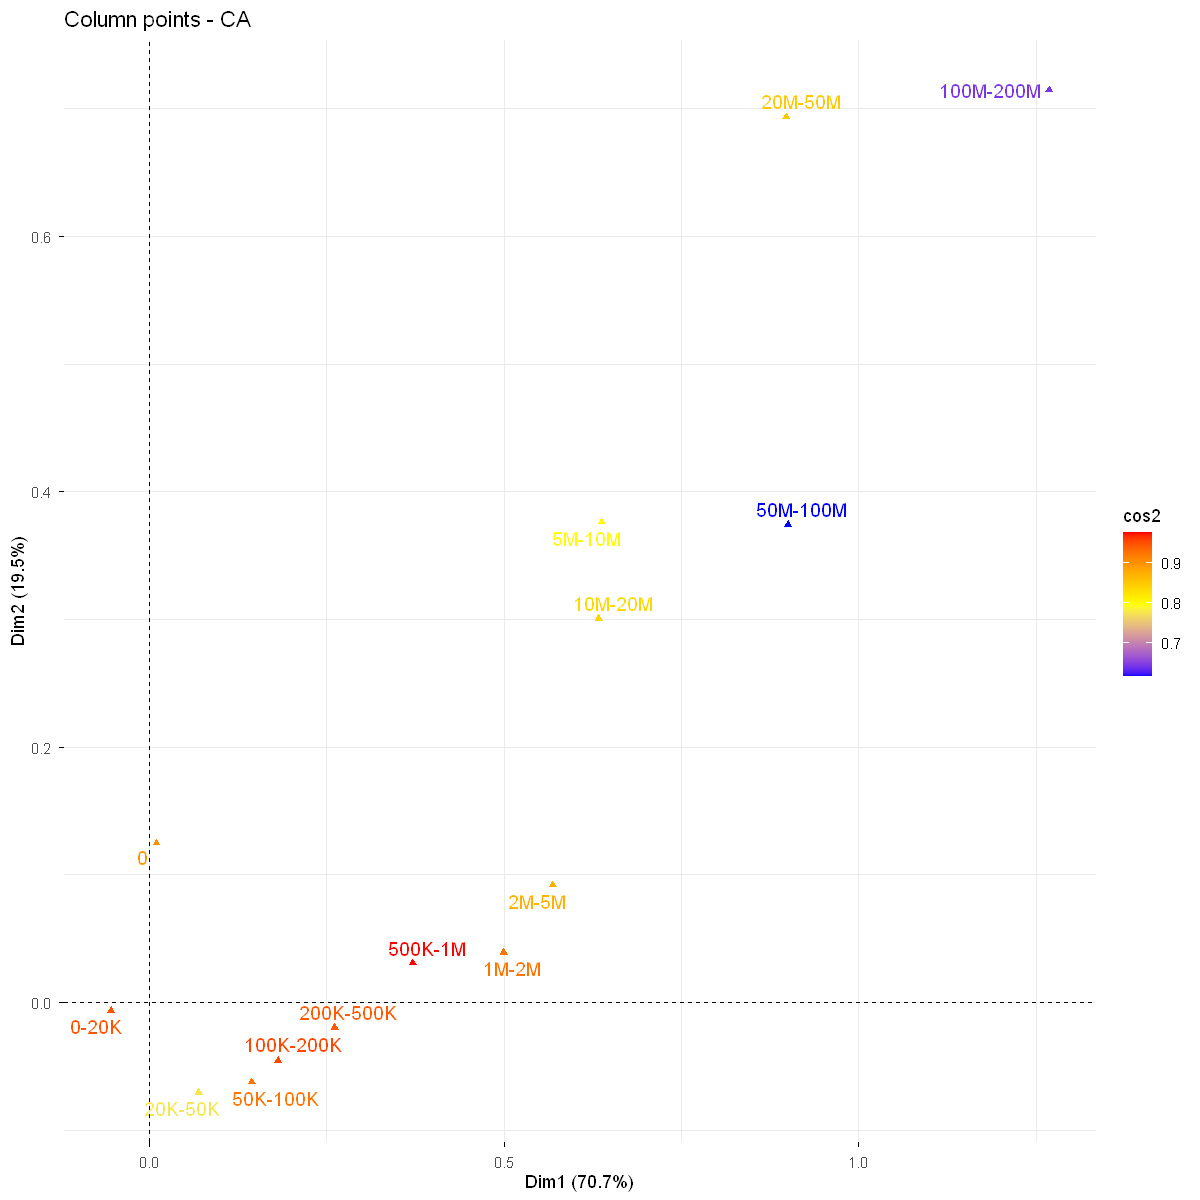

In [76]:
fviz_ca_col(res.ca_sans_ftp, col.col = "cos2",
             gradient.cols = c("blue", "yellow", "red"), 
             repel = TRUE)

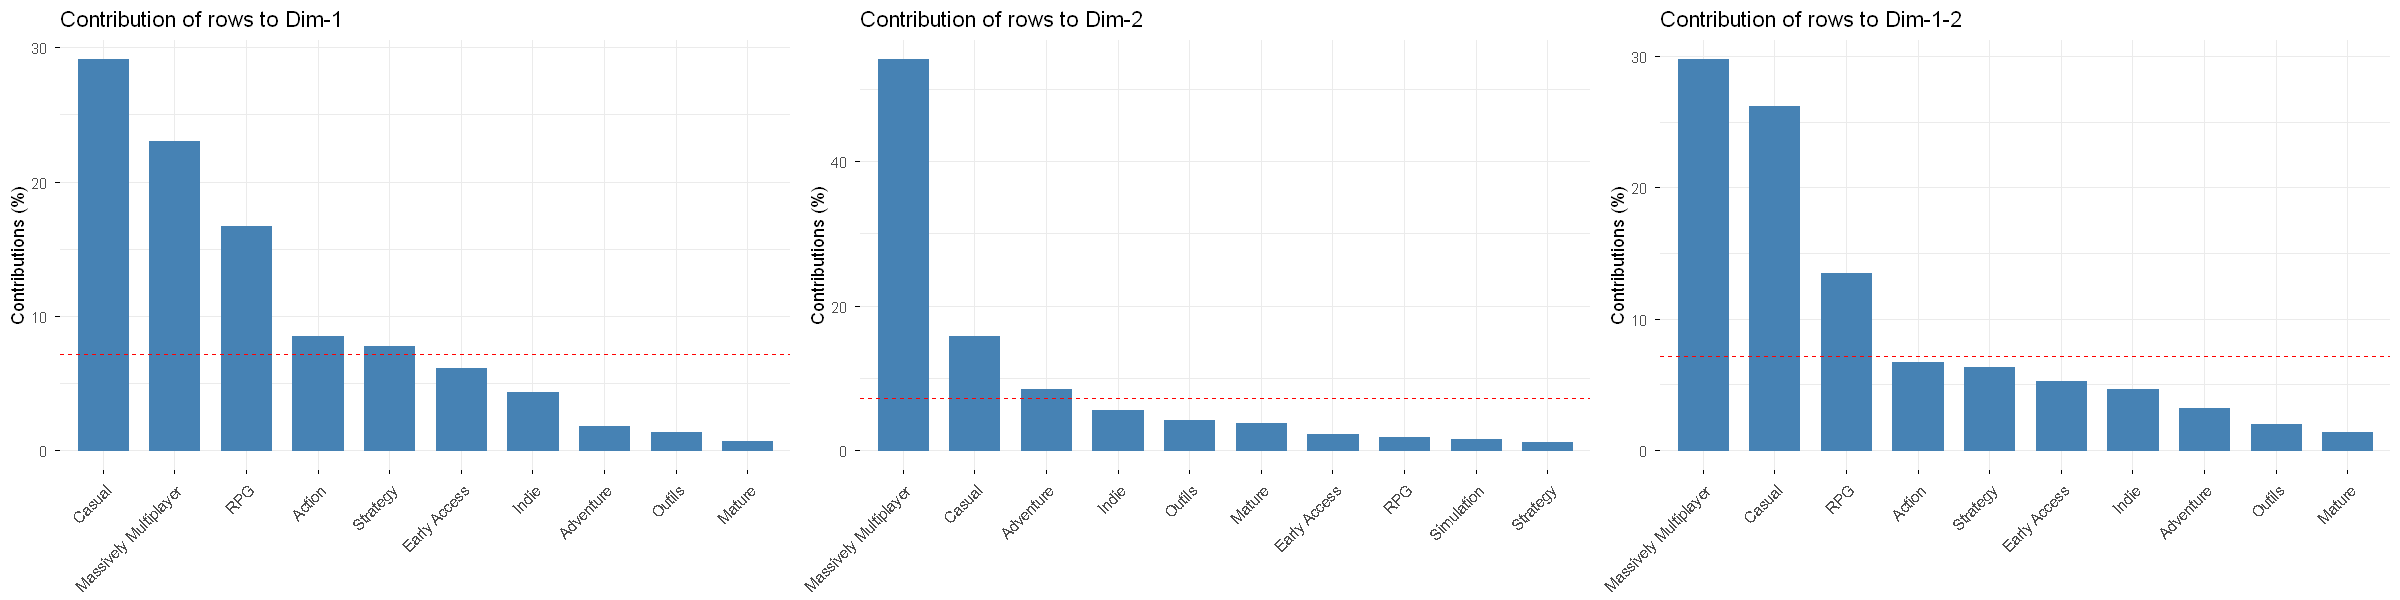

In [77]:
options(repr.plot.width = 20, repr.plot.height =5)
grid.arrange(fviz_contrib(res.ca_sans_ftp, choice = "row", axes = 1, top = 10),fviz_contrib(res.ca_sans_ftp, choice = "row", axes = 2, top = 10),fviz_contrib(res.ca_sans_ftp, choice = "row", axes = 1:2, top = 10),ncol=3)

Cette nouvelle Analyse des Correspondances (CA), bien que plus équilibrée, reste fortement marquée par le retrait du genre Free To Play en variable supplémentaire, lequel dominait initialement l'inertie de l'axe 1. Actuellement, le premier axe (Dim1, 70,7 % de la variance) oppose principalement les genres à fort engagement comme Massively Multiplayer et RPG, situés à droite, aux productions plus légères telles que Casual, Indie ou Outils à gauche. L'axe 2 (Dim2, 19,5 %) distingue quant à lui les titres communautaires massifs (en haut) des contenus de niche ou utilitaires (en bas).

Une lecture croisée des variables révèle des liens forts entre genres et tranches d'utilisateurs :

Succès Massif et Multijoueur : La proximité graphique entre les tranches 100M-200M et 20M-50M avec le genre Massively Multiplayer indique que ces très larges bases d'utilisateurs caractérisent prioritairement ce genre.

Succès Intermédiaire : Le genre RPG et, dans une moindre mesure, Action et Strategy, se projettent vers les tranches de succès significatif allant de 2M-5M à 10M-20M.

Catalogue Standard et Niche : À l'inverse, les genres Indie, Casual, Adventure et Outils sont massés à gauche du graphique, caractérisant les tranches d'utilisateurs les plus faibles (de 0-20K à 500K-1M).

En conclusion, si l'axe 1 structure désormais le marché selon un gradient de "densité de contenu et d'audience", il ne faut pas oublier que le genre Free To Play (en haut à droite du biplot) reste le facteur externe le plus puissant, tirant naturellement les jeux vers les tranches d'owners les plus extrêmes.

# Relation entre prix, popularité, genres et nombre de langues: MFA

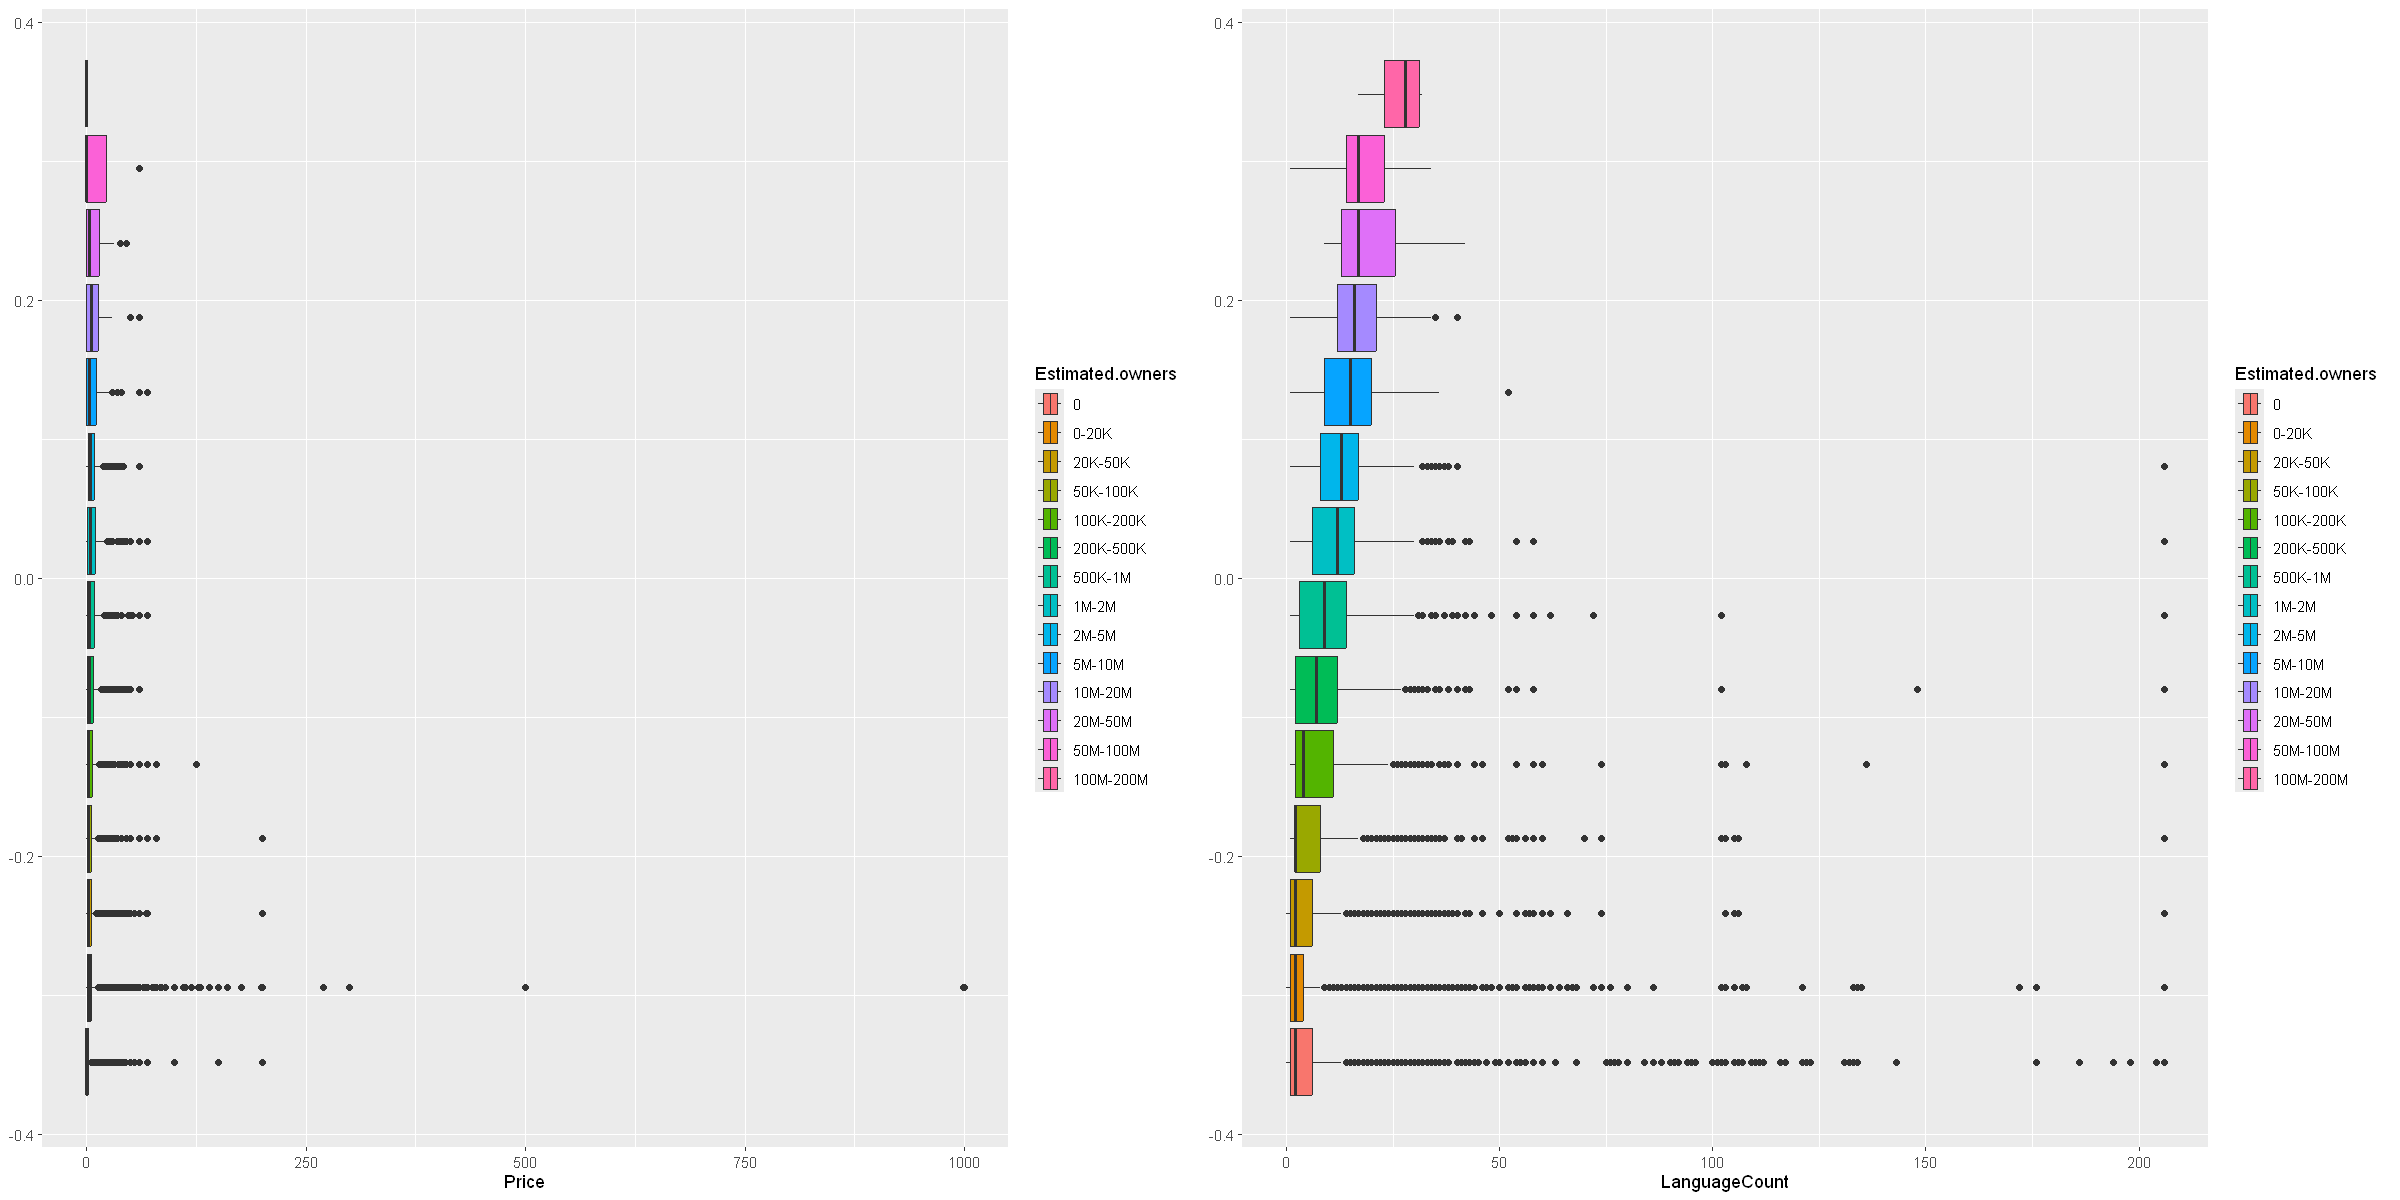

In [56]:
gg1=ggplot(data_ready, aes(x = Price, fill =Estimated.owners)) + geom_boxplot()
gg2=ggplot(data_ready, aes(x = LanguageCount, fill =Estimated.owners)) + geom_boxplot()
grid.arrange(gg1,gg2,ncol=2)

In [28]:
summary(data_ready)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

In [29]:
data_mfa <- data_ready %>%
  select(LPrice, LLanguageCount, Estimated.owners, Genres)

Transformation des données: encodage des variables qualitatives.

In [30]:
# On encode les genres en modalités avec 0 et 1
data_mfa <- dummy_cols(data_mfa, 
                            select_columns = "Genres", 
                            split = ",", 
                            remove_selected_columns = TRUE)

In [70]:
head(data_mfa)

,Price,LanguageCount,Estimated.owners,Genres_Accounting,Genres_Animation & Modeling,Genres_Audio Production,Genres_Design & Illustration,Genres_Education,Genres_Photo Editing,Genres_Software Training,⋯,Genres_Movie,Genres_Documentary,Genres_Episodic,Genres_Short,Genres_Tutorial,Genres_360 Video,Genres_Gore,Genres_Nudity,Genres_Violent,Genres_Sexual Content
,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,14.99,1,0-20K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,2.99,1,50K-100K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,19.99,6,0-20K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,1.79,13,100K-200K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,0.99,1,20K-50K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,1.99,2,0-20K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [63]:
inf_check <- sapply(data_mfa, function(x) if(is.numeric(x)) any(is.infinite(x)) else FALSE)
if(any(inf_check)) {
  print(paste("Colonnes avec des valeurs infinies :", names(inf_check)[inf_check]))
}

In [64]:
# 3. Vérification des colonnes constantes (Zéro variance)
const_check <- sapply(data_mfa, function(x) if(is.numeric(x)) var(x, na.rm=TRUE) == 0 else FALSE)
if(any(const_check)) {
  print(paste("Colonnes sans aucune variation :", names(const_check)[const_check]))
}

MFA: **J'ai une erreur quand je ne met pas les Genres en supplémentaires**

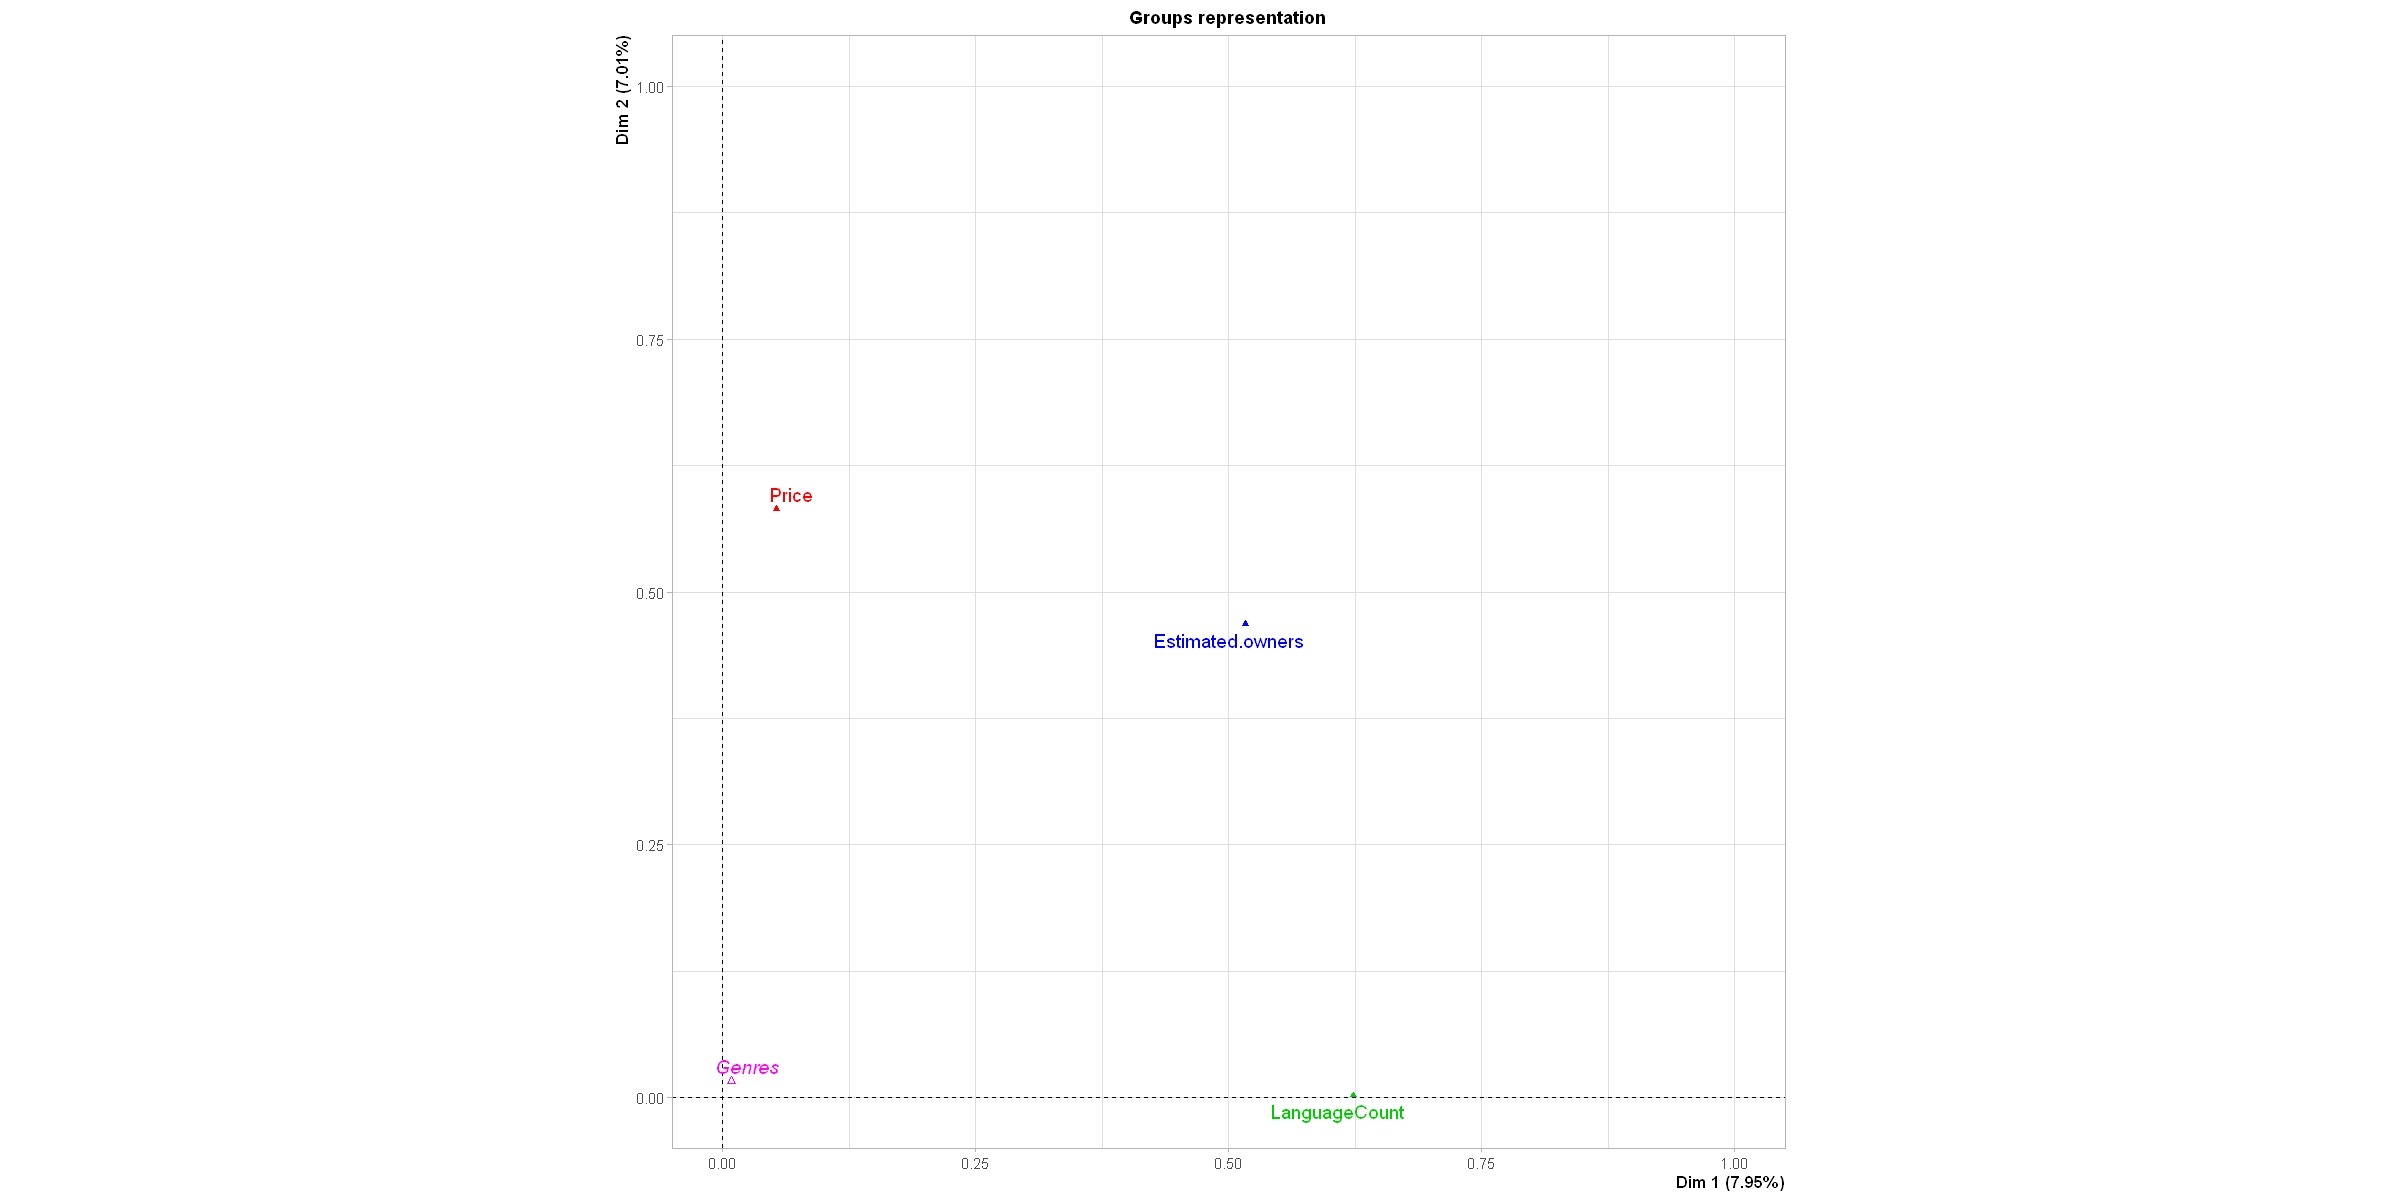

In [71]:
res.mfa <- MFA(data_mfa, 
               group = c(1, 1, 1, 33), 
               type = c("s", "s", "n", "f"), # 'n' pour la popularité, 'f' pour les dummies de genres, "s" pour centrer et reduire
               name.group = c("Price", "LanguageCount", "Estimated.owners", "Genres"),
               num.group.sup = 4,
               graph = FALSE)

# Analyse des résultats
plot(res.mfa, choix = "group") # Pour voir quel groupe influence le plus les axes

In [72]:
res.mfa$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,1.1919936,7.946624,7.946624
comp 2,1.0521531,7.014354,14.960978
comp 3,1.0000000,6.666667,21.627645
comp 4,1.0000000,6.666667,28.294311
comp 5,1.0000000,6.666667,34.960978
comp 6,1.0000000,6.666667,41.627645
comp 7,1.0000000,6.666667,48.294311
comp 8,1.0000000,6.666667,54.960978
comp 9,1.0000000,6.666667,61.627645
comp 10,1.0000000,6.666667,68.294311


Qualité de représentation des groupes:

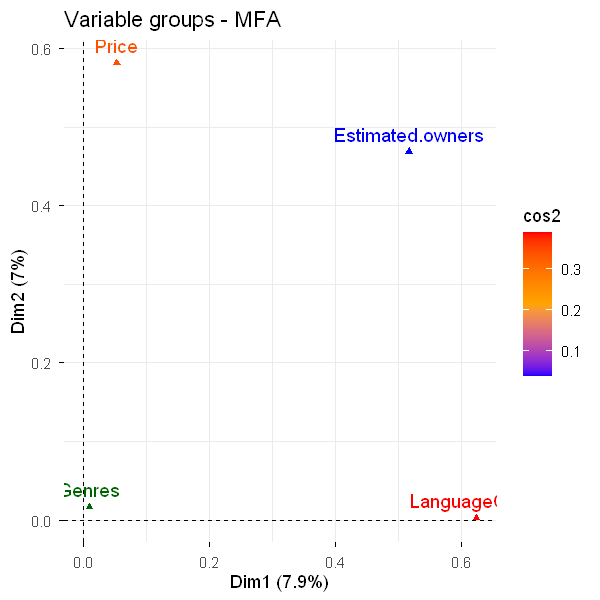

In [100]:
options(repr.plot.width = 5, repr.plot.height =5)
fviz_mfa_var(res.mfa, "group", col.var = "cos2", gradient.cols = c("blue", "orange", "red"))

Contribution aux axes des groupes: 

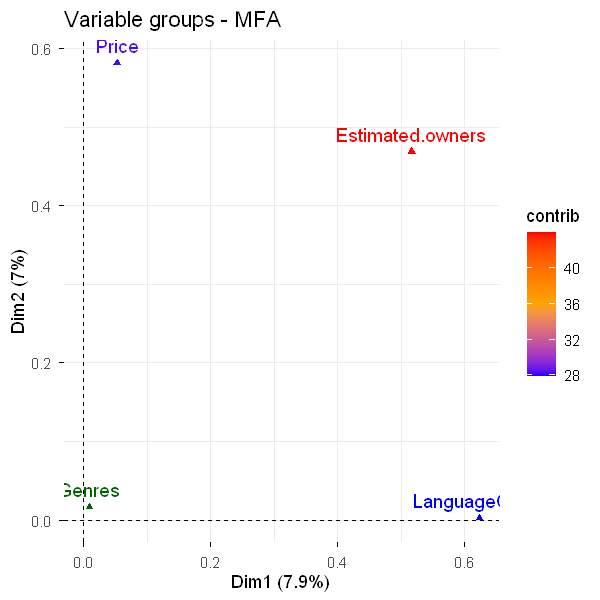

In [97]:
fviz_mfa_var(res.mfa, "group", col.var = "contrib", gradient.cols = c("blue", "orange", "red"))

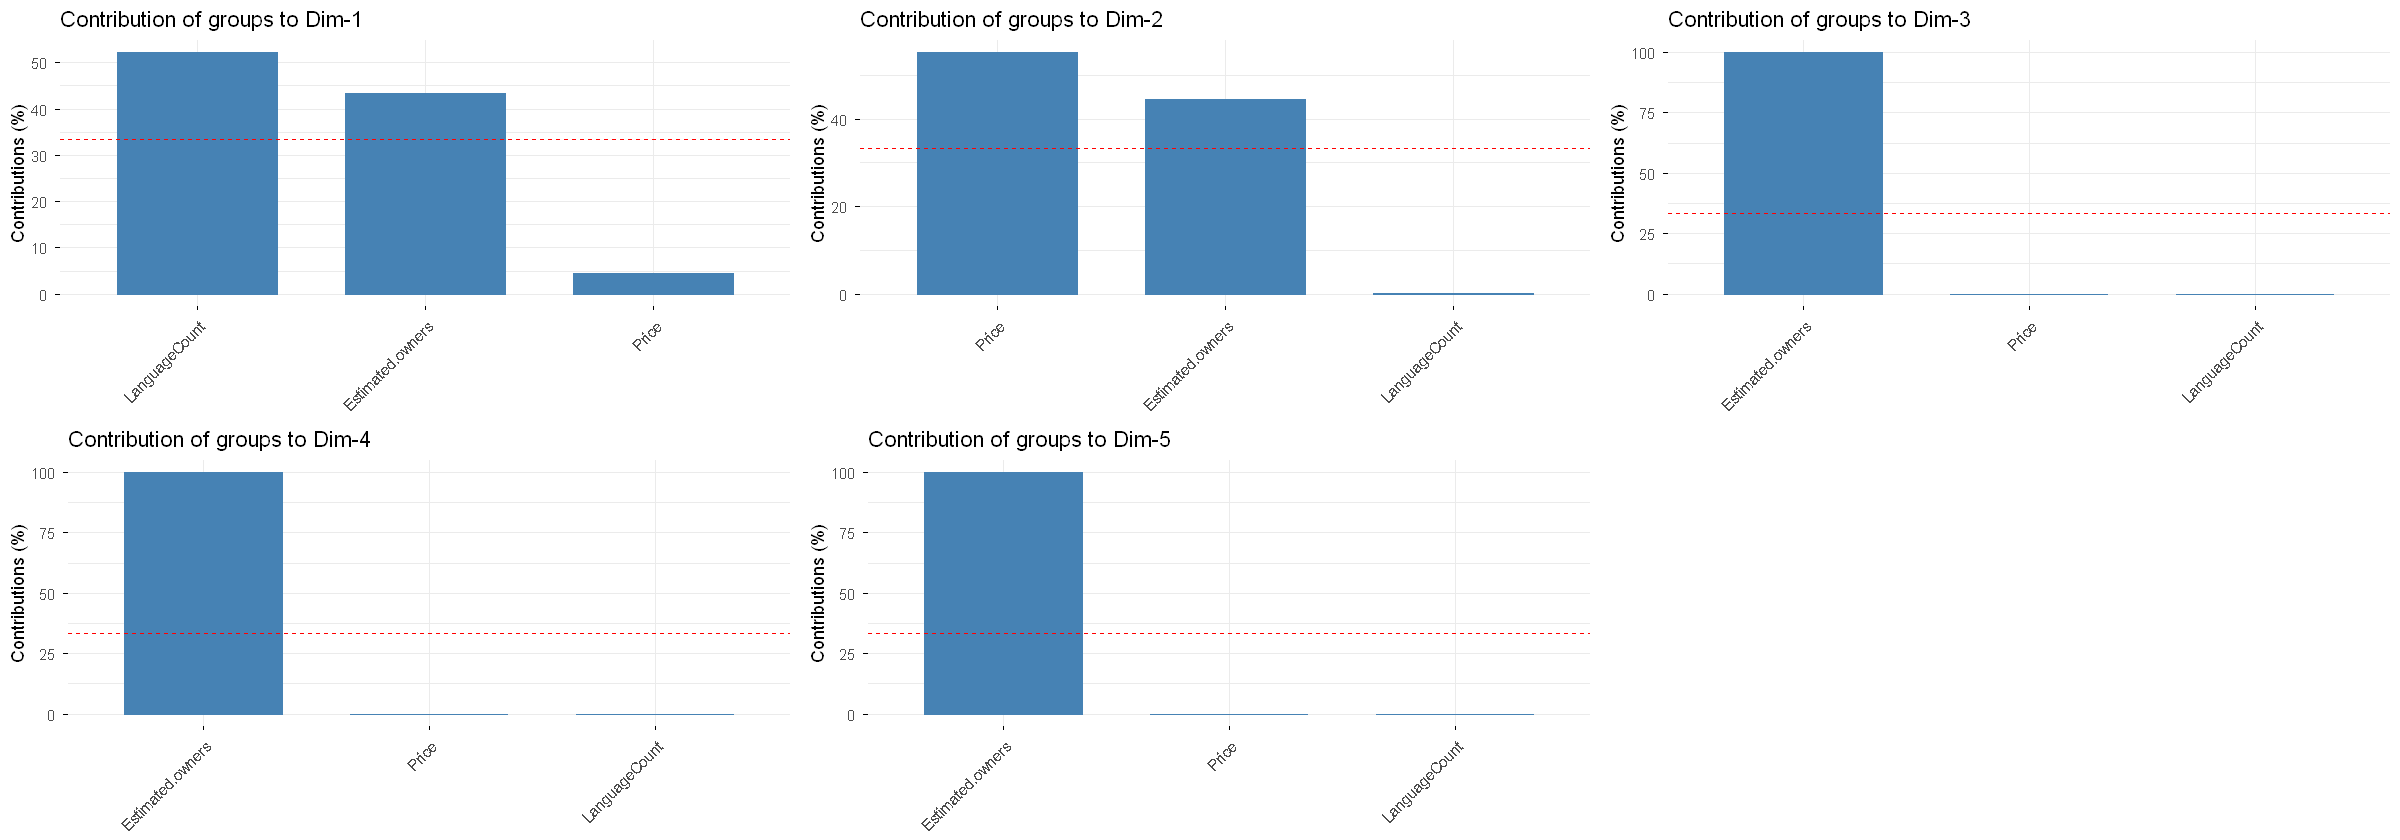

In [92]:
options(repr.plot.width = 20, repr.plot.height = 7)
p1 <- fviz_contrib(res.mfa, choice = "group", axes = 1)
p2 <- fviz_contrib(res.mfa, choice = "group", axes = 2)
p3 <- fviz_contrib(res.mfa, choice = "group", axes = 3)
p4 <- fviz_contrib(res.mfa, choice = "group", axes = 4)
p5 <- fviz_contrib(res.mfa, choice = "group", axes = 5)
grid.arrange(p1, p2, p3,p4,p5,ncol = 3)

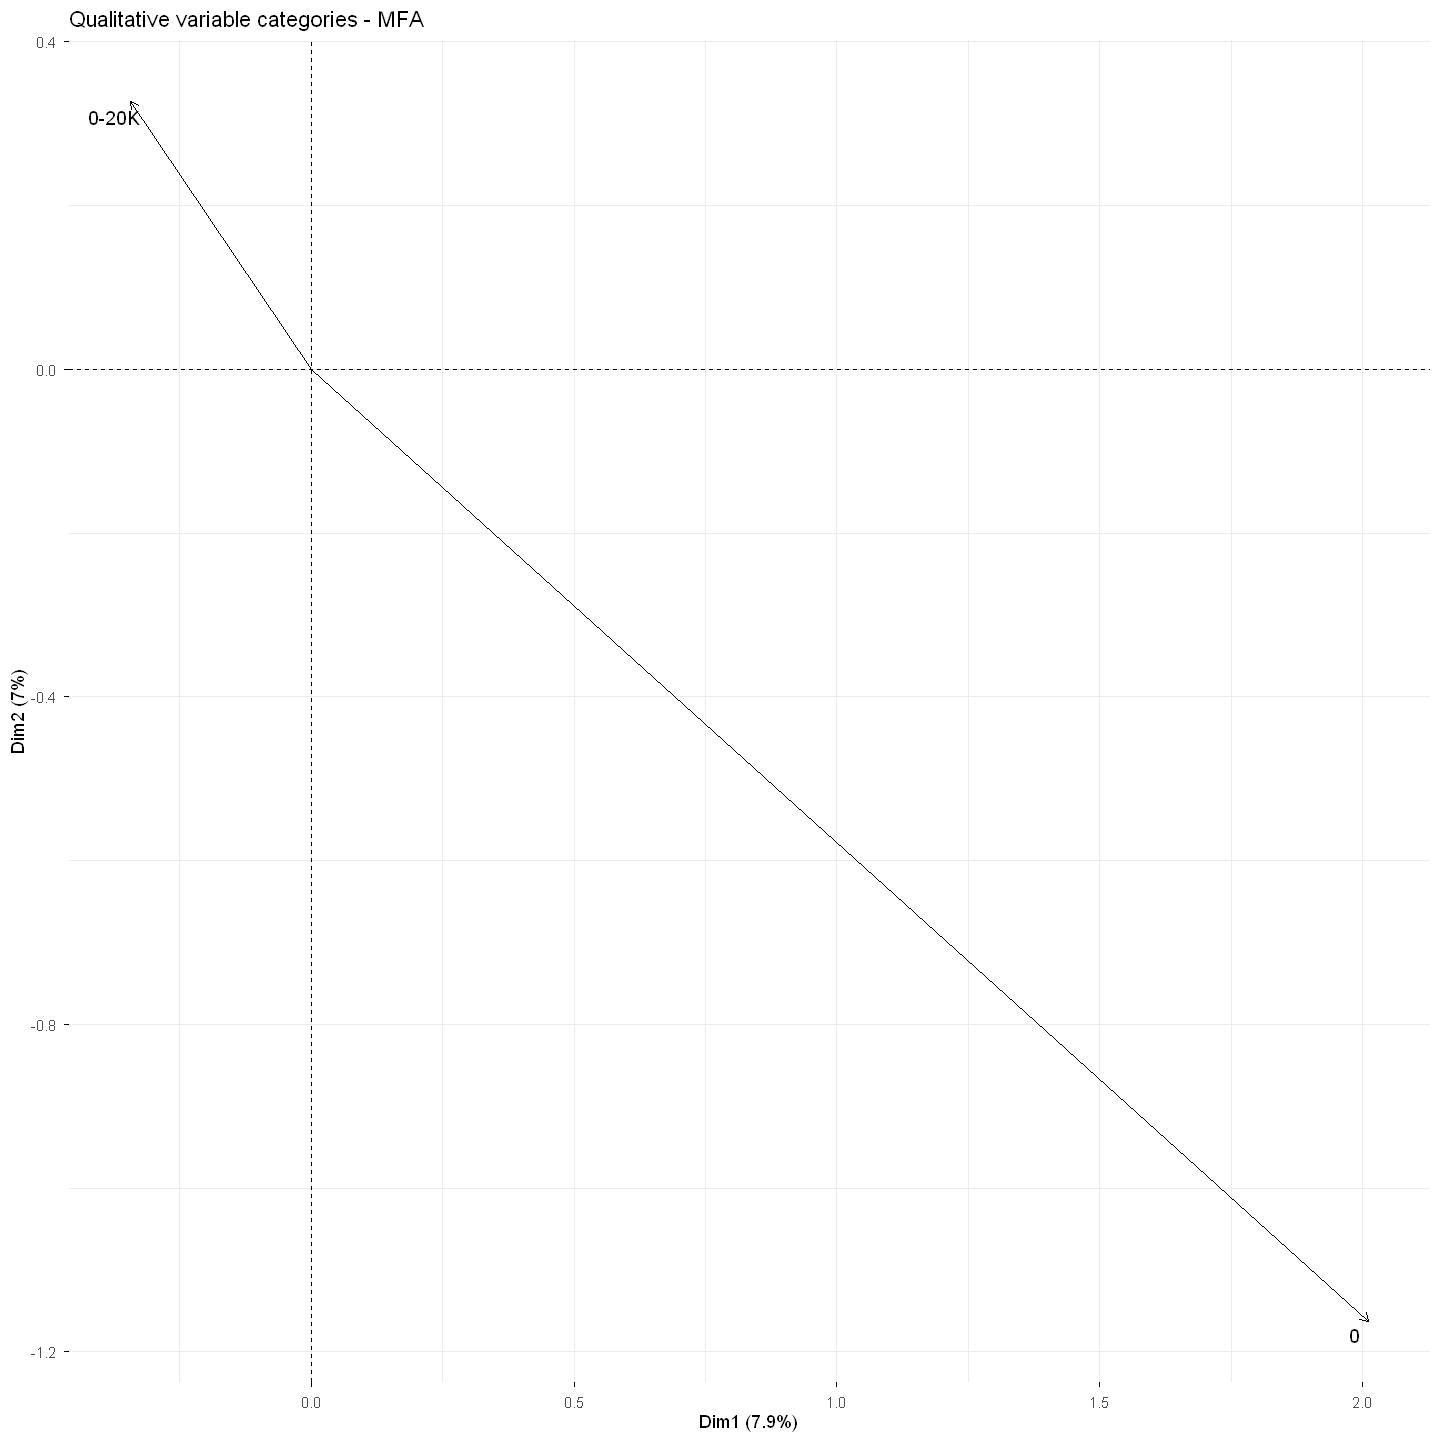

In [105]:
fviz_mfa_var(res.mfa, "quali.var", 
             geom = c("arrow", "text"),
             # On ne met pas de couleur par groupe pour tester si c'est ça qui bloque
             col.var = "black", 
             select.var = list(cos2 = 0.2),
             repel = TRUE)

Warning message:
"This manual palette can handle a maximum of 10 values. You have supplied 14"
Warning message:
"Removed 94 rows containing missing values or values outside the scale range (`geom_point()`)."
Warning message:
"Removed 4 rows containing missing values or values outside the scale range (`geom_point()`)."


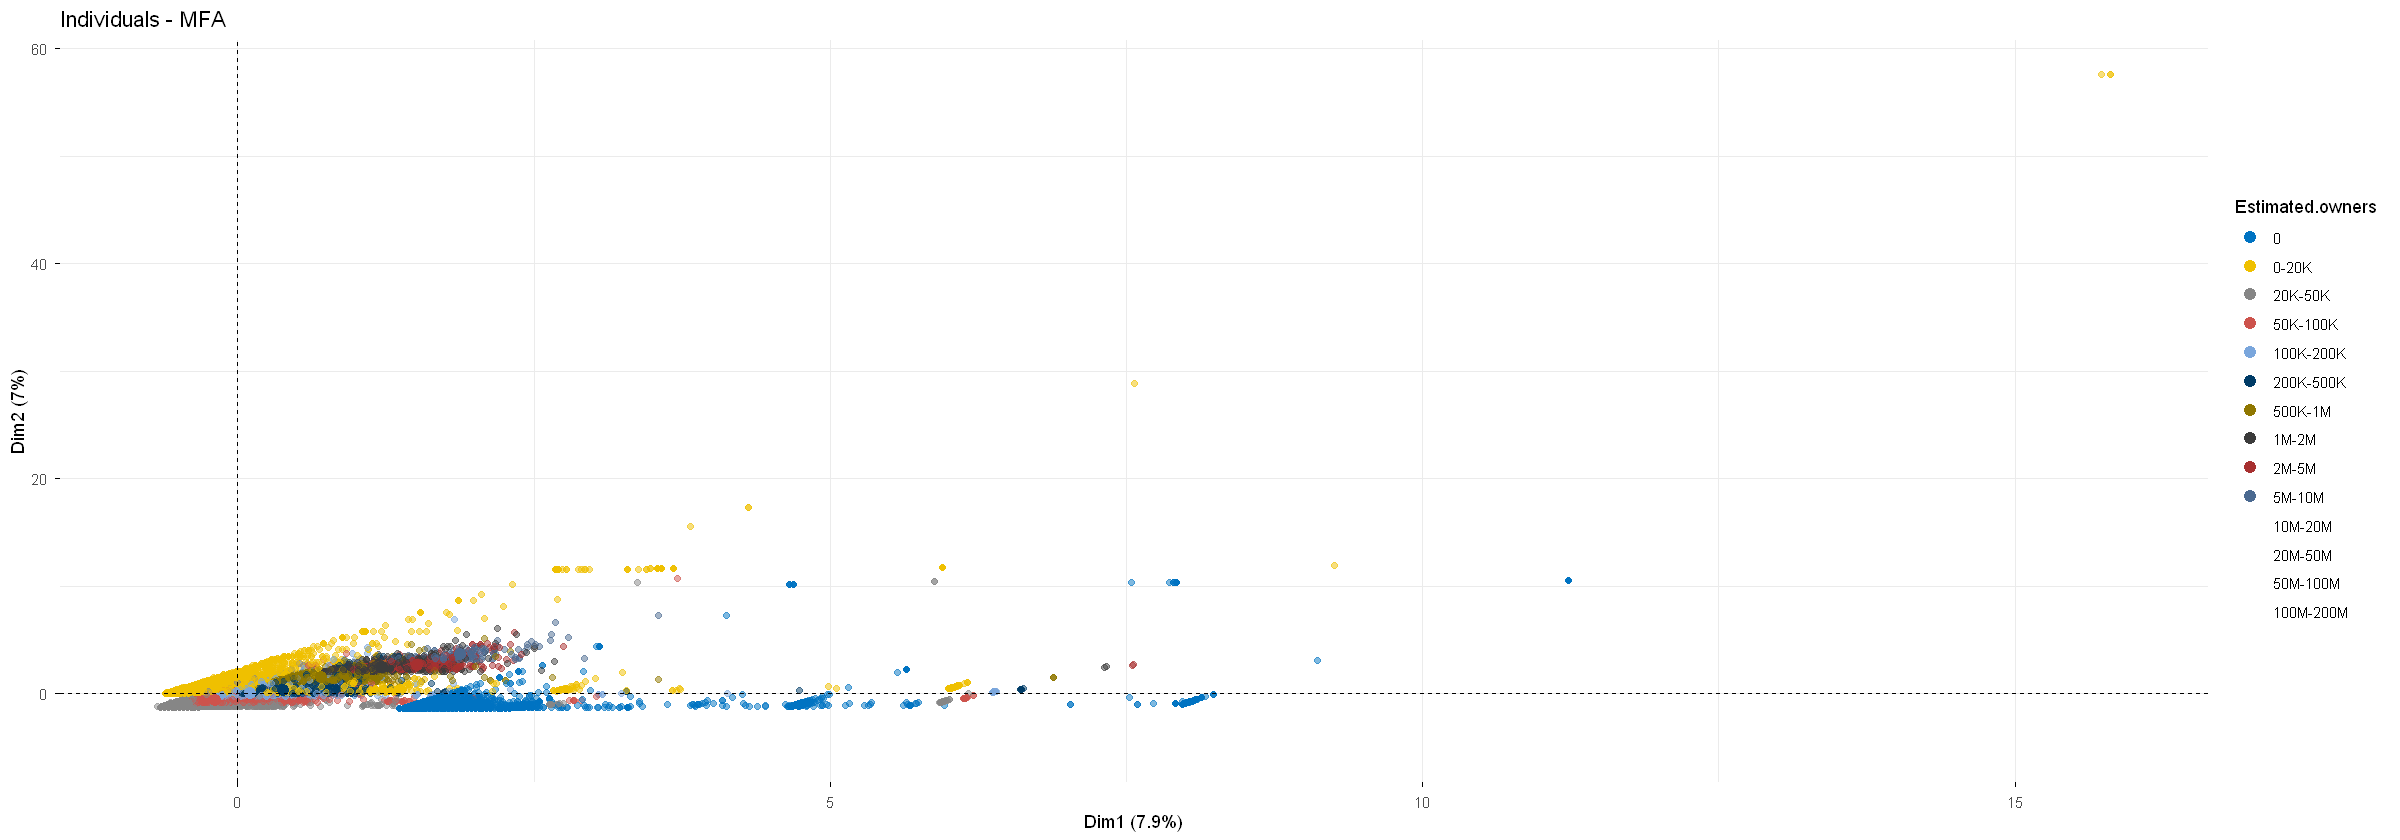

In [94]:
# Affichage simple des individus colorés par le groupe 'Succès' (Estimated.owners)
fviz_mfa_ind(res.mfa, 
             habillage = "Estimated.owners", # Nom de la variable pour colorer
             label = "none",                 # On cache les noms des 122k jeux pour y voir clair
             alpha.ind = 0.5,                # Transparence pour voir la densité
             palette = "jco")

Pour clustering peut-être que de considérere tout les individus c'est trop => on peut simplement garder les individus qui ont plus de 50K d'utilisateurs, et on s'attend a avoir des clusters de jeux qui ont moyennement marché, bien marché et puis le top des jeux

# Parmi les jeux rencontrant un succès commercial, est-il possible d'établir différentes typologies de réussite ?

Dans cette partie, nous allons restreindre notre échantillon aux jeux ayant plus de 50 000 propriétaires estimés, seuil que nous retenons ici comme indicateur de succès. Afin de répondre à cette problématique, nous procéderons en deux étapes : d'abord, nous regrouperons les jeux en clusters à partir des variables quantitatives après avoir effectué une ACP (Analyse par Composantes Principales). Ensuite, nous caractériserons ces groupes en utilisant l'ensemble des variables afin de mettre en lumière les spécificités de chaque profil de succès identifié.

In [32]:
#Création du jeux de données populaire
data.pop <- data_ready %>% filter(!(Estimated.owners %in% c("0", "0-20K","20K-50K")))

In [33]:
dim(data.pop)

[1] 14132    28

Ce sous-ensemble de données contient donc 14 132 jeux.

**Sélection des variables quantitatives**

In [34]:
data.pop.quanti = data.pop %>% select(where(is.numeric))

In [35]:
summary(data.pop.quanti)

    Discount      Metacritic.score   User.score        Achievements    
 Min.   :  0.00   Min.   : 0.00    Min.   : 0.00000   Min.   :   0.00  
 1st Qu.:  0.00   1st Qu.: 0.00    1st Qu.: 0.00000   1st Qu.:   0.00  
 Median : 33.50   Median : 0.00    Median : 0.00000   Median :  18.00  
 Mean   : 35.48   Mean   :16.36    Mean   : 0.01521   Mean   :  39.92  
 3rd Qu.: 70.00   3rd Qu.: 0.00    3rd Qu.: 0.00000   3rd Qu.:  39.00  
 Max.   :100.00   Max.   :97.00    Max.   :77.00000   Max.   :9821.00  
 Average.playtime.two.weeks Median.playtime.two.weeks   LPositive     
 Min.   :    0.00           Min.   :    0             Min.   : 0.000  
 1st Qu.:    0.00           1st Qu.:    0             1st Qu.: 5.081  
 Median :    0.00           Median :    0             Median : 6.562  
 Mean   :   96.48           Mean   :  104             Mean   : 6.388  
 3rd Qu.:    0.00           3rd Qu.:    0             3rd Qu.: 7.901  
 Max.   :20088.00           Max.   :20088             Max.   :15.849  

## Analyse par Composantes Principales

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,5.49662603,36.6441735,36.64417
comp 2,1.94036576,12.9357717,49.57995
comp 3,1.04676904,6.9784602,56.55841
comp 4,1.01495978,6.7663985,63.32480
comp 5,0.99479780,6.6319853,69.95679
comp 6,0.96289639,6.4193093,76.37610
comp 7,0.89811559,5.9874373,82.36354
comp 8,0.76048622,5.0699081,87.43344
comp 9,0.72189584,4.8126389,92.24608
comp 10,0.53214547,3.5476365,95.79372


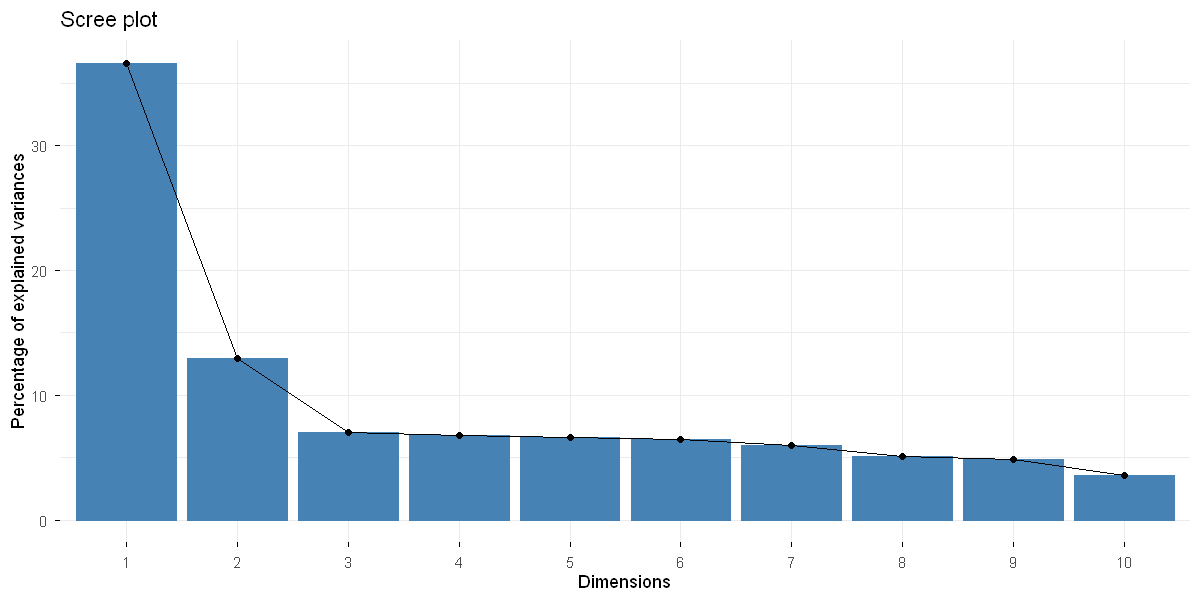

In [176]:
options(repr.plot.width = 10, repr.plot.height = 5)
pca.pop <- PCA(data.pop.quanti, scale.unit = TRUE, graph = FALSE)
fviz_eig(pca.pop)
pca.pop$eig

On observe que la première composante principale explique à elle seule 36 % de la variance, ce qui témoigne d'une forte corrélation entre les variables quantitatives. Pour la suite de l'étude, nous avons choisi de retenir les **7 premières dimensions** ce qui permet d'atteindre un seuil de **80 %** de variance expliquée.

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>."
Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."


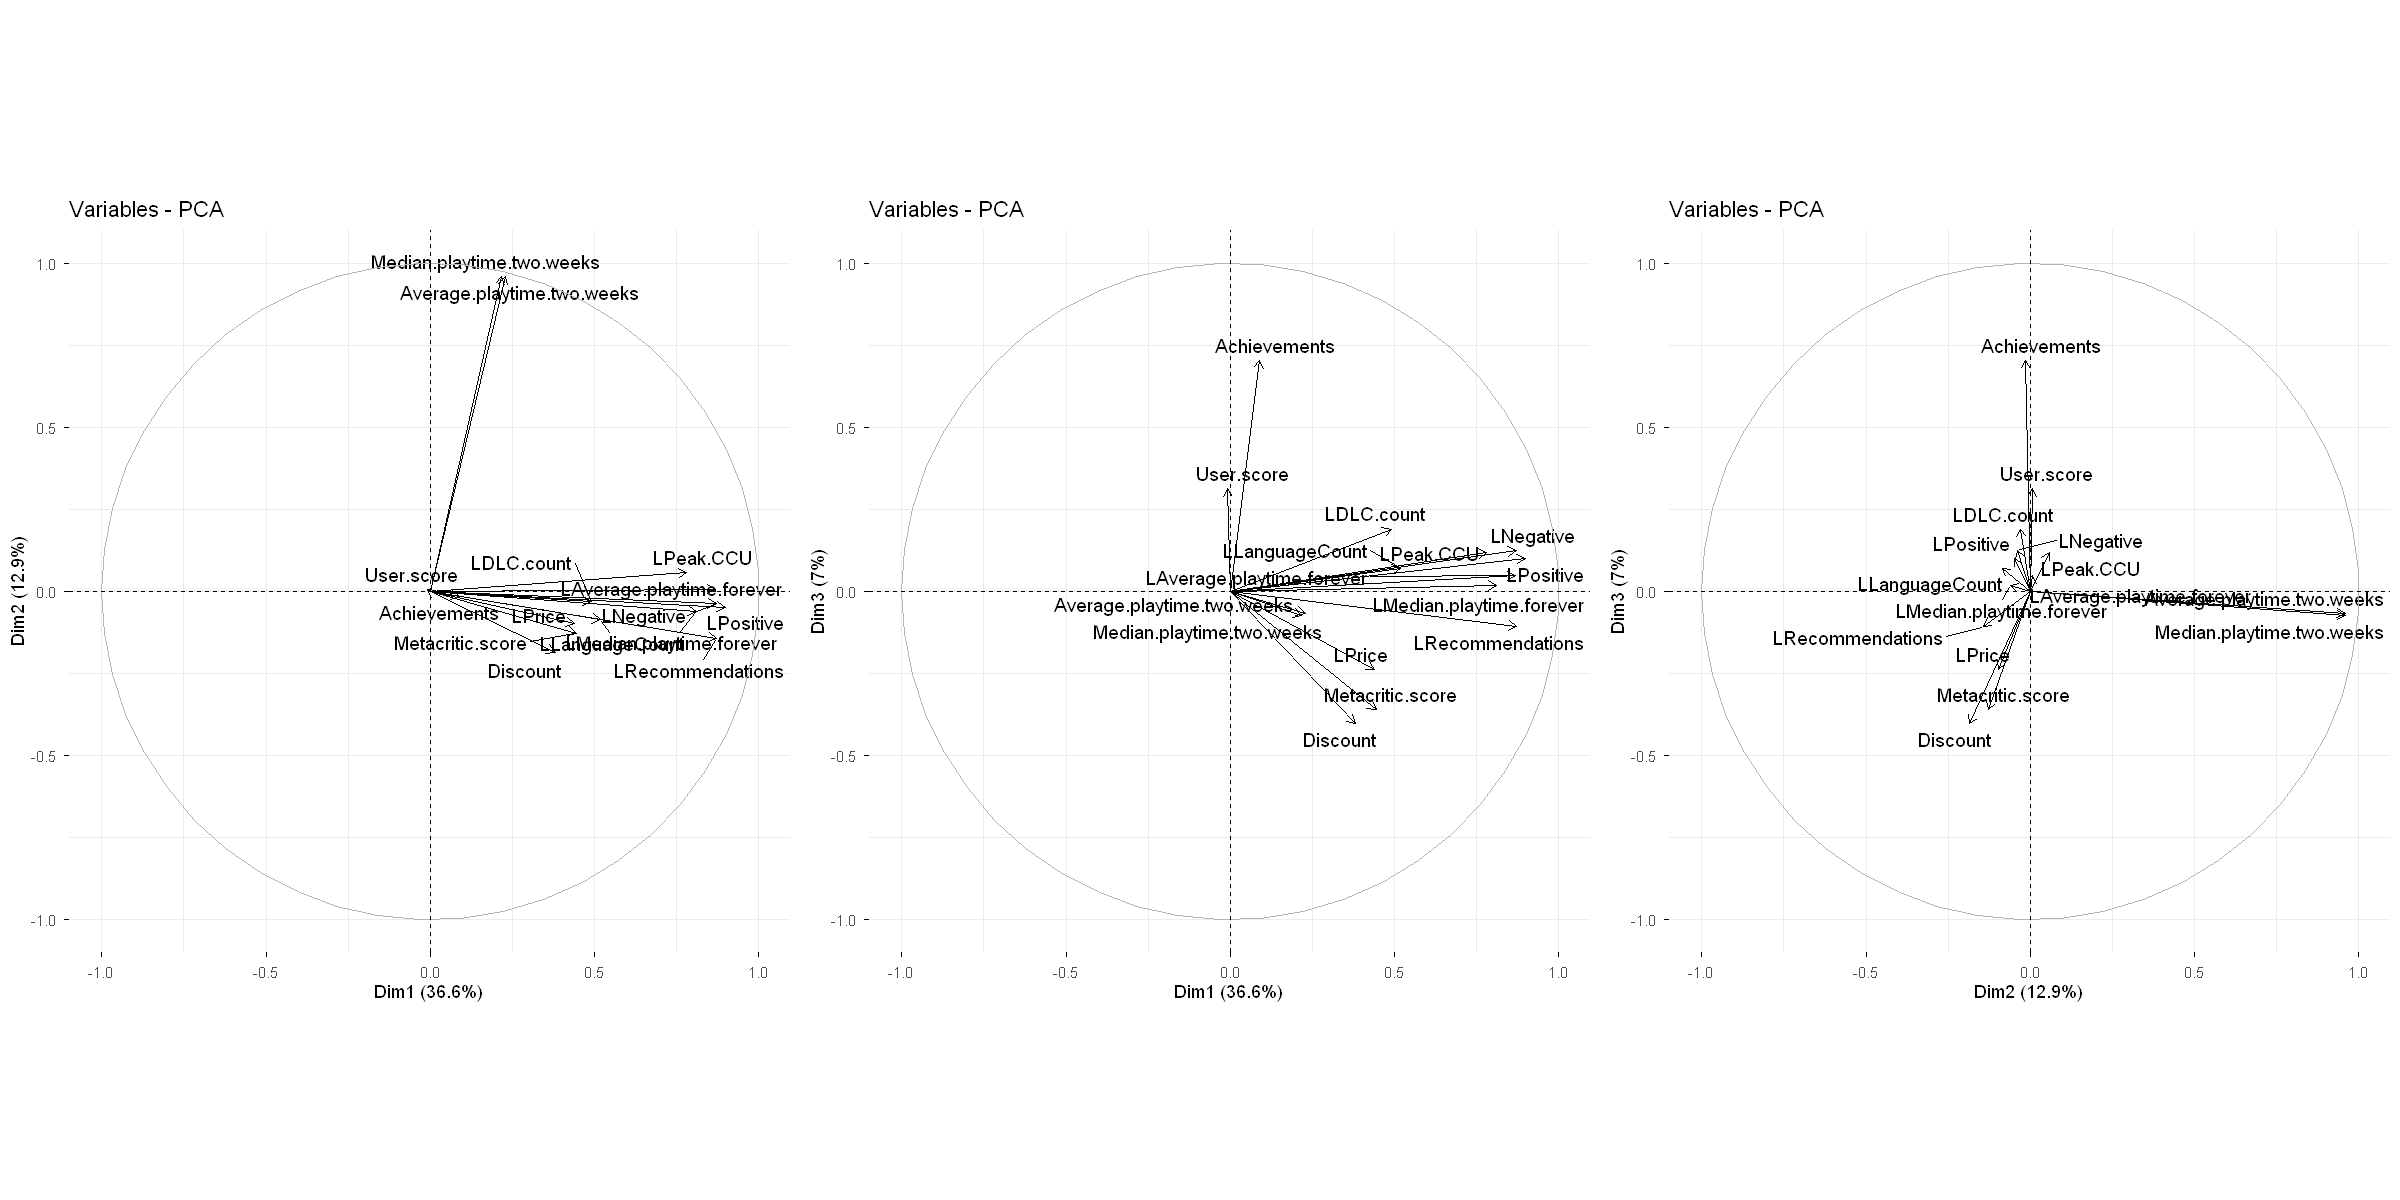

In [37]:
options(repr.plot.width = 20, repr.plot.height = 10)
g1=fviz_pca_var(pca.pop,axes = c(1,2),repel=TRUE)
g2=fviz_pca_var(pca.pop,axes = c(1,3),repel=TRUE)
g8=fviz_pca_var(pca.pop,axes = c(2,3),repel=TRUE)
grid.arrange(g1,g2,g8,ncol=3)

### K-means

In [38]:
data.pop.scale <- scale(data.pop.quanti) #Pour que chaque variable ait le même poids car elles ont des valeurs très differentes
# sans normalisation on obtient des clusters très désiquilibrés en termes d'effectif

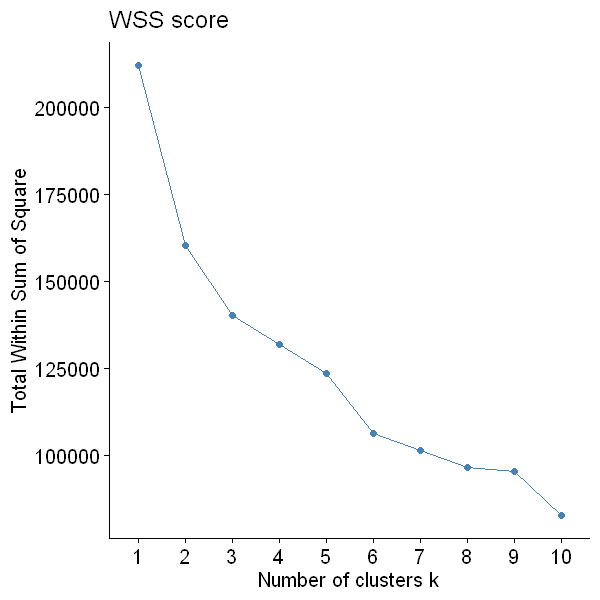

In [60]:
options(repr.plot.width = 5, repr.plot.height =5)
p1 = fviz_nbclust(data.pop.scale, FUNcluster=stats::kmeans, method="wss",k.max = 10) + ggtitle("WSS score")
p1

In [ ]:
Deux nombres de clusters plausibles avec la méthode du coude: 3 et 6. On va vérifier avec le score silhouette.

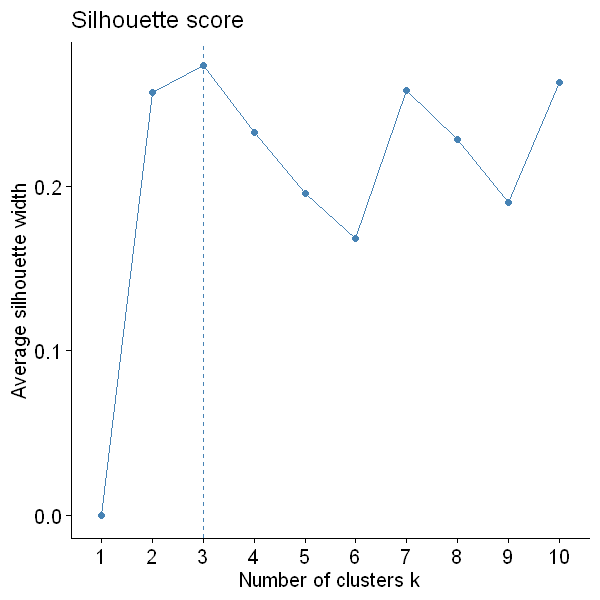

In [156]:
fviz_nbclust(data.pop.scale, FUNcluster=stats::kmeans, method="silhouette") + ggtitle("Silhouette score")

D'après ce critère on choisit donc K=3, cela signifie que les clusters sont mieux séparés.

On essaye maintenant de voir si ce nombre change quand on prend les composantes de l'ACP.

Warning message:
"Les étapes de transfer (quick-TRANSfer stage) ont dépassé le maximum (= 706600)"


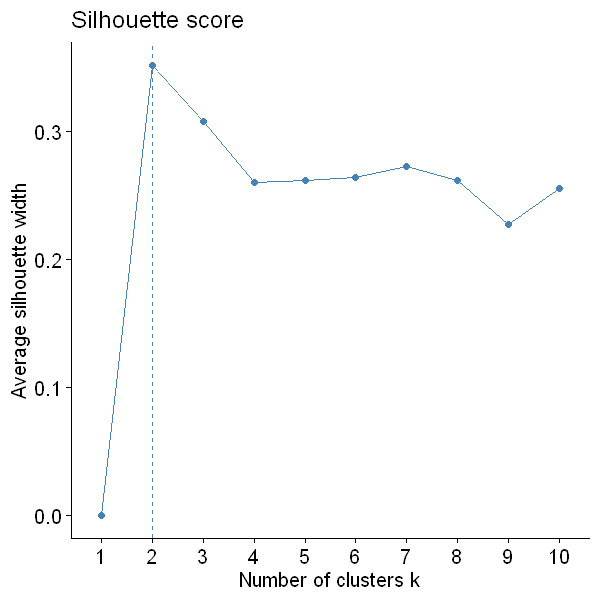

In [41]:
options(repr.plot.width = 5, repr.plot.height =5)
fviz_nbclust(pca.pop$ind$coord[,1:7], FUNcluster=stats::kmeans, method="silhouette",iter.max = 100) + ggtitle("Silhouette score")

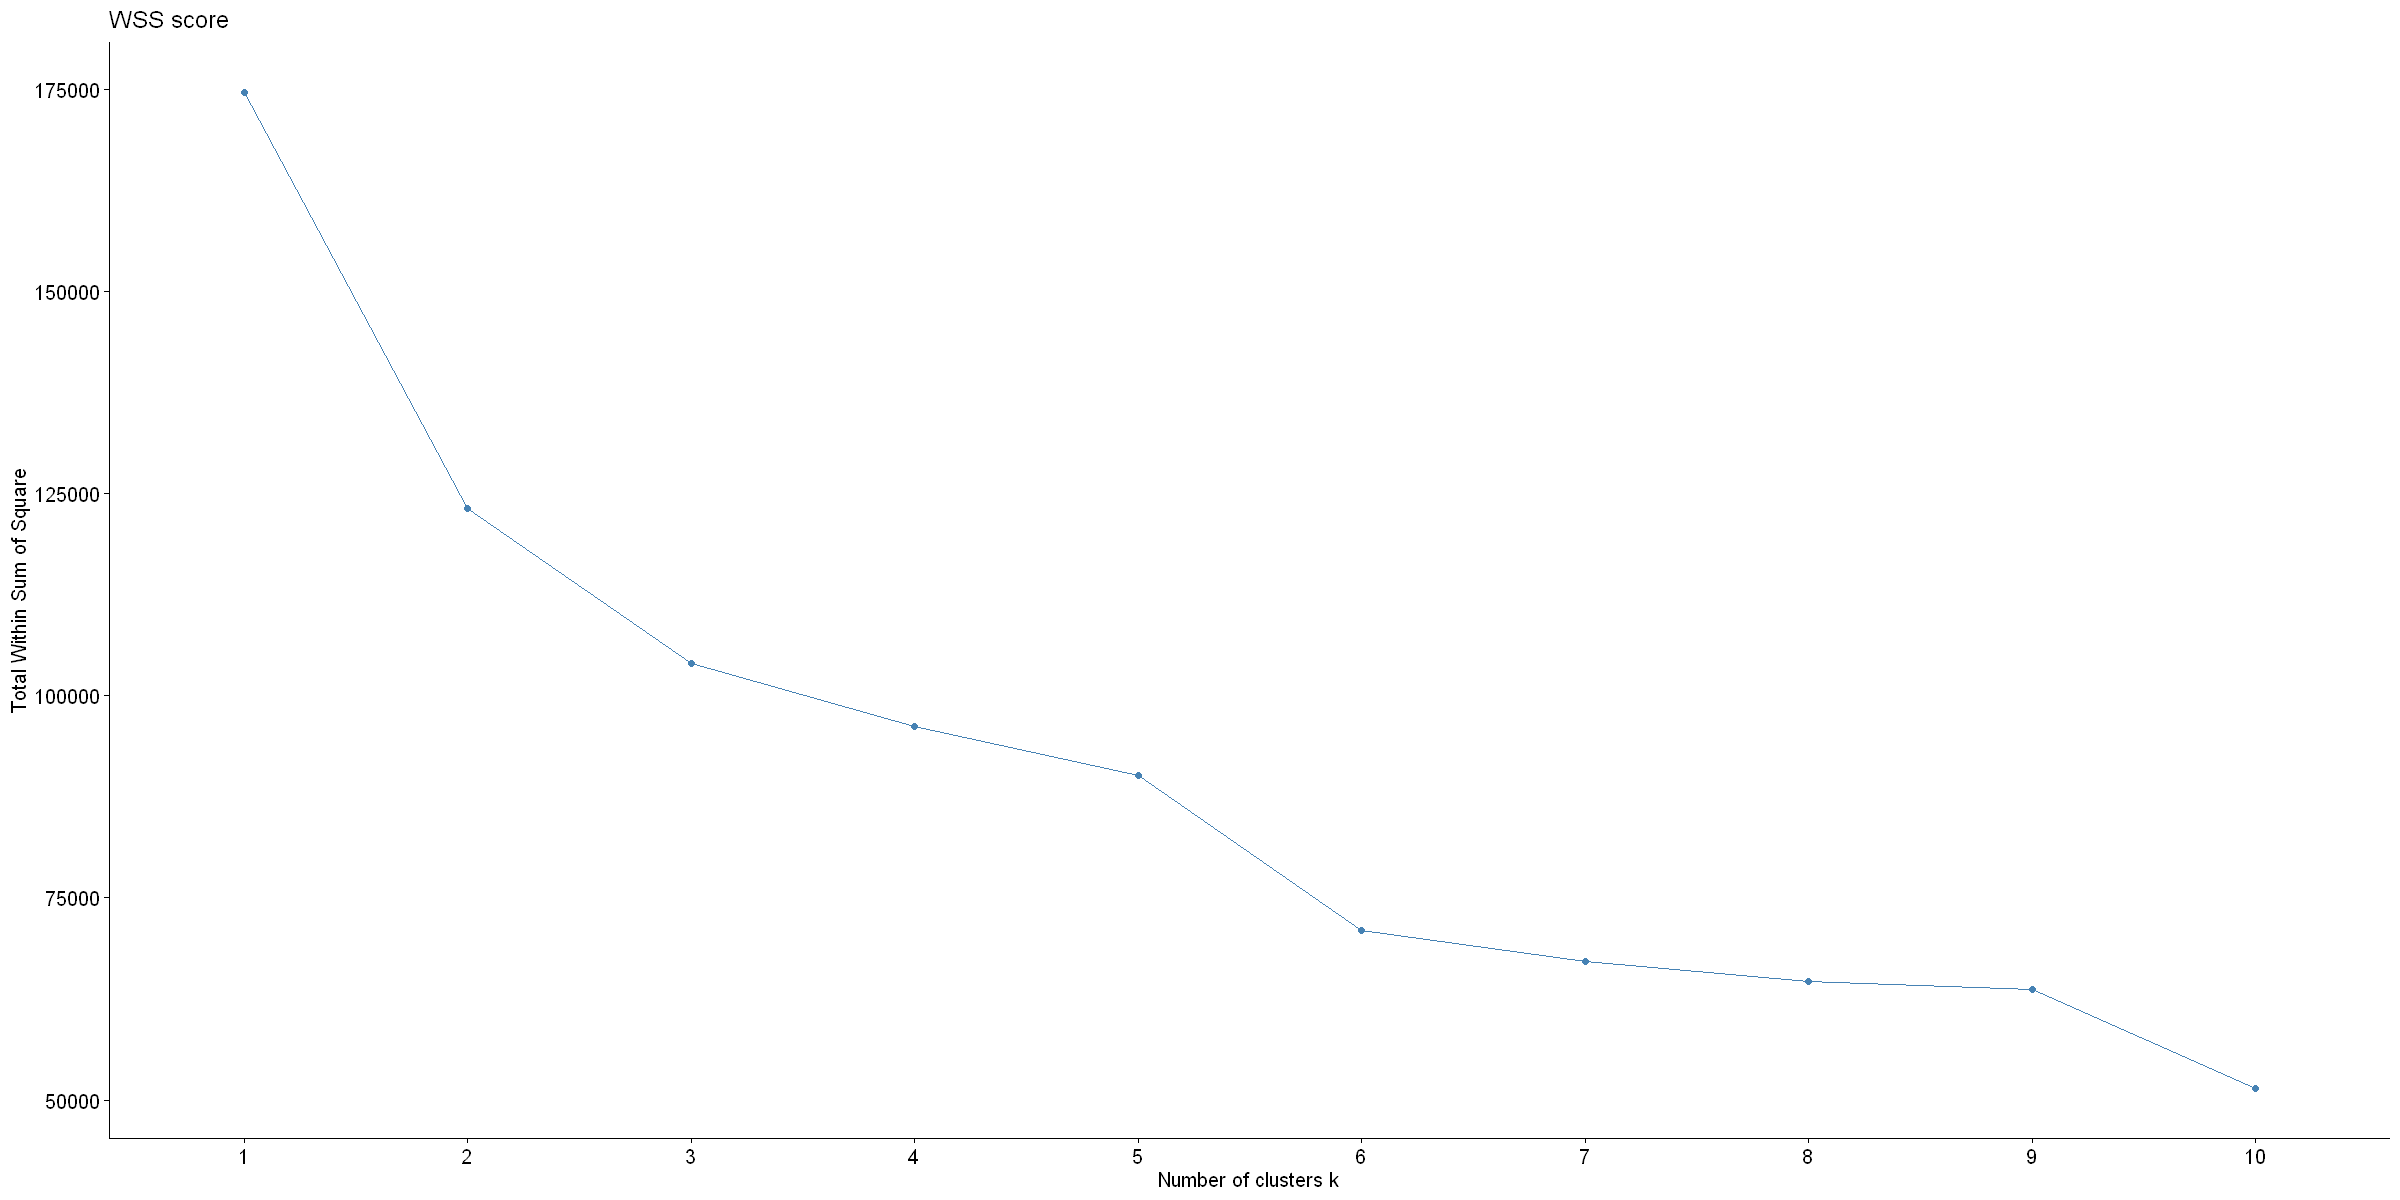

In [40]:
fviz_nbclust(pca.pop$ind$coord[,1:7], FUNcluster=stats::kmeans, method="wss",k.max = 10) + ggtitle("WSS score")

### K-means sur les données de base (nb cluster = 3)

In [162]:
kmeans3 = kmeans(data.pop.scale, centers=3)
cluster_counts_3 = data.frame(table(kmeans3$cluster))
cluster_counts_3

Var1,Freq
<fct>,<int>
1,7210
2,3039
3,3883


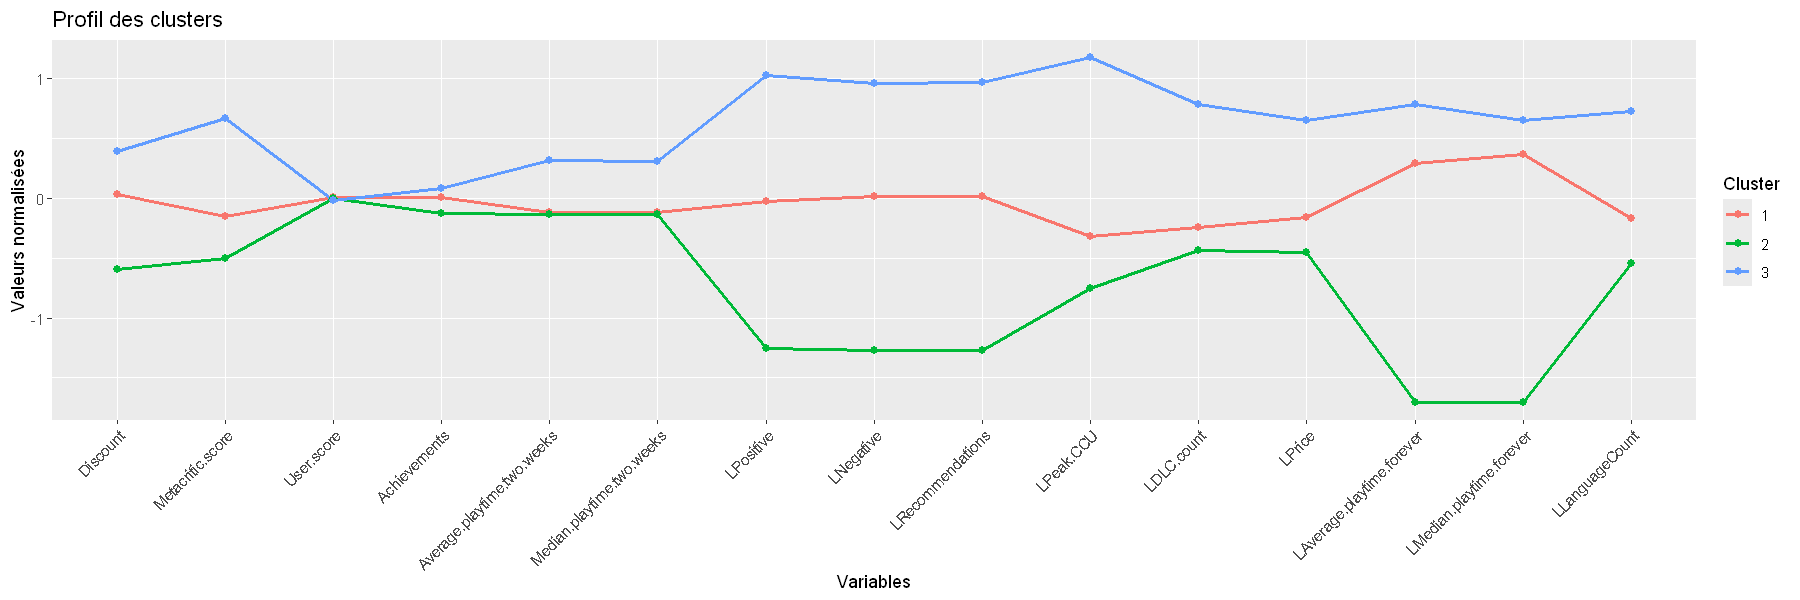

In [163]:
# mean profiles pour K=3
options(repr.plot.width = 15, repr.plot.height =5)
mean_profile = aggregate(data.pop.scale, by = list(cluster = kmeans3$cluster), FUN = mean)
plot_data <- melt(mean_profile, id.vars = "cluster")

ggplot(plot_data, aes(x = variable, y = value, color = factor(cluster), group = cluster)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Profil des clusters",
       x = "Variables",
       y = "Valeurs normalisées",
       color = "Cluster")

Affichage sur l'espace des individus de la PCA

Ignoring unknown labels:
• linetype : "Clusters"
Ignoring unknown labels:
• linetype : "Clusters"
Ignoring unknown labels:
• linetype : "Clusters"


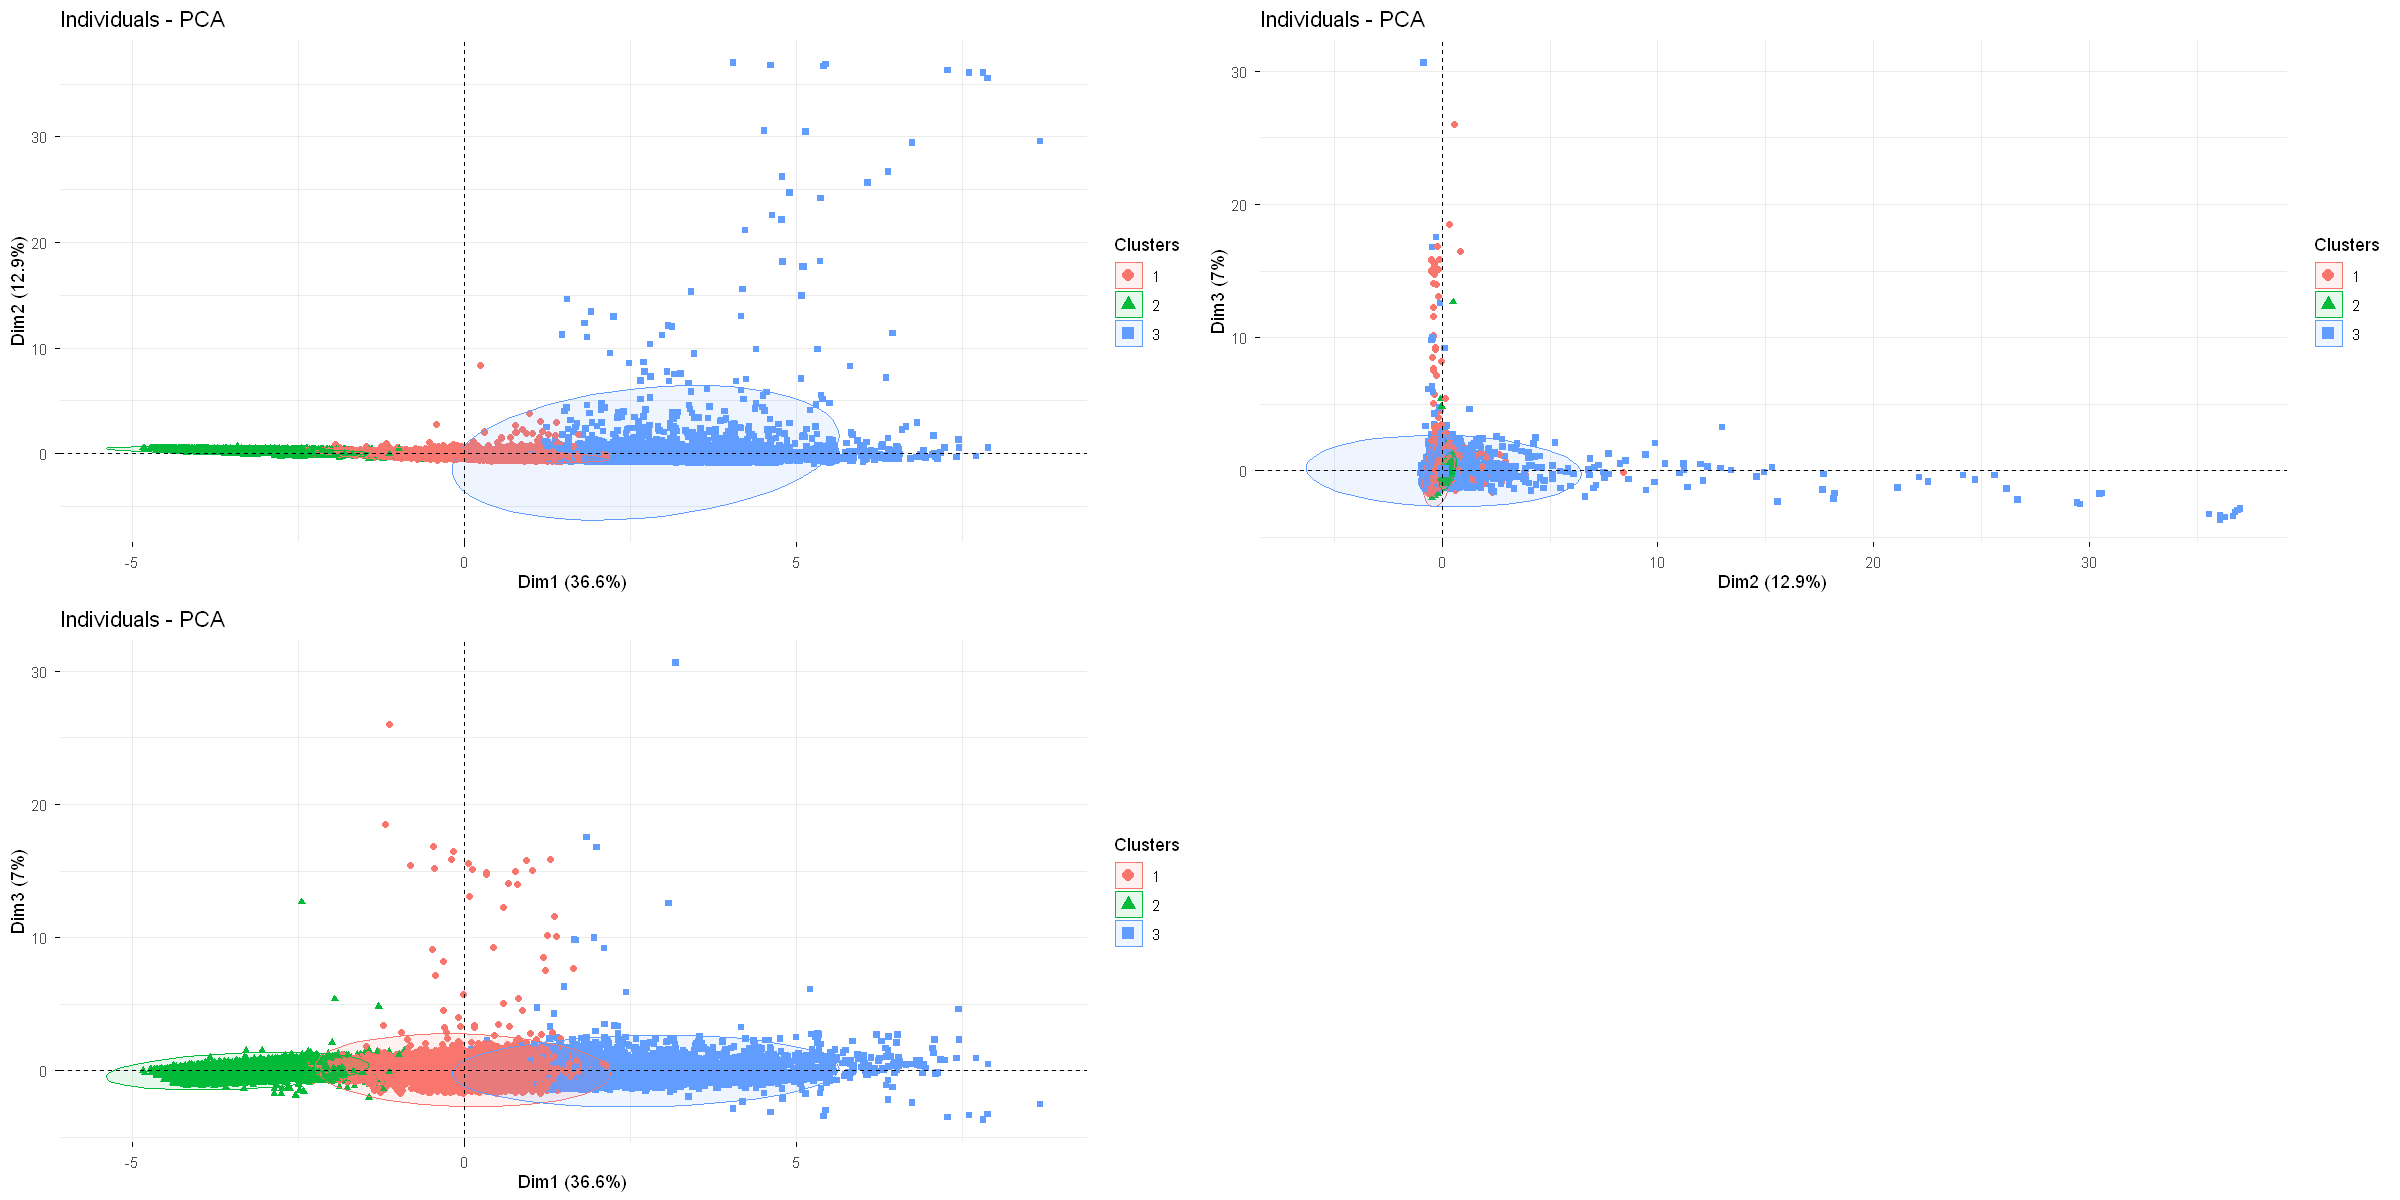

In [164]:
options(repr.plot.width = 20, repr.plot.height =10)

f1=fviz_pca_ind(pca.pop,
             geom.ind = "point",
             col.ind = factor(kmeans3$cluster),
             addEllipses = TRUE,
             legend.title = "Clusters")

f2=fviz_pca_ind(pca.pop,
             geom.ind = "point",
             col.ind = factor(kmeans3$cluster),
             addEllipses = TRUE,
             legend.title = "Clusters",
             axes=c(2,3))
f3=fviz_pca_ind(pca.pop,
             geom.ind = "point",
             col.ind = factor(kmeans3$cluster),
             addEllipses = TRUE,
             legend.title = "Clusters",
             axes=c(1,3))

grid.arrange(f1,f2,f3,ncol=2)

Avec l'ACP , on a vu en examinant le cercle des corrélations que l'axe 1 est porté par des variables de succès et d'engagement massif telles que LPositive, LNegative, LRecommendations, LPeak.CCU ainsi que LAverage.playtime.forever. La projection des individus sur ce plan confirme la pertinence du clustering : on observe une graduation très nette le long de cet axe horizontal. Le Cluster 1 (en rouge) se positionne à l'extrême droite, regroupant les titres dont les valeurs pour ces indicateurs sont les plus élevées. À l'opposé, le Cluster 3 (en bleu) se situe à gauche de l'axe, correspondant aux jeux ayant des scores inférieurs à la moyenne. Le Cluster 2 (en vert) occupe une position centrale, représentant le cœur du catalogue avec des statistiques proches de la moyenne globale. Cette structure est d'ailleurs confirmée par le graphique des profils moyens, où le Cluster 1 domine systématiquement les variables d'engagement, tandis que le Cluster 3 reste en retrait.

In [198]:
data.pop$cluster_id_3 <- kmeans3$cluster
data.pop$cluster_id_3=as.factor(data.pop$cluster_id_3)

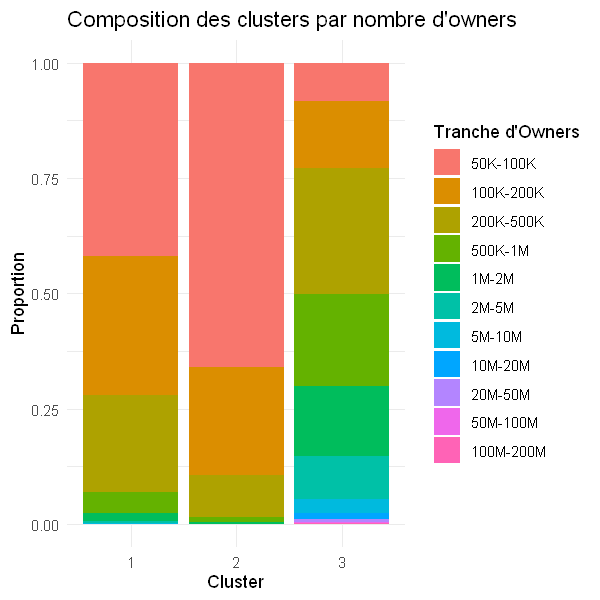

In [167]:
options(repr.plot.width = 5, repr.plot.height =5)
ggplot(data.pop, aes(x = factor(cluster_id_3), fill = Estimated.owners)) +
  geom_bar(position = "fill") +
  labs(title = "Composition des clusters par nombre d'owners",
       x = "Cluster",
       y = "Proportion",
       fill = "Tranche d'Owners") +
  theme_minimal()

On observe une hiérarchie de succès:

Cluster 1 : C'est le seul cluster qui contient des proportions significatives de jeux à plus de 1M d'owners (les couleurs bleues, violettes et roses en bas de la barre). C'est le cluster "Succès Confirmés & Blockbusters".

Cluster 2 : Il est dominé par les tranches 200K-500K et 500K-1M. Ce sont des jeux qui ont bien marché.

Cluster 3 : Il est composé à plus de 75% par les tranches 50K-100K et 100K-200K. Ce sont les jeux les "plus petits" de notre échantillon (rappelons qu'on a déja enlevé les jeux de moins de 50k).

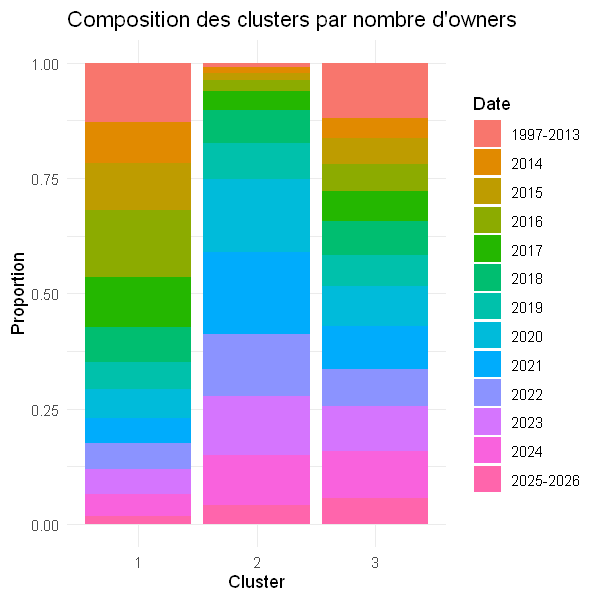

In [168]:
#Pour la date
ggplot(data.pop, aes(x = factor(cluster_id_3), fill = Release.date)) +
  geom_bar(position = "fill") +
  labs(title = "Composition des clusters par date de sortie",
       x = "Cluster",
       y = "Proportion",
       fill = "Date") +
  theme_minimal()

In [71]:
# Encodage du genre avec les groupes de jeux qu'on a trouvé

# On sépare les genres par la virgule
data.pop_genres <- data.pop %>%
  separate_rows(Genres, sep = ",") %>%
  mutate(presence = 1, Genres = paste0("Genres_", Genres)) %>%
  pivot_wider(names_from = Genres, values_from = presence, values_fill = 0)

data.pop_genres <- data.pop_genres %>%
  mutate(
    Genres_Mature = if_else(Genres_Gore == 1 | 
                           Genres_Nudity == 1 | 
                           `Genres_Sexual Content` == 1 | 
                           Genres_Violent == 1, 1, 0),

    #Pas besoin du Genre vidéo parce que dans data.pop il n'y avait qu'un jeu avec Movies et les autres genres de Genres_vidéo n'existait pas pour ce df
      
    Genres_Outils = if_else(`Genres_Video Production` == 1 | 
                           `Genres_Design & Illustration` == 1 | 
                           `Genres_Animation & Modeling` == 1 | 
                           `Genres_Game Development` == 1 | 
                           `Genres_Audio Production` == 1 | 
                           `Genres_Photo Editing` == 1 | 
                           `Genres_Software Training` == 1 | 
                           Genres_Education == 1 | 
                           Genres_Utilities == 1 | 
                           `Genres_Web Publishing` == 1, 1, 0)
  ) %>%
  mutate(across(starts_with("Genres_"), as.factor))

cols_to_remove <- c("Genres_Gore", "Genres_Violent", "Genres_Video Production","Genres_Sexual Content","Genres_Nudity",
                    "Genres_Design & Illustration", "Genres_Animation & Modeling","Genres_Game Development",
                    "Genres_Audio Production","Genres_Photo Editing", "Genres_Software Training",
                    "Genres_Education", "Genres_Utilities", "Genres_Web Publishing","Genres_Movie")

data.pop_genres <- data.pop_genres %>%
  select(-all_of(cols_to_remove))
summary(data.pop_genres)

     Name              Release.date   Estimated.owners  Required.age  
 Length:14132       1997-2013:1424   50K-100K :5349    0      :13369  
 Class :character   2016     :1361   100K-200K:3450    17     :  580  
 Mode  :character   2021     :1293   200K-500K:2845    13     :   95  
                    2020     :1284   500K-1M  :1150    18     :   49  
                    2017     :1149   1M-2M    : 720    16     :   21  
                    2023     :1149   2M-5M    : 400    10     :   10  
                    (Other)  :6472   (Other)  : 218    (Other):    8  
    Discount       Windows         Mac         Linux       Metacritic.score
 Min.   :  0.00   False:    2   False:9978   False:11307   Min.   : 0.00   
 1st Qu.:  0.00   True :14130   True :4154   True : 2825   1st Qu.: 0.00   
 Median : 33.50                                            Median : 0.00   
 Mean   : 35.48                                            Mean   :16.36   
 3rd Qu.: 70.00                                     

In [170]:
#affichage des genres les plus répendu dans ce df


cols_genres <- data.pop_genres[, grep("Genres_", names(data.pop_genres))]

sommes_genres <- sapply(cols_genres, function(x) sum(as.numeric(as.character(x)), na.rm = TRUE))


sort(sommes_genres, decreasing = TRUE)[1:10]

Genres_Indie                Genres_Action 
                        8970                         6513 
            Genres_Adventure                Genres_Casual 
                        5966                         3992 
                  Genres_RPG              Genres_Strategy 
                        3543                         3501 
           Genres_Simulation          Genres_Free To Play 
                        3101                         1671 
         Genres_Early Access Genres_Massively Multiplayer 
                         931                          608

In [42]:
options(repr.plot.width = 20, repr.plot.height =10)
gg1=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Indie)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Indie' par Cluster", x = "Cluster", y = "Proportion") 
gg2 = ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Action)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Action' par Cluster", x = "Cluster", y = "Proportion") 
gg3=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Adventure)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Adventure' par Cluster", x = "Cluster", y = "Proportion") 
gg4=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Casual)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Casual' par Cluster", x = "Cluster", y = "Proportion") 
gg5=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_RPG)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'RPG' par Cluster", x = "Cluster", y = "Proportion") 
gg6=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Strategy)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Strategy' par Cluster", x = "Cluster", y = "Proportion") 
gg7=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Simulation)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Simulation' par Cluster", x = "Cluster", y = "Proportion") 
gg8=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = `Genres_Free To Play`)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Free To Play' par Cluster", x = "Cluster", y = "Proportion") 
gg9=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = `Genres_Free To Play`)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Free To Play' par Cluster", x = "Cluster", y = "Proportion") 

grid.arrange(gg1,gg2,gg3,gg4,gg5,gg6,gg7,gg8,gg9,ncol=4)

ERROR: Error: objet 'data.pop_genres' introuvable


Le genre Indie est beaucoup moins présent dans le Cluster 1 que dans les clusters 2 et 3. Sachant que ces jeux sont les jeux sont les jeux à succès c'est cohérent. De la même manière le genre Casual est moins présent dans le cluster 1 que les autres ("Les jeux "Casual" ont tendance à générer moins d'engagement massif (moins de playtime, moins de Peak CCU) que les jeux plus "Core", ce qui explique pourquoi ils sont sous-représentés dans l'élite du Cluster 1."). Il y a une part plus élevée de jeux gratuits dans le cluster 3 et beacoup moins dans le 1, c'est cohérent avec le profil moyen.

In [267]:
# D'après https://gamalytic.com/publisher-list , liste des publishers AAA:
publishers_aaa <- c("Valve", "Electronic Arts", "EA ", "Ubisoft", "Bandai Namco", 
                    "Capcom", "Xbox Game Studios", "Microsoft", "Bethesda", 
                    "2K", "SEGA", "Activision", "PlayStation Publishing", 
                    "Warner Bros", "Square Enix", "Rockstar Games", "KRAFTON, Inc")

data.pop$is_AAA <- ifelse(grepl(paste(publishers_aaa, collapse = "|"), 
                                data.pop$Publisher, ignore.case = TRUE), 1, 0)

data.pop$is_AAA <- as.factor(data.pop$is_AAA)

table(data.pop$is_AAA)


    0     1 
13086  1046 

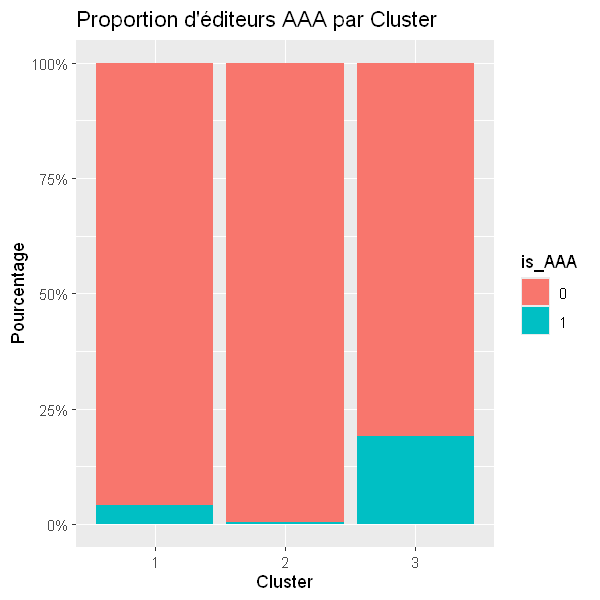

In [173]:
options(repr.plot.width = 5, repr.plot.height =5)
ggplot(data.pop, aes(x = factor(cluster_id_3), fill = is_AAA)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Proportion d'éditeurs AAA par Cluster",
       x = "Cluster",
       y = "Pourcentage") 

### K-means sur les données issues de l'ACP (nb cluster= 2)

In [43]:
kmeans.pca = kmeans(pca.pop$ind$coord[,1:7], centers=2)
cluster_counts = data.frame(table(kmeans.pca$cluster))
cluster_counts

Var1,Freq
<fct>,<int>
1,4766
2,9366


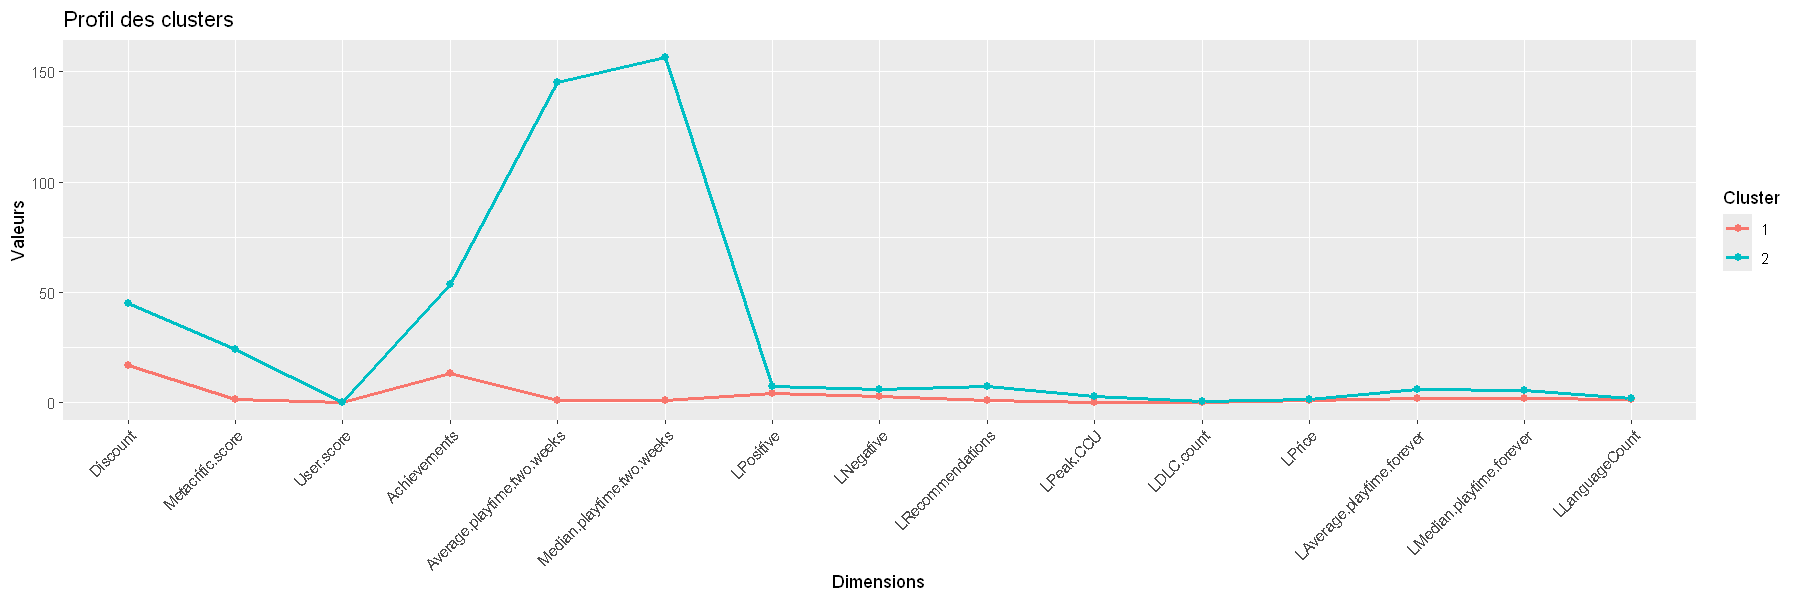

In [51]:
options(repr.plot.width = 15, repr.plot.height =5)
mean_profile = aggregate(data.pop.quanti, by = list(cluster = kmeans.pca$cluster), FUN = mean)
plot_data <- melt(mean_profile, id.vars = "cluster")

ggplot(plot_data, aes(x = variable, y = value, color = factor(cluster), group = cluster)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Profil des clusters",
       x = "Dimensions",
       y = "Valeurs",
       color = "Cluster")

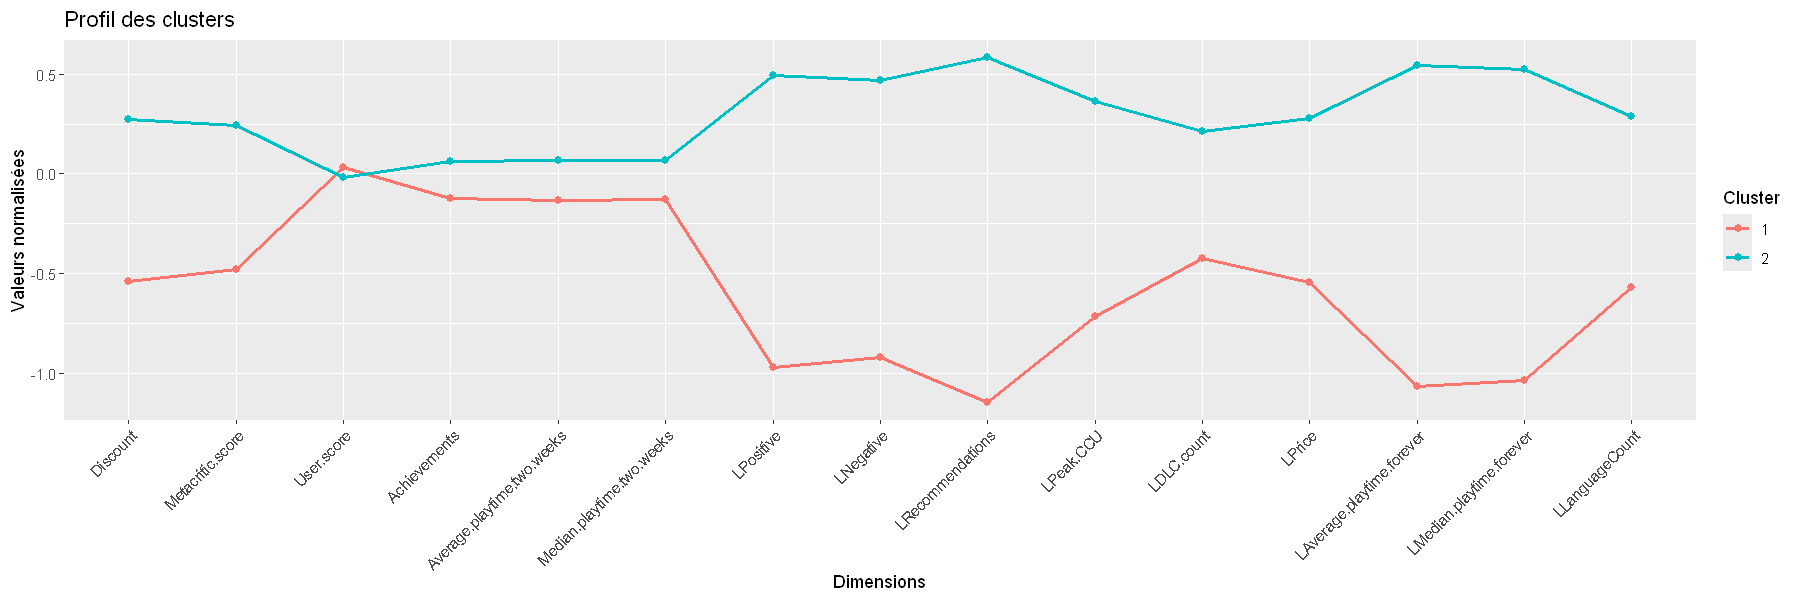

In [52]:
options(repr.plot.width = 15, repr.plot.height =5)
mean_profile = aggregate(data.pop.scale, by = list(cluster = kmeans.pca$cluster), FUN = mean)
plot_data <- melt(mean_profile, id.vars = "cluster")

ggplot(plot_data, aes(x = variable, y = value, color = factor(cluster), group = cluster)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Profil des clusters",
       x = "Dimensions",
       y = "Valeurs normalisées",
       color = "Cluster")

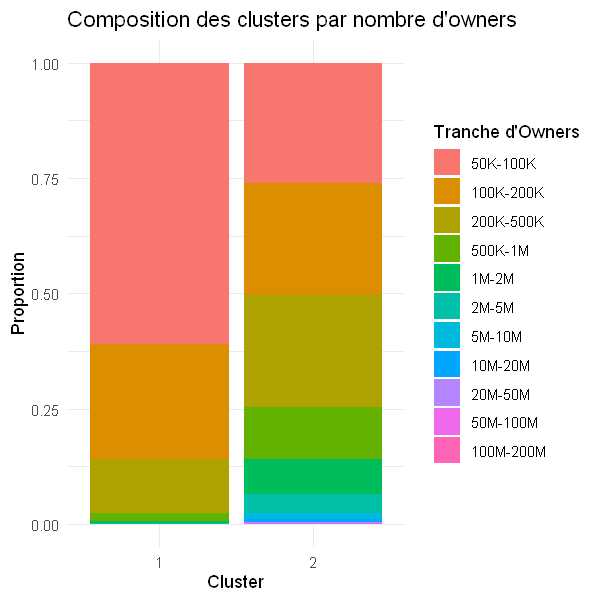

In [55]:
data.pop$cluster_id_2 <- kmeans.pca$cluster
data.pop$cluster_id_2 =as.factor(data.pop$cluster_id_2)
options(repr.plot.width = 5, repr.plot.height =5)
ggplot(data.pop, aes(x = factor(cluster_id_2), fill = Estimated.owners)) +
  geom_bar(position = "fill") +
  labs(title = "Composition des clusters par nombre d'owners",
       x = "Cluster",
       y = "Proportion",
       fill = "Tranche d'Owners") +
  theme_minimal()

Ignoring unknown labels:
• linetype : "Clusters"
Ignoring unknown labels:
• linetype : "Clusters"
Ignoring unknown labels:
• linetype : "Clusters"


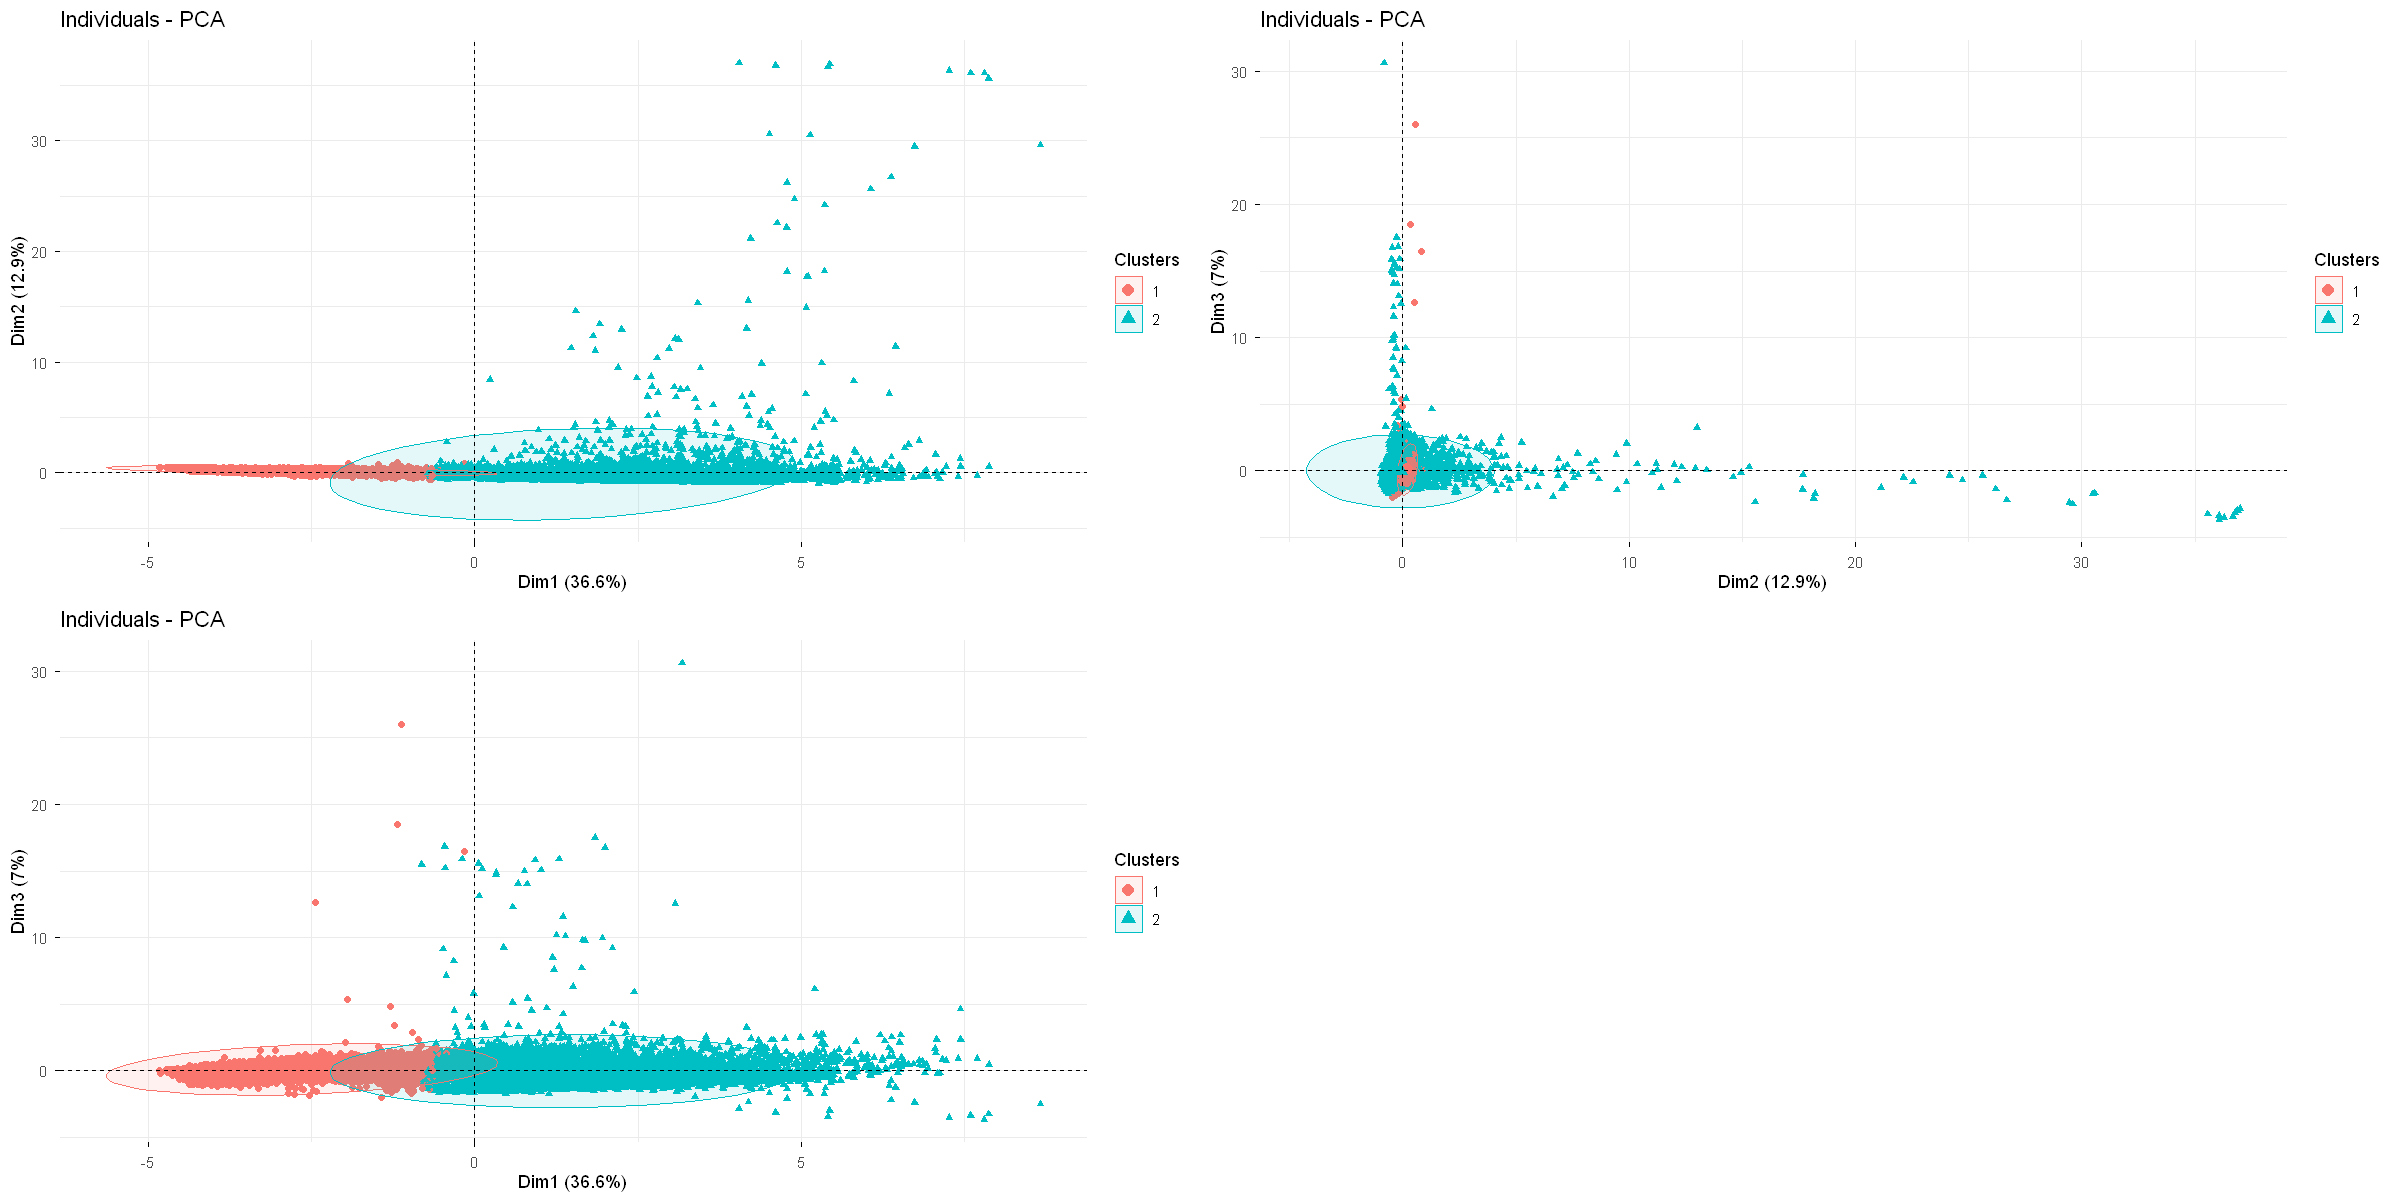

In [48]:
options(repr.plot.width = 20, repr.plot.height =10)

f1=fviz_pca_ind(pca.pop,
             geom.ind = "point",
             col.ind = factor(kmeans.pca$cluster),
             addEllipses = TRUE,
             legend.title = "Clusters")

f2=fviz_pca_ind(pca.pop,
             geom.ind = "point",
             col.ind = factor(kmeans.pca$cluster),
             addEllipses = TRUE,
             legend.title = "Clusters",
             axes=c(2,3))
f3=fviz_pca_ind(pca.pop,
             geom.ind = "point",
             col.ind = factor(kmeans.pca$cluster),
             addEllipses = TRUE,
             legend.title = "Clusters",
             axes=c(1,3))

grid.arrange(f1,f2,f3,ncol=2)

### GMM

On utilise le GMM sur les composantes principales de l'ACP. On choisit de retenir 7 composantes (qui expliquent 82% de la variance).

In [56]:
#On utilise le critère BIC pour déterminer le meilleur modèle et le nombre de cluster optimal
resBIC = mclustBIC(pca.pop$ind$coord[,1:7], G=1:15)
summary(resBIC)

resBIC = Mclust(pca.pop$ind$coord[,1:7], G=1:15)

Best BIC values:
            VEV,15     VEV,14    VEV,13
BIC      -18409.61 -20020.120 -21466.74
BIC diff      0.00  -1610.508  -3057.13

Warning message:
"`gather_()` was deprecated in tidyr 1.2.0.
ℹ Please use `gather()` instead.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."


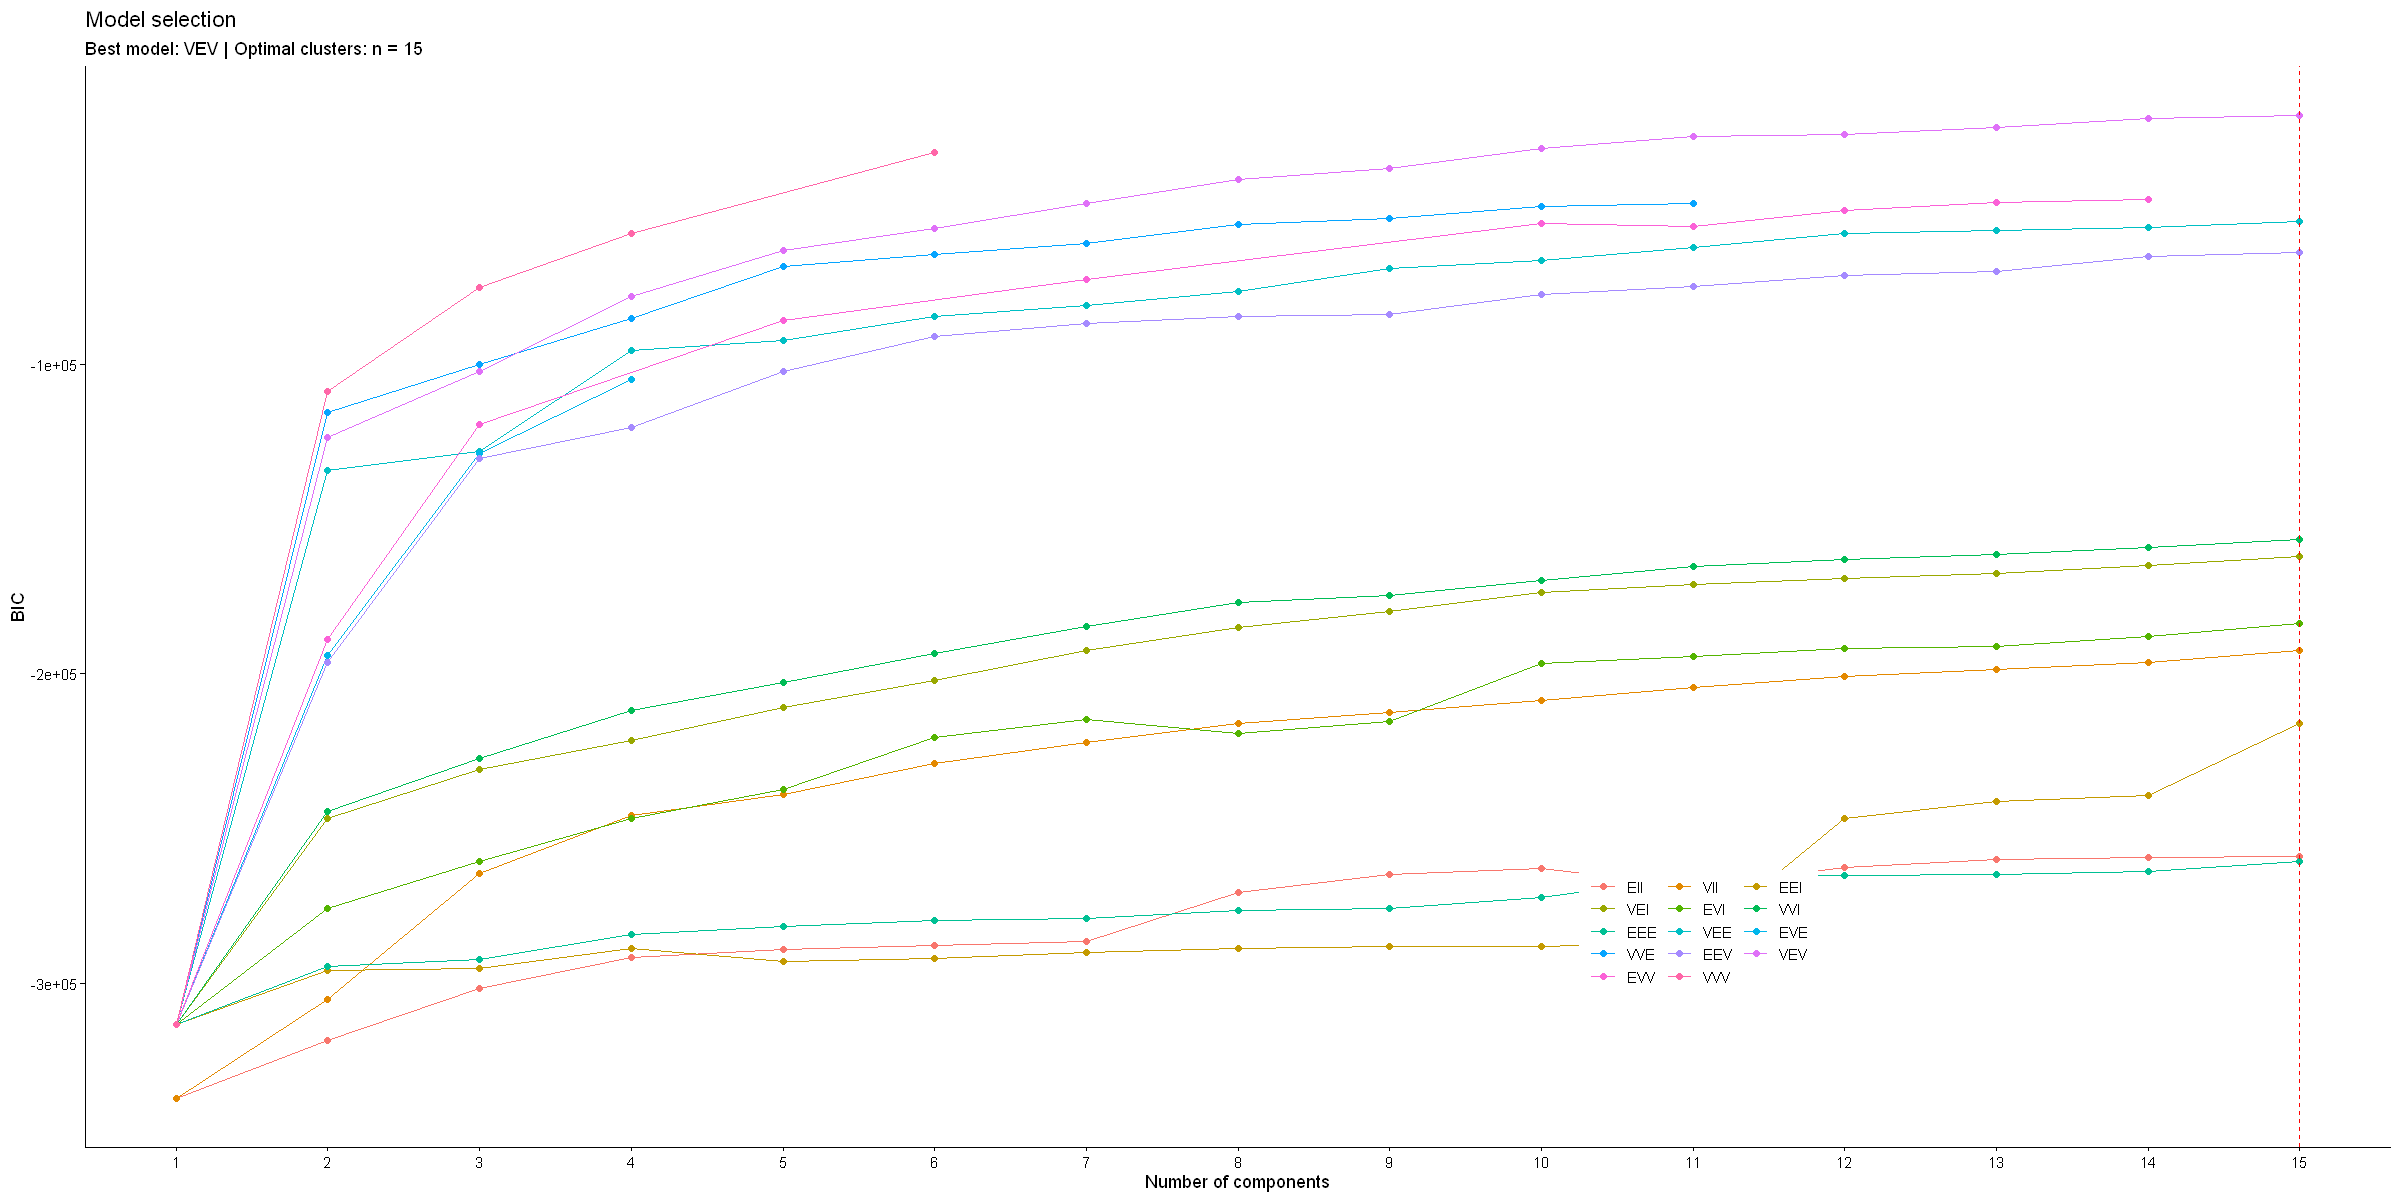

In [57]:
options(repr.plot.width = 20, repr.plot.height =10)
fviz_mclust(resBIC, what="BIC")

Le fait que le BIC (Bayesian Information Criterion) augmente sans jamais redescendre (même à 15 clusters) signifie que chaque nouveau cluster ajouté permet d'affiner encore un peu plus la description de la densité des données sans que la "pénalité de complexité" ne l'emporte. La séparation des données n'est donc pas nette. Cela révèle une structure de données continue (continuum) plutôt que des groupes naturellement disjoints. Cependant, pour répondre à notre problématique de typologie métier, nous avons opté pour une solution à 5 clusters.

#### Avec 10 clusters 

In [64]:
options(repr.plot.width = 15, repr.plot.height = 6)

K = 10
gmm = Mclust(pca.pop$ind$coord[,1:7], G=K, modelNames = "VEV")
p1 = fviz_cluster(gmm, data=pca.pop$ind$coord[,1:7], ellipse.type="norm", geom="point")


In [66]:
cluster_gmm_count_10 = data.frame(table(gmm$classification))
cluster_gmm_count_10

Var1,Freq
<fct>,<int>
1,1179
2,1127
3,1256
4,683
5,5393
6,1274
7,709
8,1469
9,894


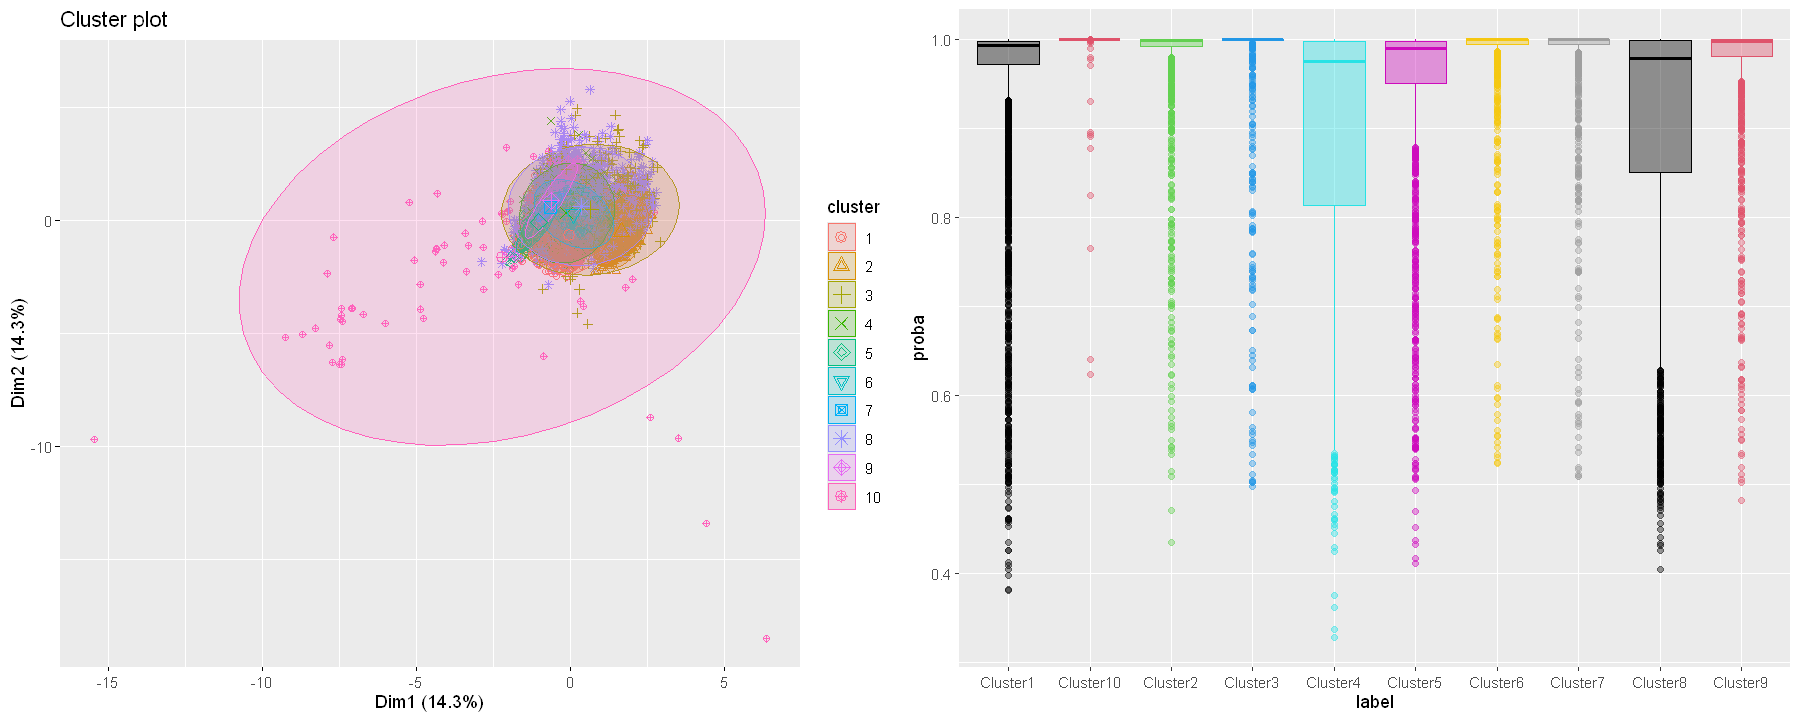

In [226]:
aux = data.frame(
    label = paste("Cluster", gmm$classification, sep=""), 
    proba = apply(gmm$z, 1, max))

p2 = ggplot(aux, aes(x=label, y=proba)) + 
    geom_boxplot(colour=1:K, fill=1:K, alpha=.4)

grid.arrange(p1,p2,ncol=2)

Le graphique des probabilités d'appartenance aux clusters valide le choix du modèle GMM à 10 classes. On observe que la majorité des clusters (notamment les clusters 1, 7 et 10) présentent des probabilités d'assignation proches de 1, témoignant d'une forte certitude du modèle. À l'inverse, les clusters 4 et 8 affichent des boîtes à moustaches plus étirées vers le bas, révélant l'existence de jeux situés aux frontières de plusieurs profils.

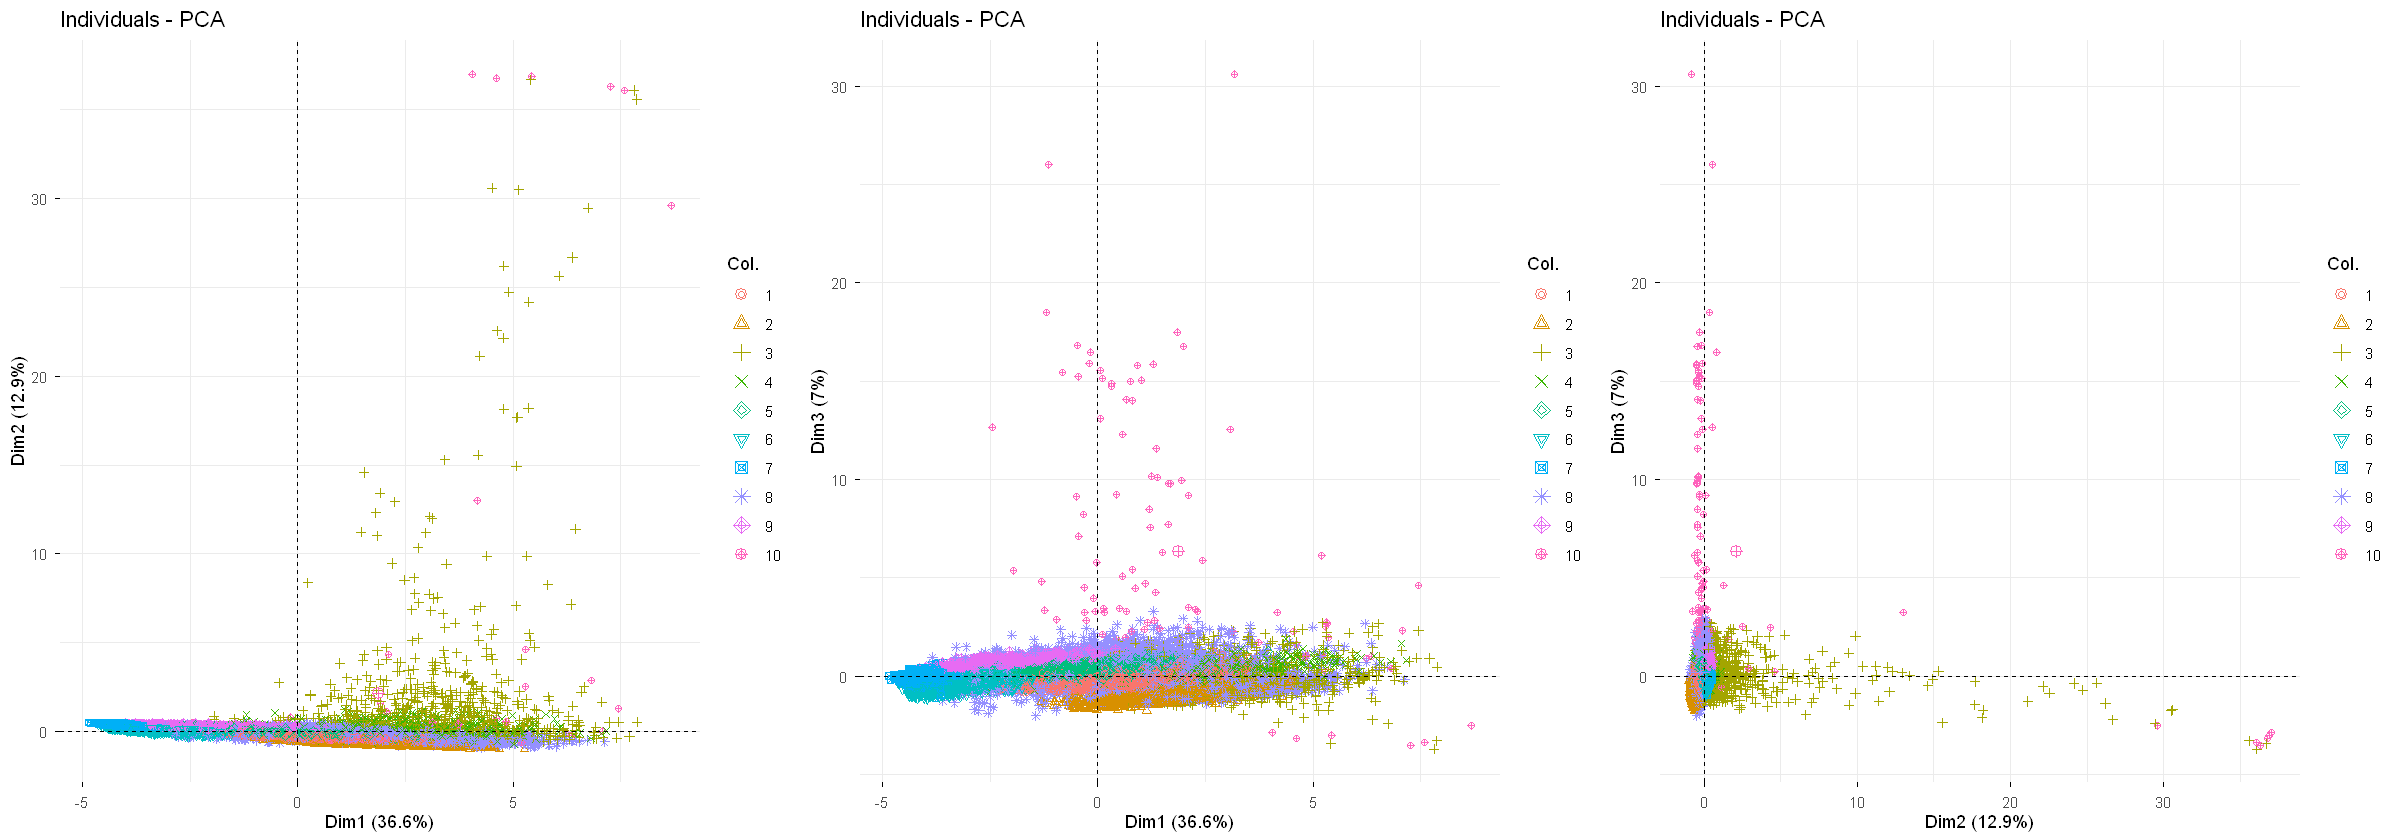

In [229]:
options(repr.plot.width = 20, repr.plot.height = 7)

grid.arrange(
    fviz_pca_ind(pca.pop, axes=c(1,2), geom = c("point"), col.ind=as.factor(gmm$classification)),
    fviz_pca_ind(pca.pop, axes=c(1,3), geom=c("point"), col.ind=as.factor(gmm$classification)),
    fviz_pca_ind(pca.pop, axes=c(2,3), geom=c("point"), col.ind=as.factor(gmm$classification)),
    ncol=3)

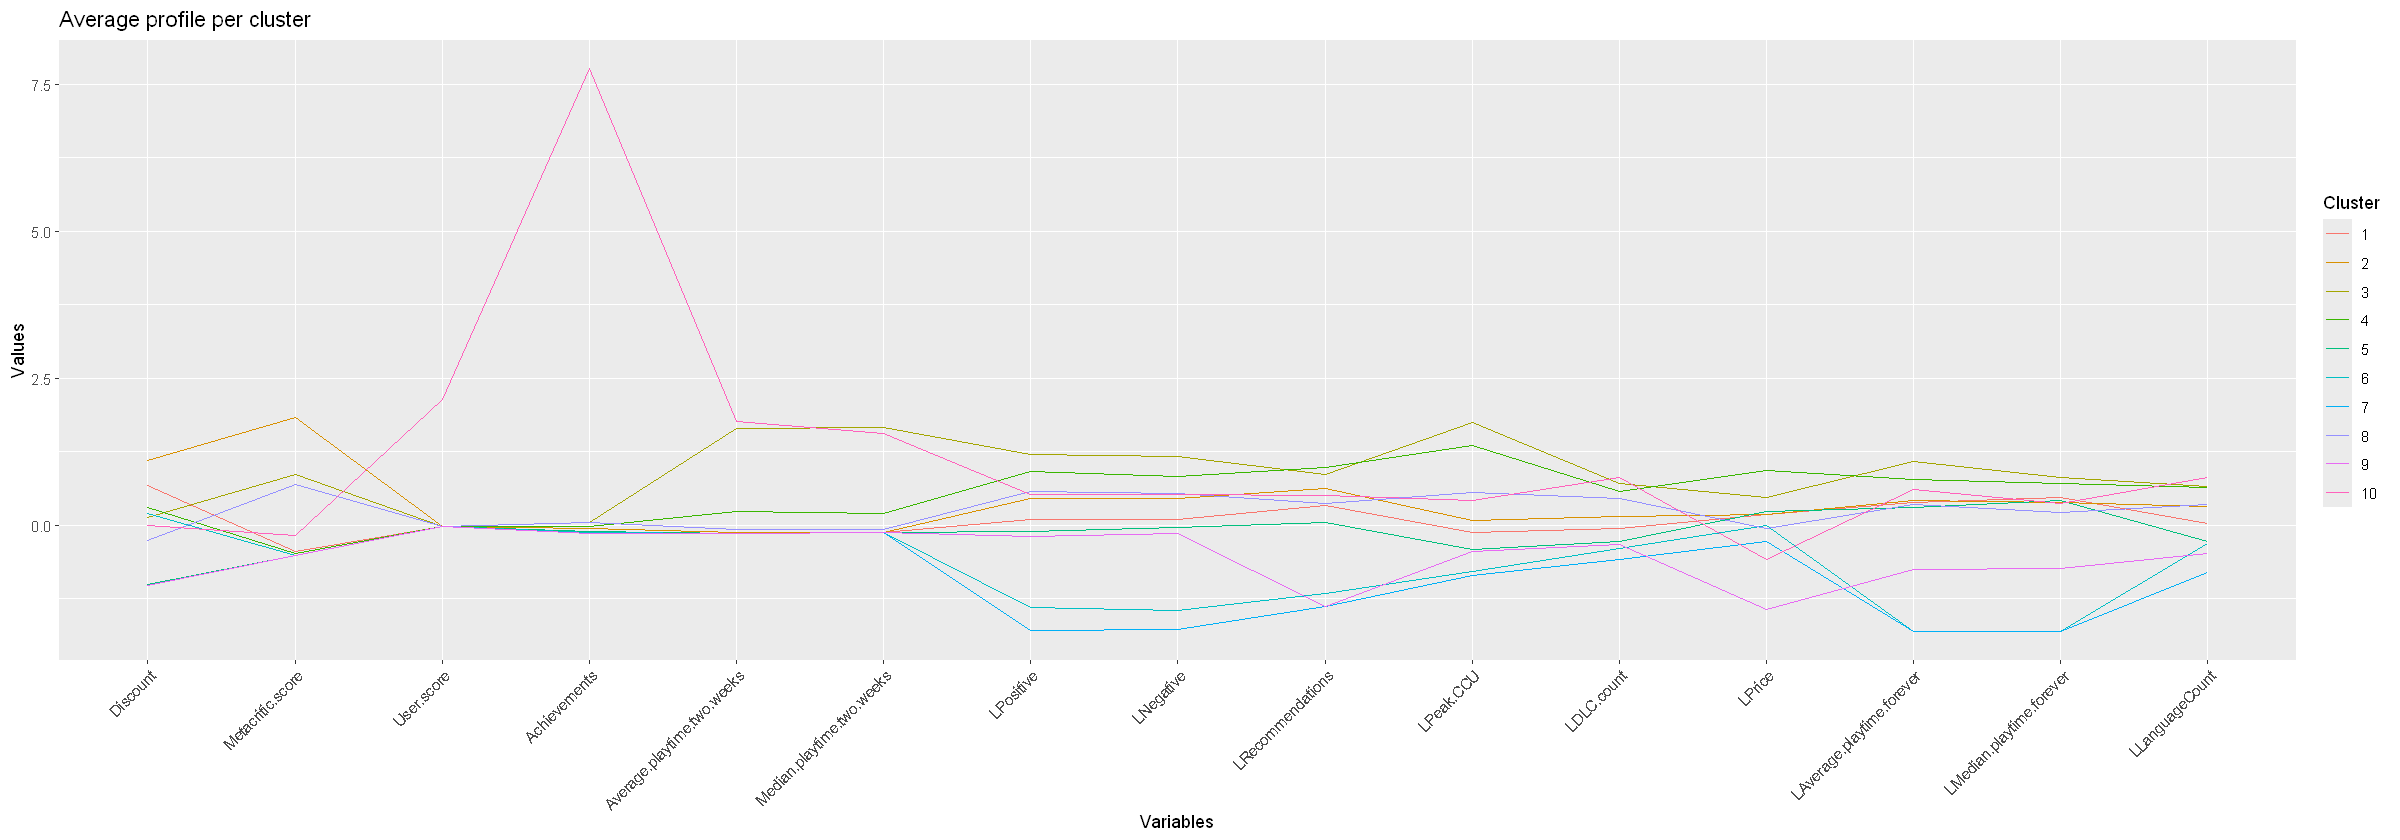

In [233]:
#Averages profiles

mean_profiles_gmm = aggregate(data.pop.scale, by = list(cluster = gmm$classification), FUN = mean)
mean_profiles_gmm = melt(mean_profiles_gmm, id.vars = "cluster")

ggplot(mean_profiles_gmm, aes(x = variable, y = value, color = factor(cluster), group = cluster)) +
  geom_line() +  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Average profile per cluster", x = "Variables", y = "Values") +
  scale_color_discrete(name = "Cluster")

L'analyse des profils moyens permet d'en savoir plus sur les clusters. Le modèle isole des comportements spécifiques avec 3 clusters : le Cluster 9 se distingue uniquement par un volume massif d'achievements, tandis que les Clusters 3 et 4 regroupent sûrement les plus populaires avec des scores de popularité et d'engagement et de temps de jeux(LPeak.CCU, LPositive, LAverage.playtimr.forever,two.weeks pour cluster 3) largement supérieurs à la moyenne. Enfin, les Clusters 6 et 7 se caractérisent par un temps de jeu et des recommandations très faibles, marquant probablement les produits de niche du catalogue (public ciblé) avec aussi moins de langues disponibles que la moyenne.

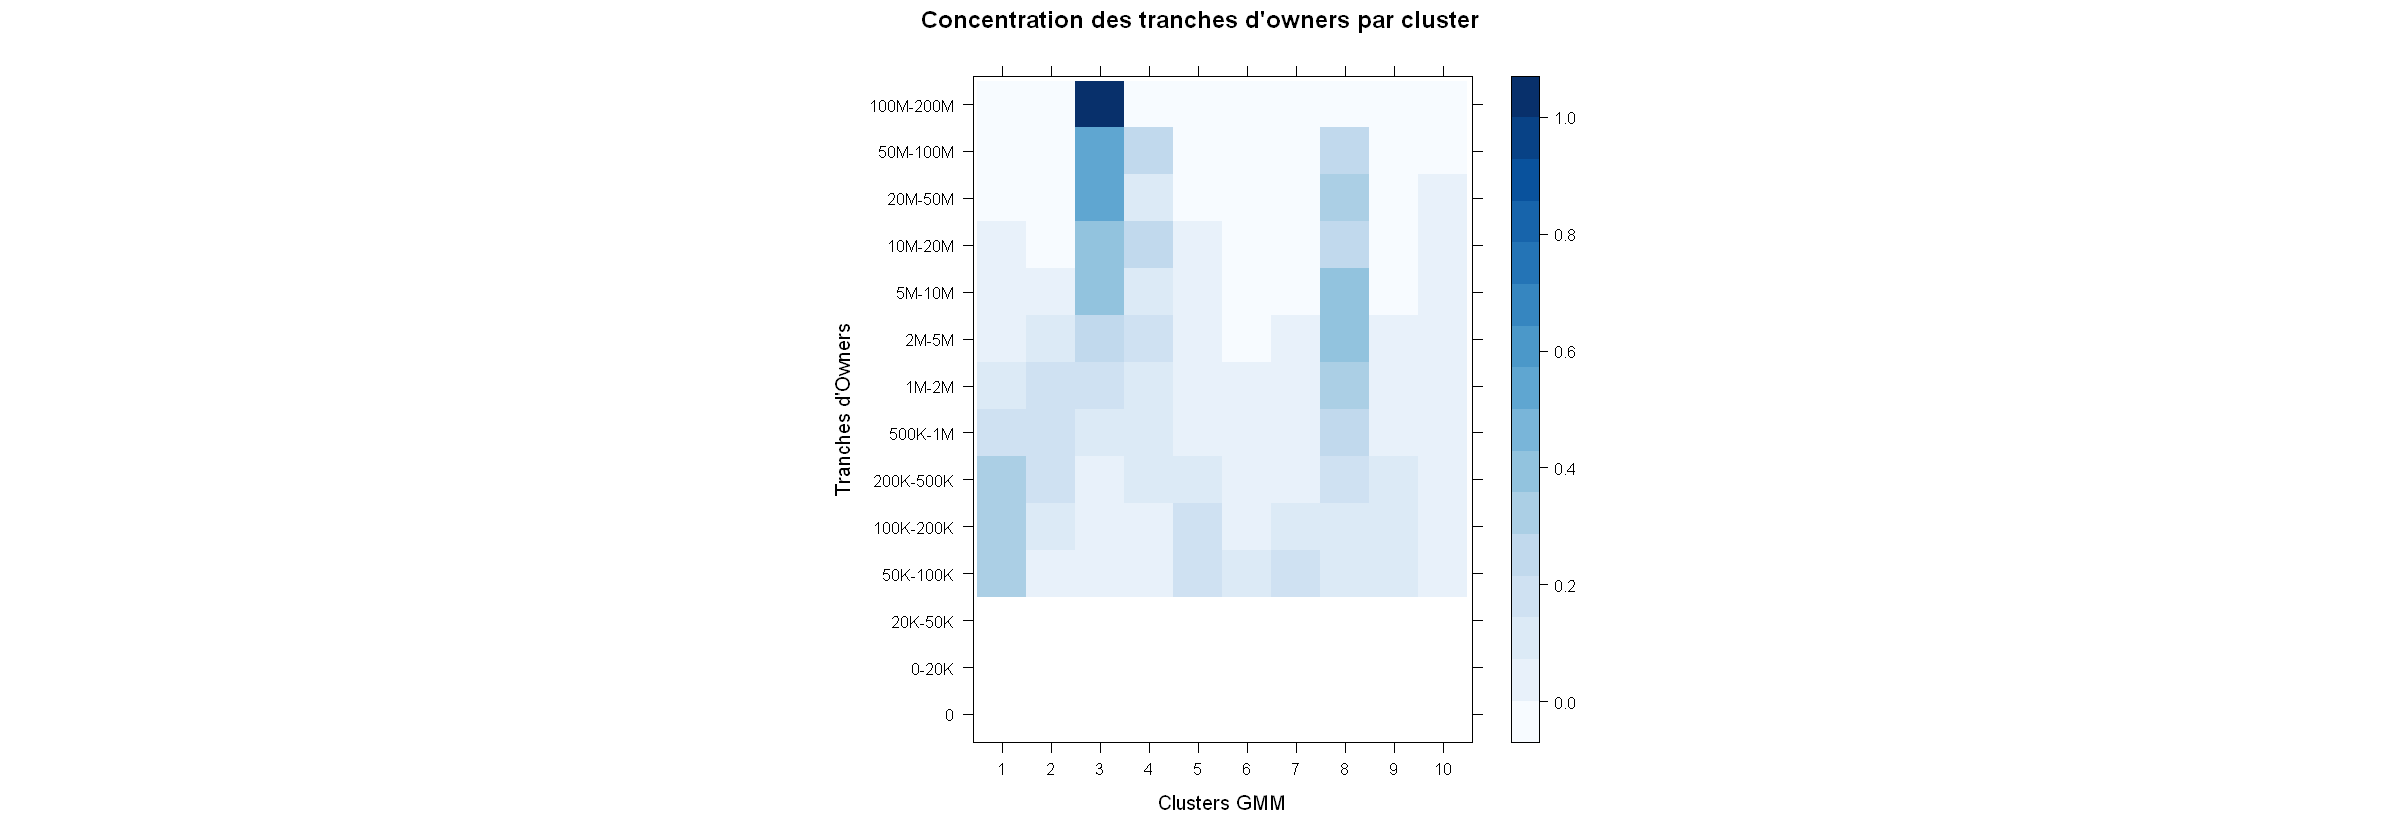

In [255]:
library(lattice)
library(RColorBrewer)

tab_prop <- prop.table(table(data.pop$cluster_gmm, data.pop$Estimated.owners),margin = 2)

coul <- colorRampPalette(brewer.pal(9, "Blues"))(100)

levelplot(tab_prop, 
          col.regions = coul, 
          main = "Concentration des tranches d'owners par cluster",
          xlab = "Clusters GMM", 
          ylab = "Tranches d'Owners")

L'analyse de la concentration des tranches d'utilisateurs par cluster confirme la pertinence de la segmentation issue du modèle GMM dans le cadre de l'étude de popularité. Le Cluster 3 capte l'intégralité des jeux au succès phénoménal (tranche 100M-200M) et la grande majorité des titres au-delà de 20 millions d'utilisateurs. Il incarne ainsi le segment des jeux à très grand succès.

À l'opposé, les Clusters 1 et 5 se concentrent sur les tranches de succès modeste (50K à 500K). Le Cluster 8 se distingue comme un segment intermédiaire solide, captant une part significative des jeux entre 2 et 10 millions d'owners. Cette visualisation prouve que les variables que le GMM utilise sont des indicateurs/conséquences du le volume de ventes (Owners) et structurent de la répartition des jeux sur la plateforme.

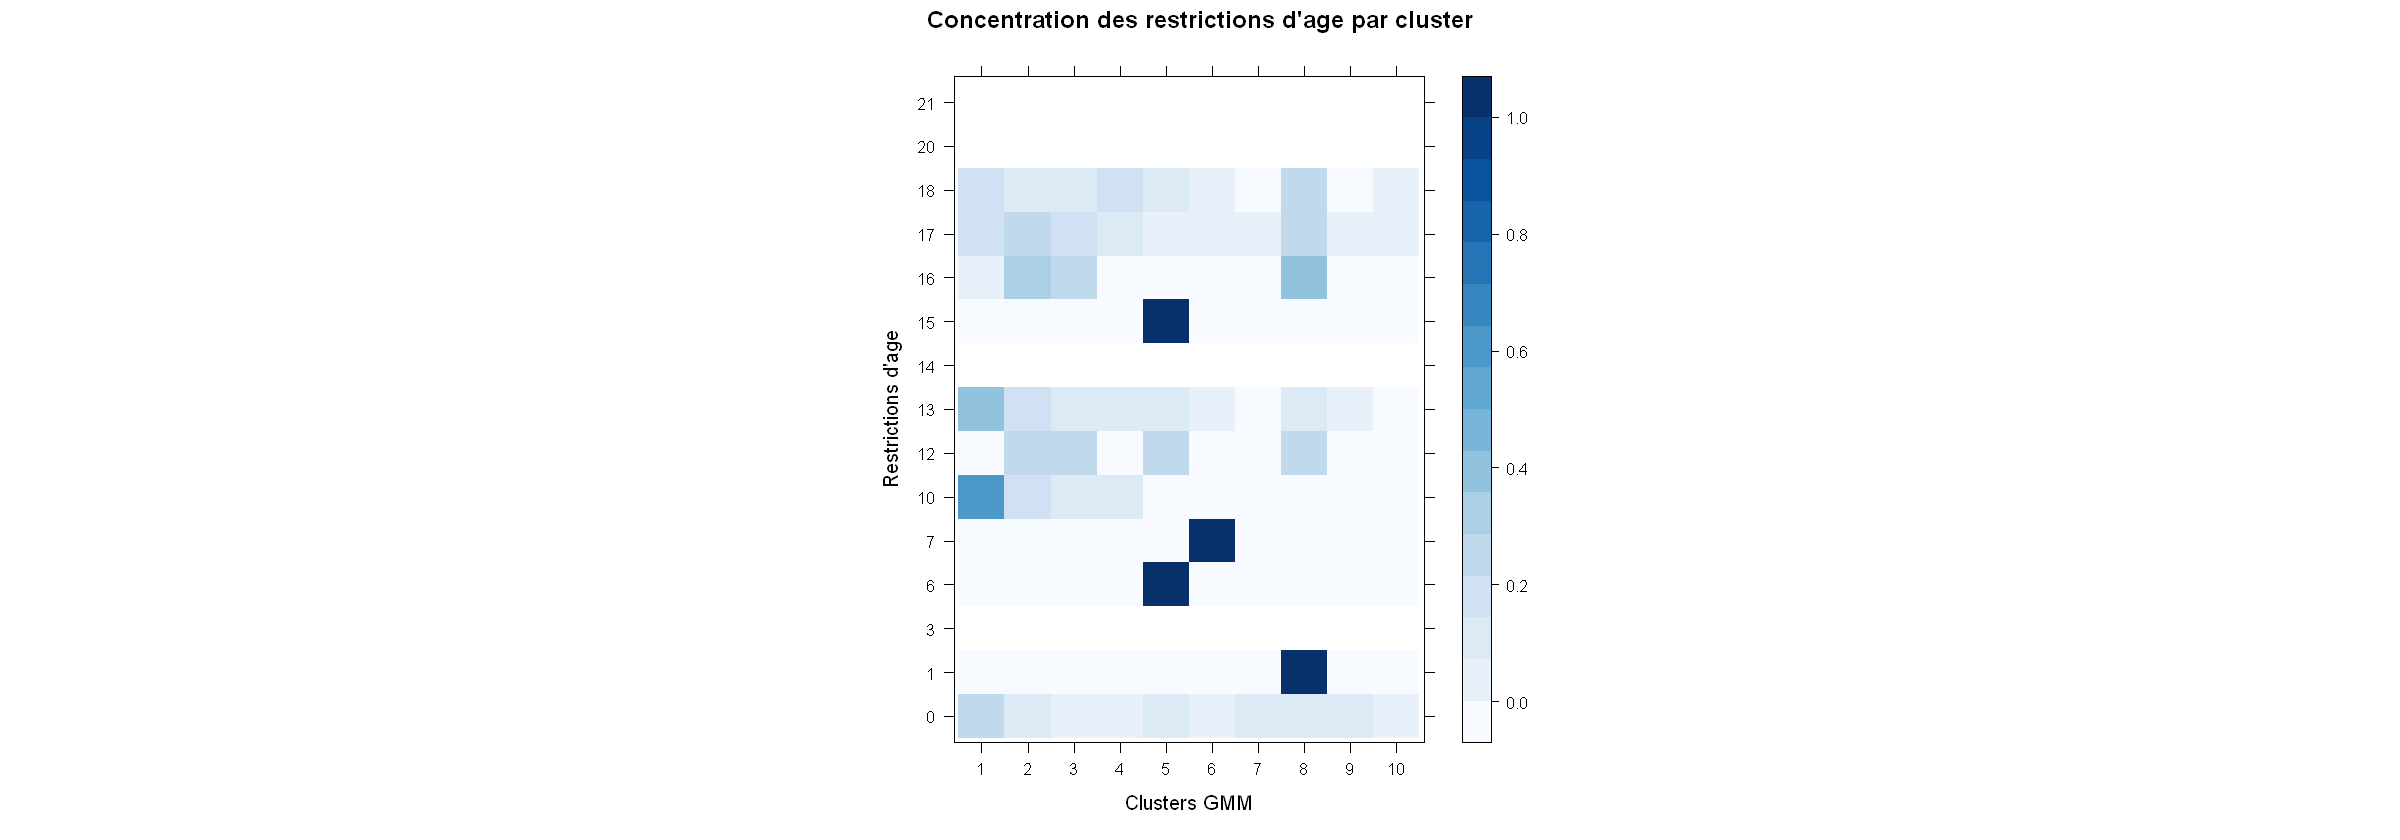

In [258]:
tab_prop_age <- prop.table(table(data.pop$cluster_gmm, data.pop$Required.age), margin = 2)

coul <- colorRampPalette(brewer.pal(9, "Blues"))(100)

levelplot(tab_prop_age, 
          col.regions = coul, 
          main = "Concentration des restrictions d'age par cluster",
          xlab = "Clusters GMM", 
          ylab = "Restrictions d'age")

Ces clusters (5, 6, 8) ne se définissent pas par leur succès (le nombre de ventes), mais par leur origine géographique ou leur public cible. Par exemple, un cluster qui ne contient que des jeux notés "15" est probablement composé de jeux qui ont dû passer par une certification spécifique (souvent des jeux japonais ou allemands).

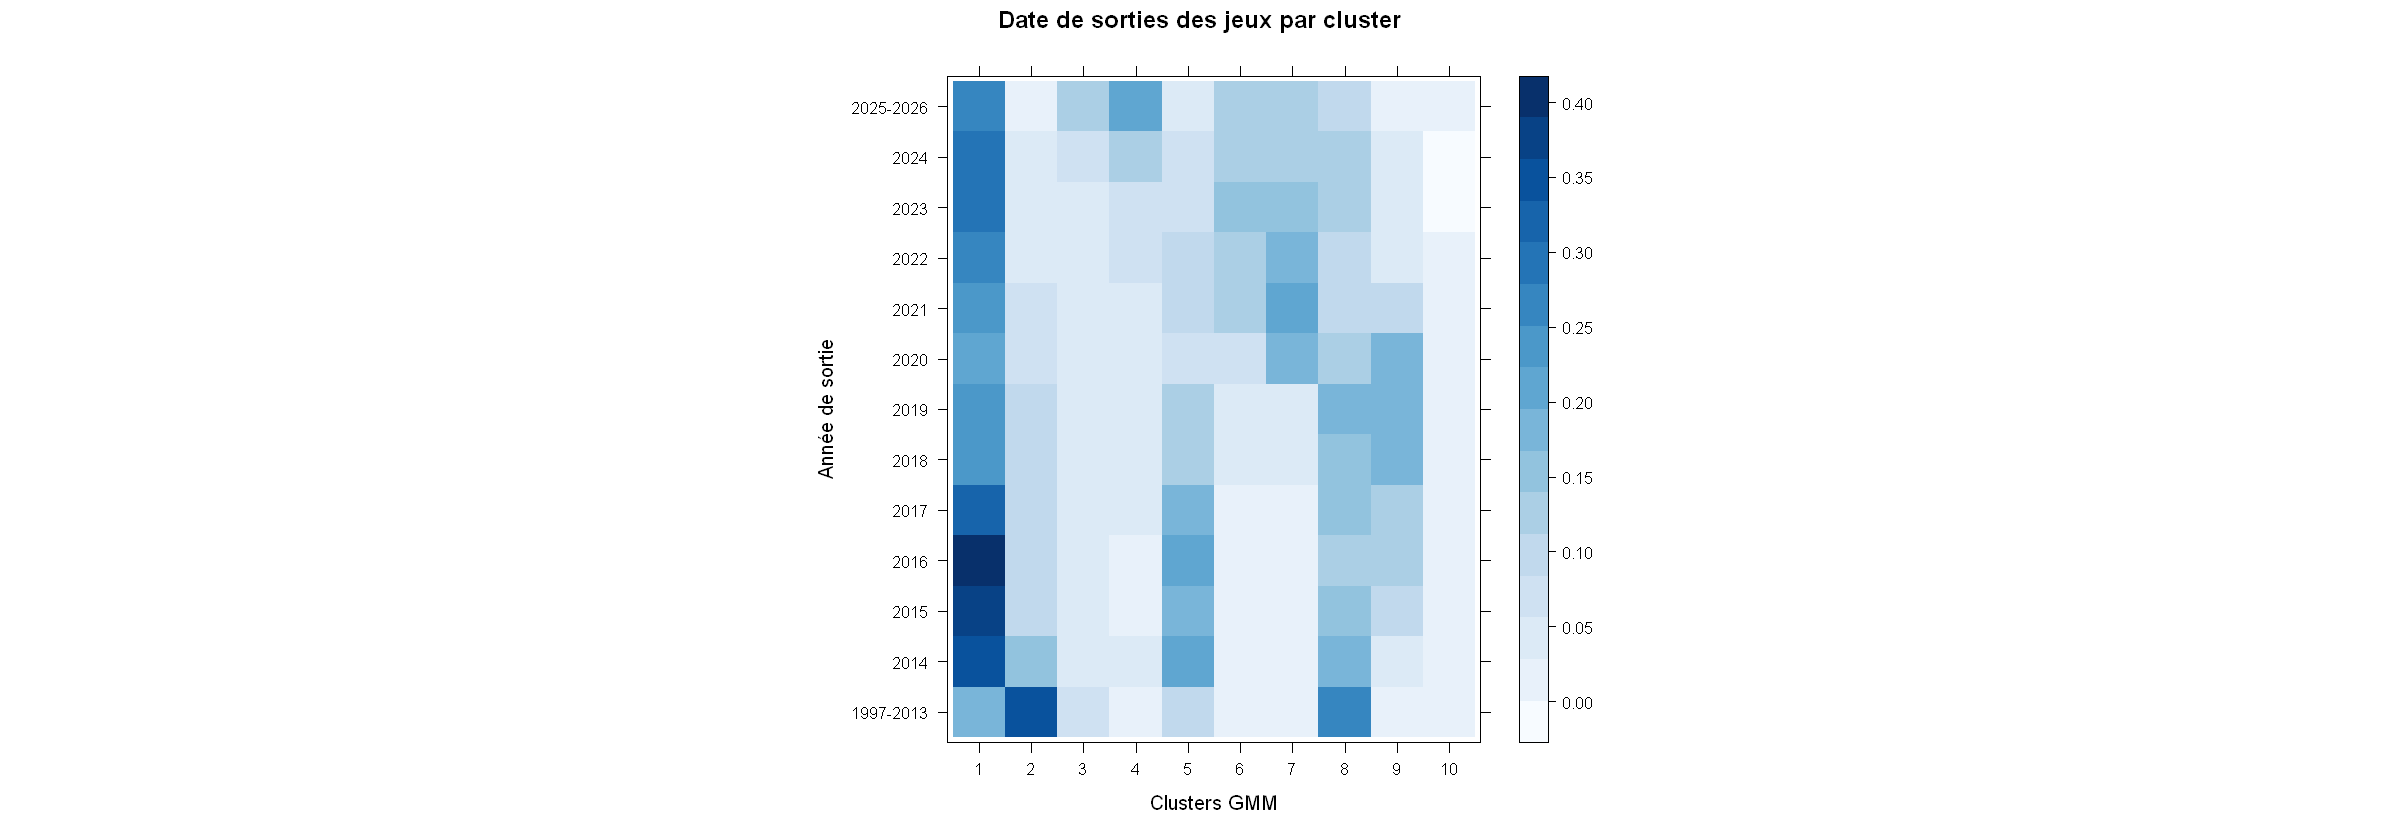

In [259]:
ma_table <- table(data.pop$cluster_gmm, data.pop$Release.date)

tab_prop_date <- prop.table(ma_table, margin = 2)

coul <- colorRampPalette(brewer.pal(9, "Blues"))(100)

levelplot(tab_prop_date, 
          col.regions = coul, 
          main = "Date de sorties des jeux par cluster",
          xlab = "Clusters GMM", 
          ylab = "Année de sortie")

L'analyse de la concentration par date de sortie montre une répartition plus hétérogène que celle des volumes de ventes. On note toutefois que le Cluster 2 possède une identité historique marquée, captant une part prépondérante des titres sortis entre 1997 et 2013. À l'inverse, la faible coloration des clusters "Elite" (3 et 10) à travers toutes les époques souligne que l'accès au succès massif reste un phénomène rare et indépendant de l'ancienneté du titre sur la plateforme.

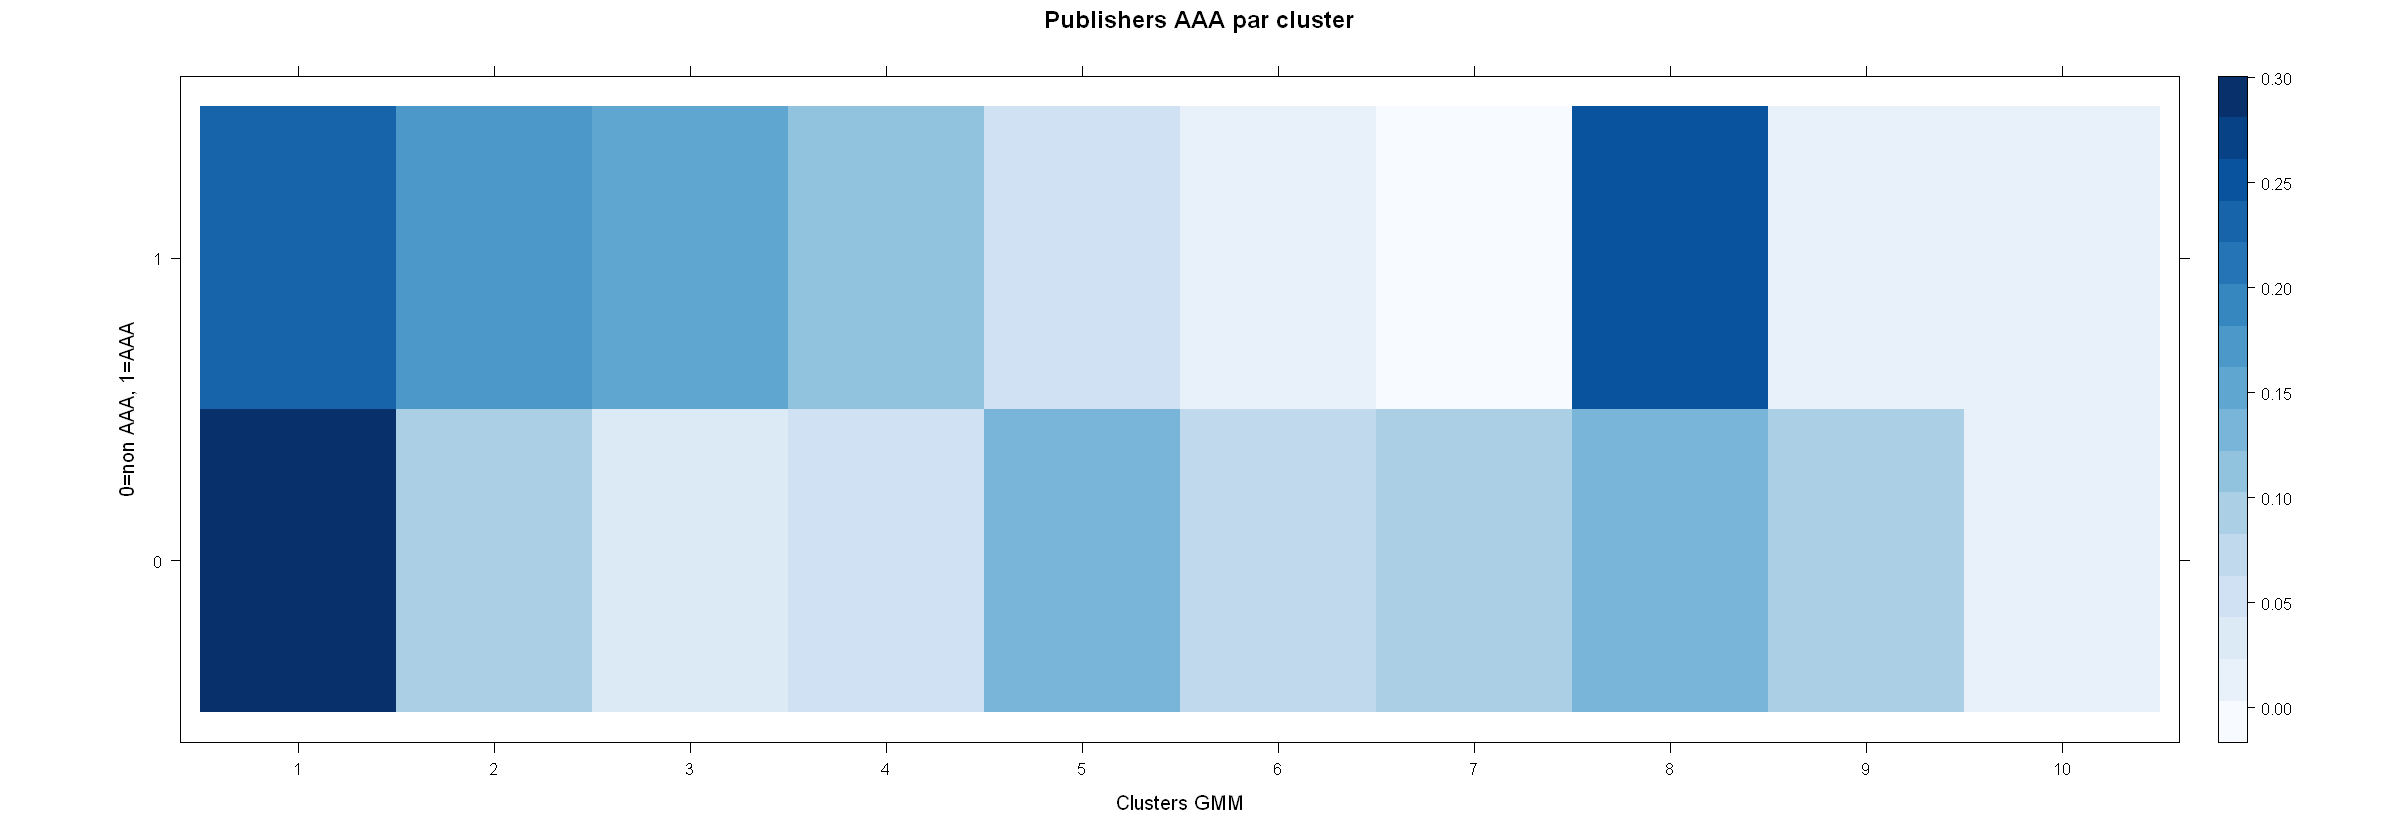

In [273]:
tab_prop_age <- prop.table(table(data.pop$cluster_gmm, data.pop$is_AAA), margin = 2)

coul <- colorRampPalette(brewer.pal(9, "Blues"))(100)

levelplot(tab_prop_age, 
          col.regions = coul, 
          main = "Publishers AAA par cluster",
          xlab = "Clusters GMM", 
          ylab = "0=non AAA, 1=AAA")

On remarque le cluster 3 avec les jeux au méga succès n'as pas la plus grosse part des jeux avec publishers AAA

#### Avec 5 clusters

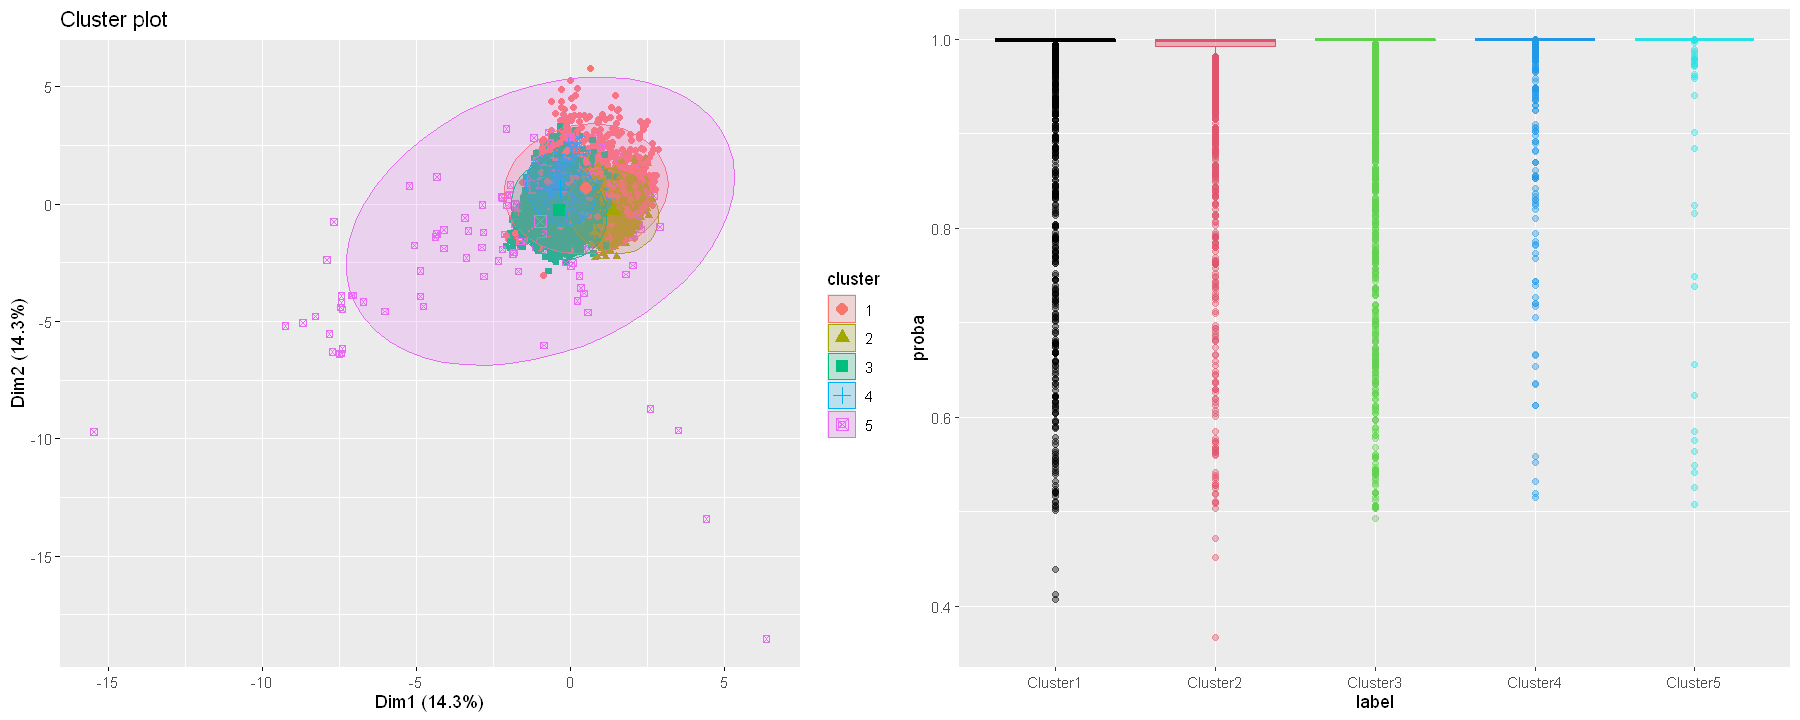

In [58]:
options(repr.plot.width = 15, repr.plot.height = 6)

K = 5
gmm5 = Mclust(pca.pop$ind$coord[,1:7], G=K, modelNames = "VEV")
p1 = fviz_cluster(gmm5, data=pca.pop$ind$coord[,1:7], ellipse.type="norm", geom="point")
aux = data.frame(
    label = paste("Cluster", gmm5$classification, sep=""), 
    proba = apply(gmm5$z, 1, max))

p2 = ggplot(aux, aes(x=label, y=proba)) + 
    geom_boxplot(colour=1:K, fill=1:K, alpha=.4)

grid.arrange(p1,p2,ncol=2)

In [67]:
cluster_gmm_count_5 = data.frame(table(gmm5$classification))
cluster_gmm_count_5

Var1,Freq
<fct>,<int>
1,1766
2,2129
3,7303
4,2674
5,260


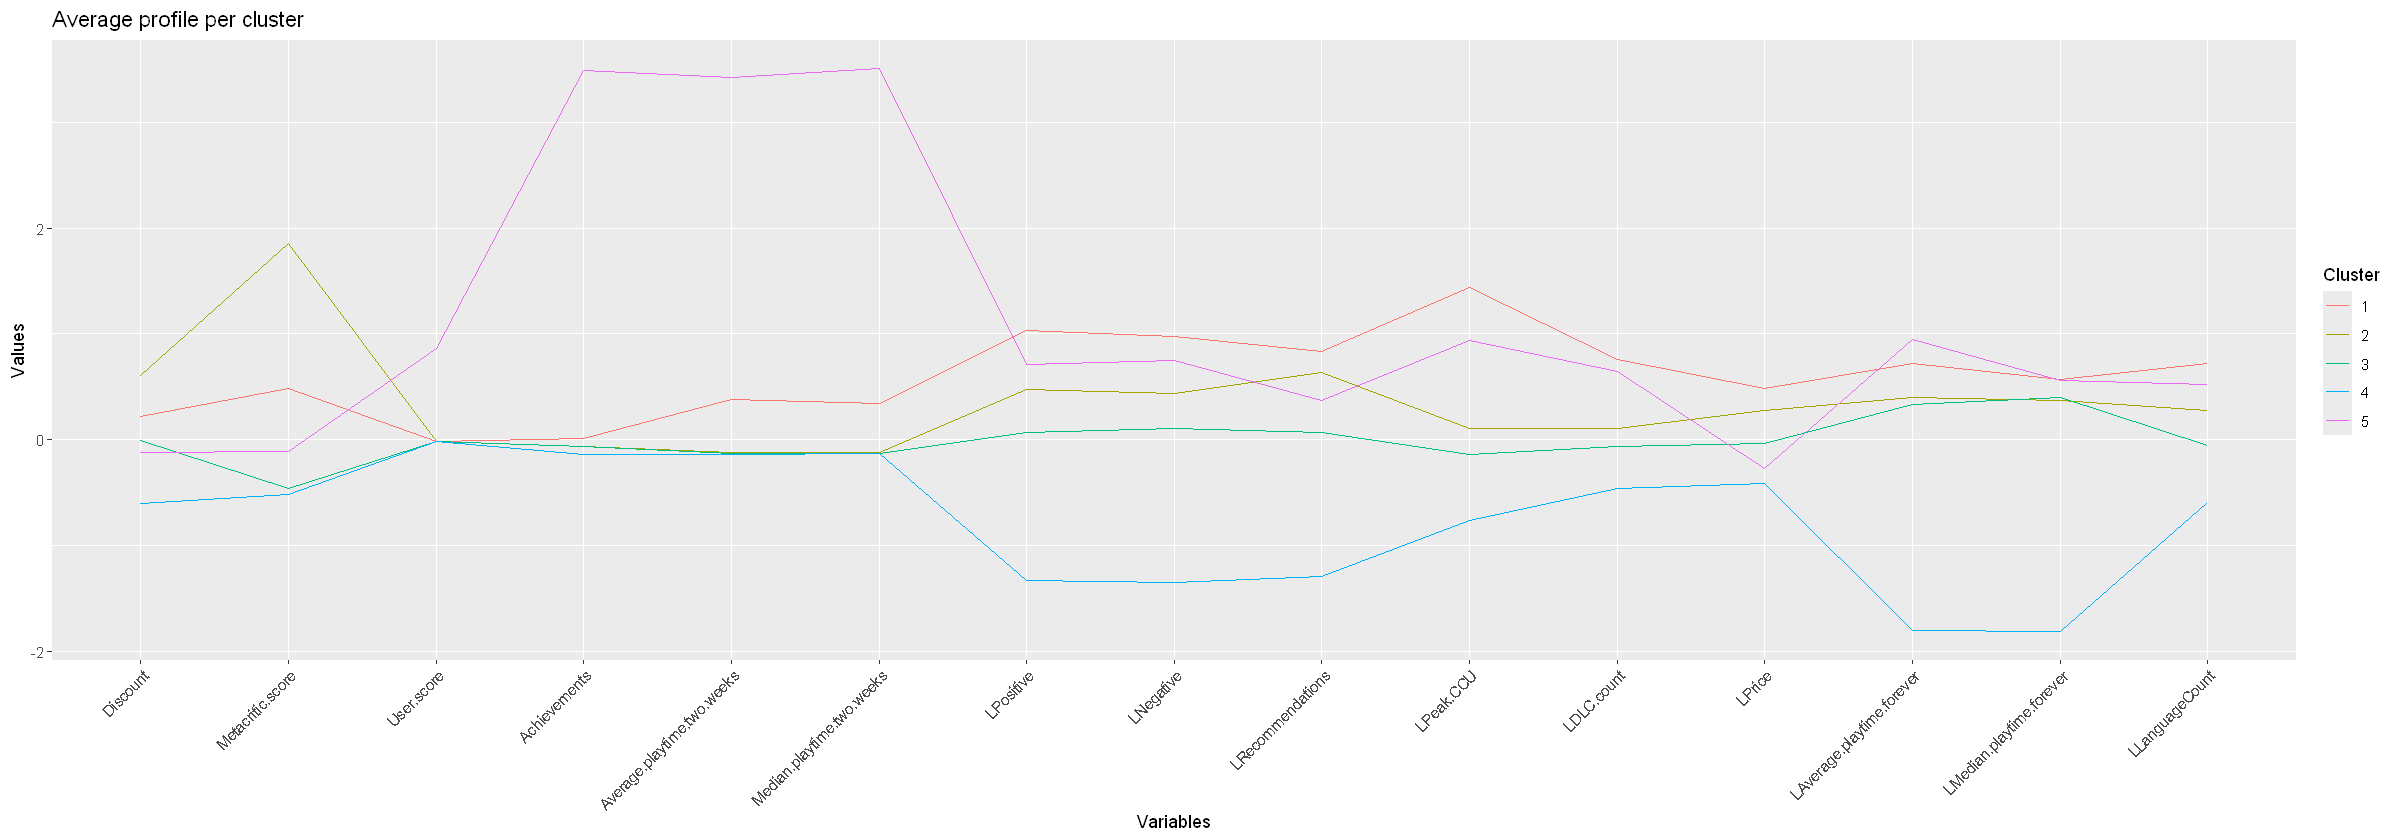

In [60]:
mean_profiles_gmm5 = aggregate(data.pop.scale, by = list(cluster = gmm5$classification), FUN = mean)
mean_profiles_gmm5 = melt(mean_profiles_gmm5, id.vars = "cluster")

ggplot(mean_profiles_gmm5, aes(x = variable, y = value, color = factor(cluster), group = cluster)) +
  geom_line() +  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Average profile per cluster", x = "Variables", y = "Values") +
  scale_color_discrete(name = "Cluster")

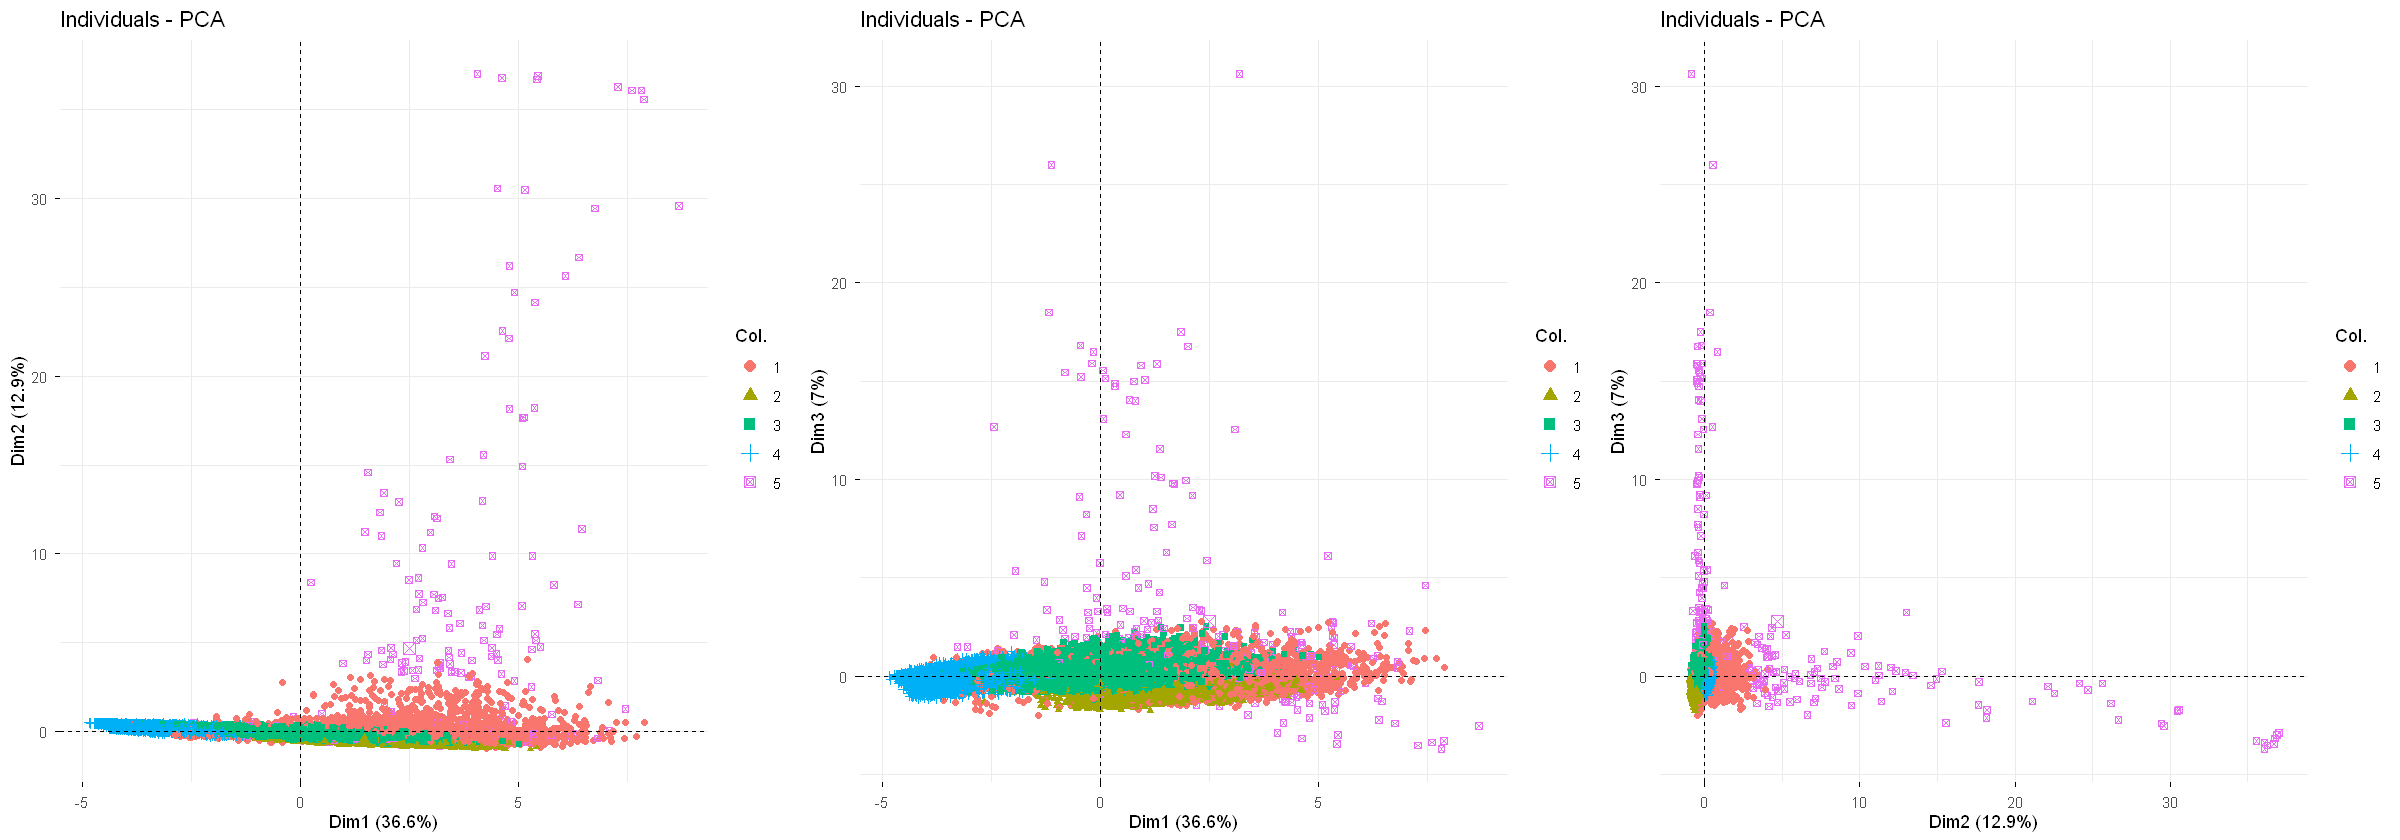

In [59]:
options(repr.plot.width = 20, repr.plot.height = 7)

grid.arrange(
    fviz_pca_ind(pca.pop, axes=c(1,2), geom = c("point"), col.ind=as.factor(gmm5$classification)),
    fviz_pca_ind(pca.pop, axes=c(1,3), geom=c("point"), col.ind=as.factor(gmm5$classification)),
    fviz_pca_ind(pca.pop, axes=c(2,3), geom=c("point"), col.ind=as.factor(gmm5$classification)),
    ncol=3)

In [62]:
library(lattice)
library(RColorBrewer)

tab_prop <- prop.table(table(data.pop$cluster_gmm, data.pop$Estimated.owners),margin = 2)

coul <- colorRampPalette(brewer.pal(9, "Blues"))(100)

levelplot(tab_prop, 
          col.regions = coul, 
          main = "Concentration des tranches d'owners par cluster",
          xlab = "Clusters GMM", 
          ylab = "Tranches d'Owners")

ERROR: Error in table(data.pop$cluster_gmm, data.pop$Estimated.owners): tous les arguments doivent avoir la même longueur


In [78]:
data.pop.quali=data.pop_genres %>% select(where(is.factor))
summary(data.pop.quali)

    Release.date   Estimated.owners  Required.age    Windows         Mac      
 1997-2013:1424   50K-100K :5349    0      :13369   False:    2   False:9978  
 2016     :1361   100K-200K:3450    17     :  580   True :14130   True :4154  
 2021     :1293   200K-500K:2845    13     :   95                             
 2020     :1284   500K-1M  :1150    18     :   49                             
 2017     :1149   1M-2M    : 720    16     :   21                             
 2023     :1149   2M-5M    : 400    10     :   10                             
 (Other)  :6472   (Other)  : 218    (Other):    8                             
   Linux       cluster_id_2 Genres_Action Genres_Adventure Genres_Casual
 False:11307   1:4766       0:7619        0:8166           0:10140      
 True : 2825   2:9366       1:6513        1:5966           1: 3992      
                                                                        
                                                                        
   

In [79]:
data.pop.quali=data.pop.quali %>% select(-c(Windows, Mac, Linux,cluster_id_2,Genres_))

In [81]:
publishers_aaa <- c("Valve", "Electronic Arts", "EA ", "Ubisoft", "Bandai Namco", 
                    "Capcom", "Xbox Game Studios", "Microsoft", "Bethesda", 
                    "2K", "SEGA", "Activision", "PlayStation Publishing", 
                    "Warner Bros", "Square Enix", "Rockstar Games", "KRAFTON, Inc")

data.pop.quali$is_AAA <- ifelse(grepl(paste(publishers_aaa, collapse = "|"), 
                                data.pop$Publisher, ignore.case = TRUE), 1, 0)

data.pop.quali$is_AAA <- as.factor(data.pop.quali$is_AAA)

summary(data.pop.quali)

    Release.date   Estimated.owners  Required.age   Genres_Action
 1997-2013:1424   50K-100K :5349    0      :13369   0:7619       
 2016     :1361   100K-200K:3450    17     :  580   1:6513       
 2021     :1293   200K-500K:2845    13     :   95                
 2020     :1284   500K-1M  :1150    18     :   49                
 2017     :1149   1M-2M    : 720    16     :   21                
 2023     :1149   2M-5M    : 400    10     :   10                
 (Other)  :6472   (Other)  : 218    (Other):    8                
 Genres_Adventure Genres_Casual Genres_Indie Genres_Racing Genres_Simulation
 0:8166           0:10140       0:5162       0:13643       0:11031          
 1:5966           1: 3992       1:8970       1:  489       1: 3101          
                                                                            
                                                                            
                                                                            
          

Attention: certaines genres sont sous-représenté dans ce dataset réduit. on ne prendra pas en compte les genres: **Accounting (5),mature(46),Outils(141)**

In [115]:
data.frame(table(data.pop.quali$Required.age))

Var1,Freq
<fct>,<int>
0,13369
1,1
3,0
6,1
7,1
10,10
12,4
13,95
14,0


Effectifs de required.age: la grande majorité des jeux n'en a pas (0) avec un effectif de 13369 sur 14132. => On peut la transformer en variable binaire, ce sera toujours déséquilibré mais comme les **Genres**.

Pour estimated.owners on ne regroupe pas mais on fera attention dans l'interprétation (au final en supplémentaires donc pas besoin).

In [123]:
data_mca <- data.pop.quali %>%
  mutate(Cluster = as.factor(gmm5$classification)) %>%
    mutate(Is.restricted = ifelse(Required.age !=0, "Retricted", "Not.restricted")) %>%
    mutate(Is.restricted = as.factor(Is.restricted)) %>%
    select(-c(Genres_Accounting,Genres_Mature,Genres_Outils,Required.age)) 
summary(data_mca)

    Release.date   Estimated.owners Genres_Action Genres_Adventure
 1997-2013:1424   50K-100K :5349    0:7619        0:8166          
 2016     :1361   100K-200K:3450    1:6513        1:5966          
 2021     :1293   200K-500K:2845                                  
 2020     :1284   500K-1M  :1150                                  
 2017     :1149   1M-2M    : 720                                  
 2023     :1149   2M-5M    : 400                                  
 (Other)  :6472   (Other)  : 218                                  
 Genres_Casual Genres_Indie Genres_Racing Genres_Simulation Genres_Sports
 0:10140       0:5162       0:13643       0:11031           0:13618      
 1: 3992       1:8970       1:  489       1: 3101           1:  514      
                                                                         
                                                                         
                                                                         
                    

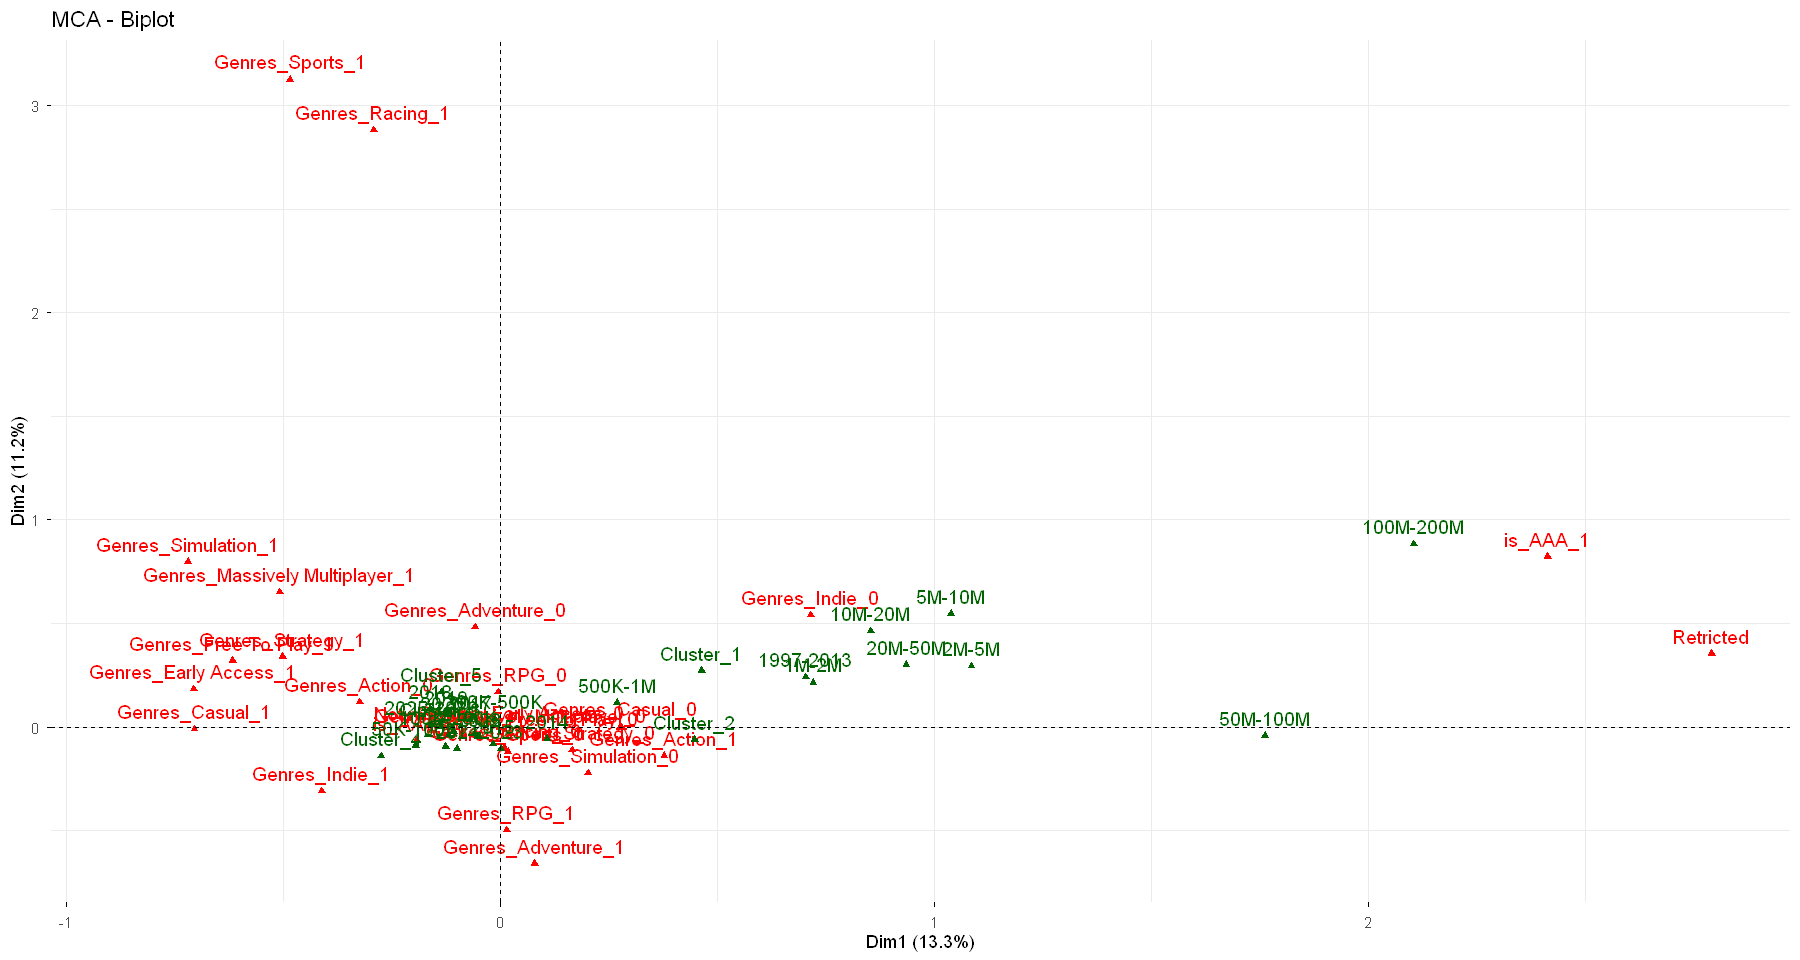

In [150]:
options(repr.plot.width = 15, repr.plot.height =8)
res.mca <- MCA(data_mca, quali.sup = c(16,1,2), graph = FALSE)

fviz_mca_biplot(res.mca, 
               label = "var",invisible = "ind") 

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


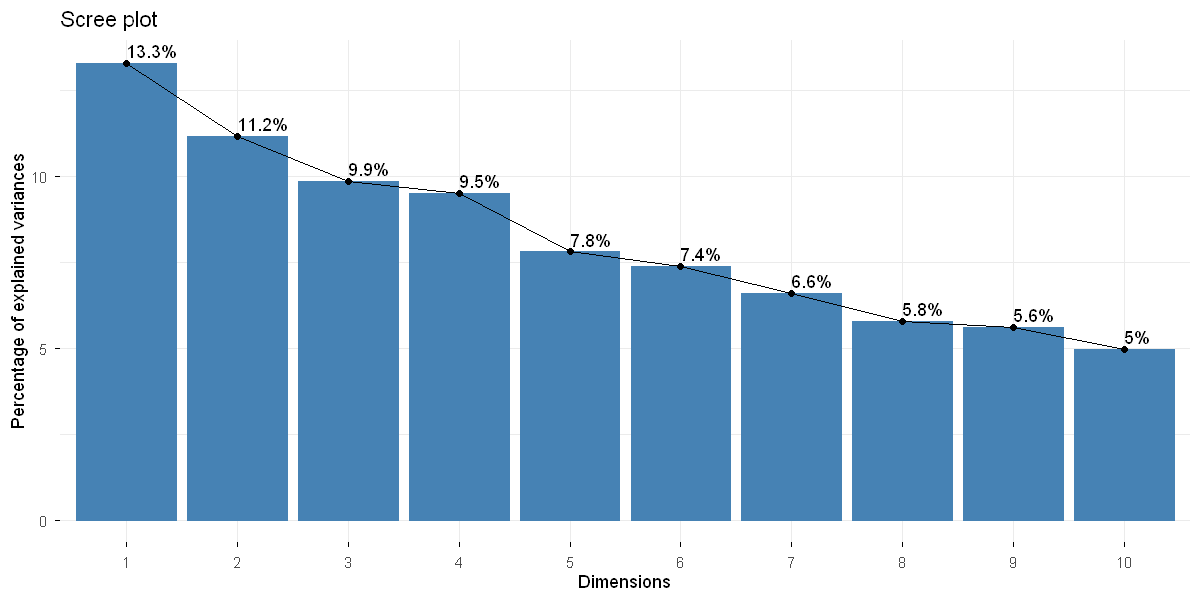

In [147]:
fviz_eig(res.mca, addlabels = TRUE)

On va voir si les clusters se séparent sur les 3 premières dimensions ou non.

**Contribution aux axes pour les interpréter**

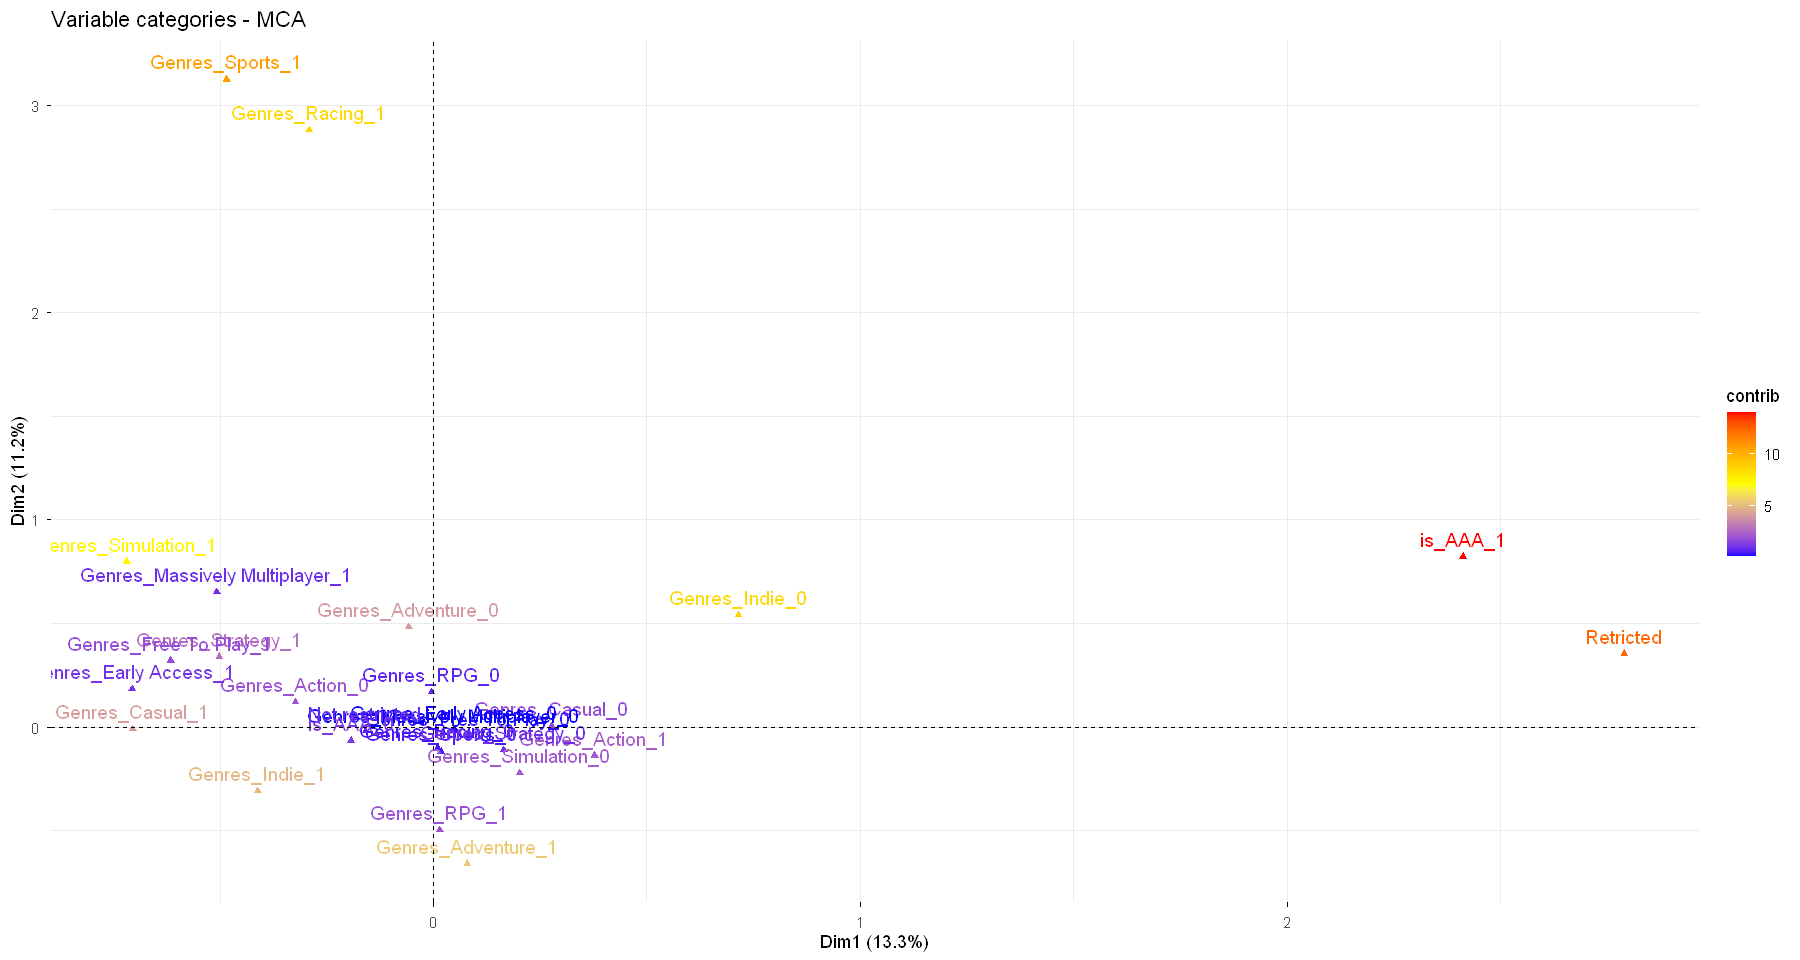

In [151]:
fviz_mca_var(res.mca, col.var = "contrib",
             gradient.cols = c("blue", "yellow", "red"),invisible = "quali.sup")

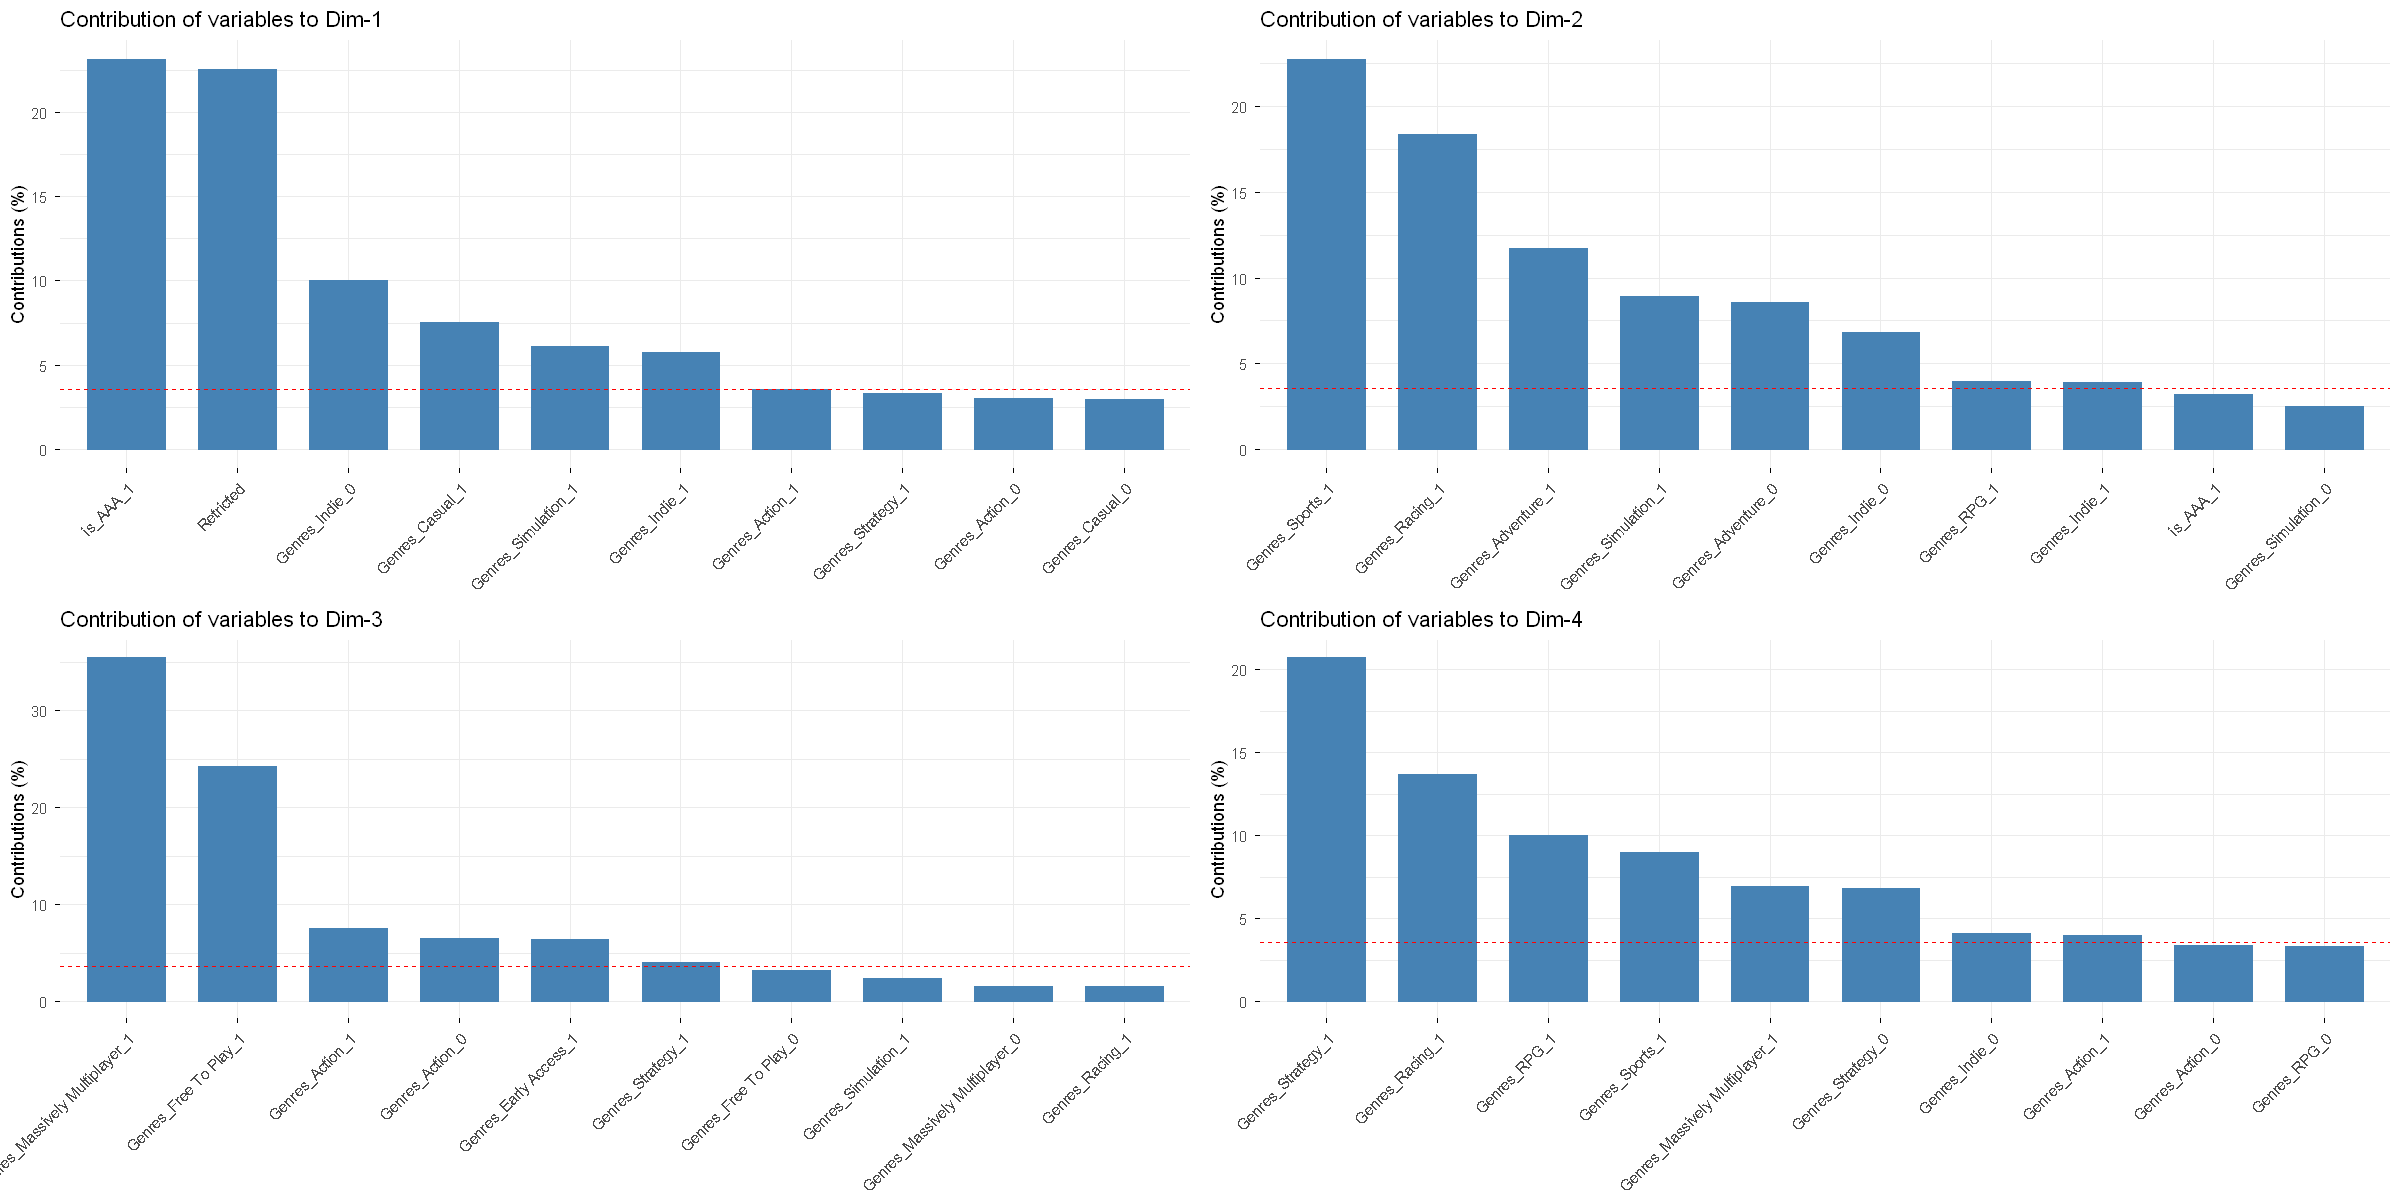

In [154]:
options(repr.plot.width = 20, repr.plot.height =10)

grid.arrange(fviz_contrib(res.mca, choice = "var", axes = 1, top = 10),fviz_contrib(res.mca, choice = "var", axes = 2, top = 10),fviz_contrib(res.mca, choice = "var", axes = 3, top = 10),fviz_contrib(res.mca, choice = "var", axes = 4, top = 10),ncol=2)

Axe 1 (~13%) : L'Axe de la "Professionnalisation"

À Droite : On trouve les jeux AAA_1, les restrictions d'âge (Is.restricted_Yes) et les jeux non-indépendants (Indie_0). C'est le monde des studios établis et des gros budgets.

À Gauche : On trouve le monde des Indie_1, souvent Casual ou Early Access. C'est la production indépendante classique.

Conclusion : Cet axe sépare le marché amateur/indé du marché industriel.

Axe 2 ( ~11%) : L'Axe du "Gameplay & Public"

En Haut : Dominé par Sports_1, Racing_1 et Simulation_1. Ce sont des jeux basés sur la performance ou le réalisme.

En Bas : Dominé par Adventure_1, RPG_1 et Strategy_1. Ce sont des jeux basés sur la narration, la réflexion et l'immersion longue.

Conclusion : Cet axe oppose les jeux "d'action immédiate/sport" aux jeux "d'investissement/aventure".

Dimension 3 (9.9%) : Le modèle économique. Elle met en avant les jeux Massively Multiplayer et Free to Play en haut de l'axe.

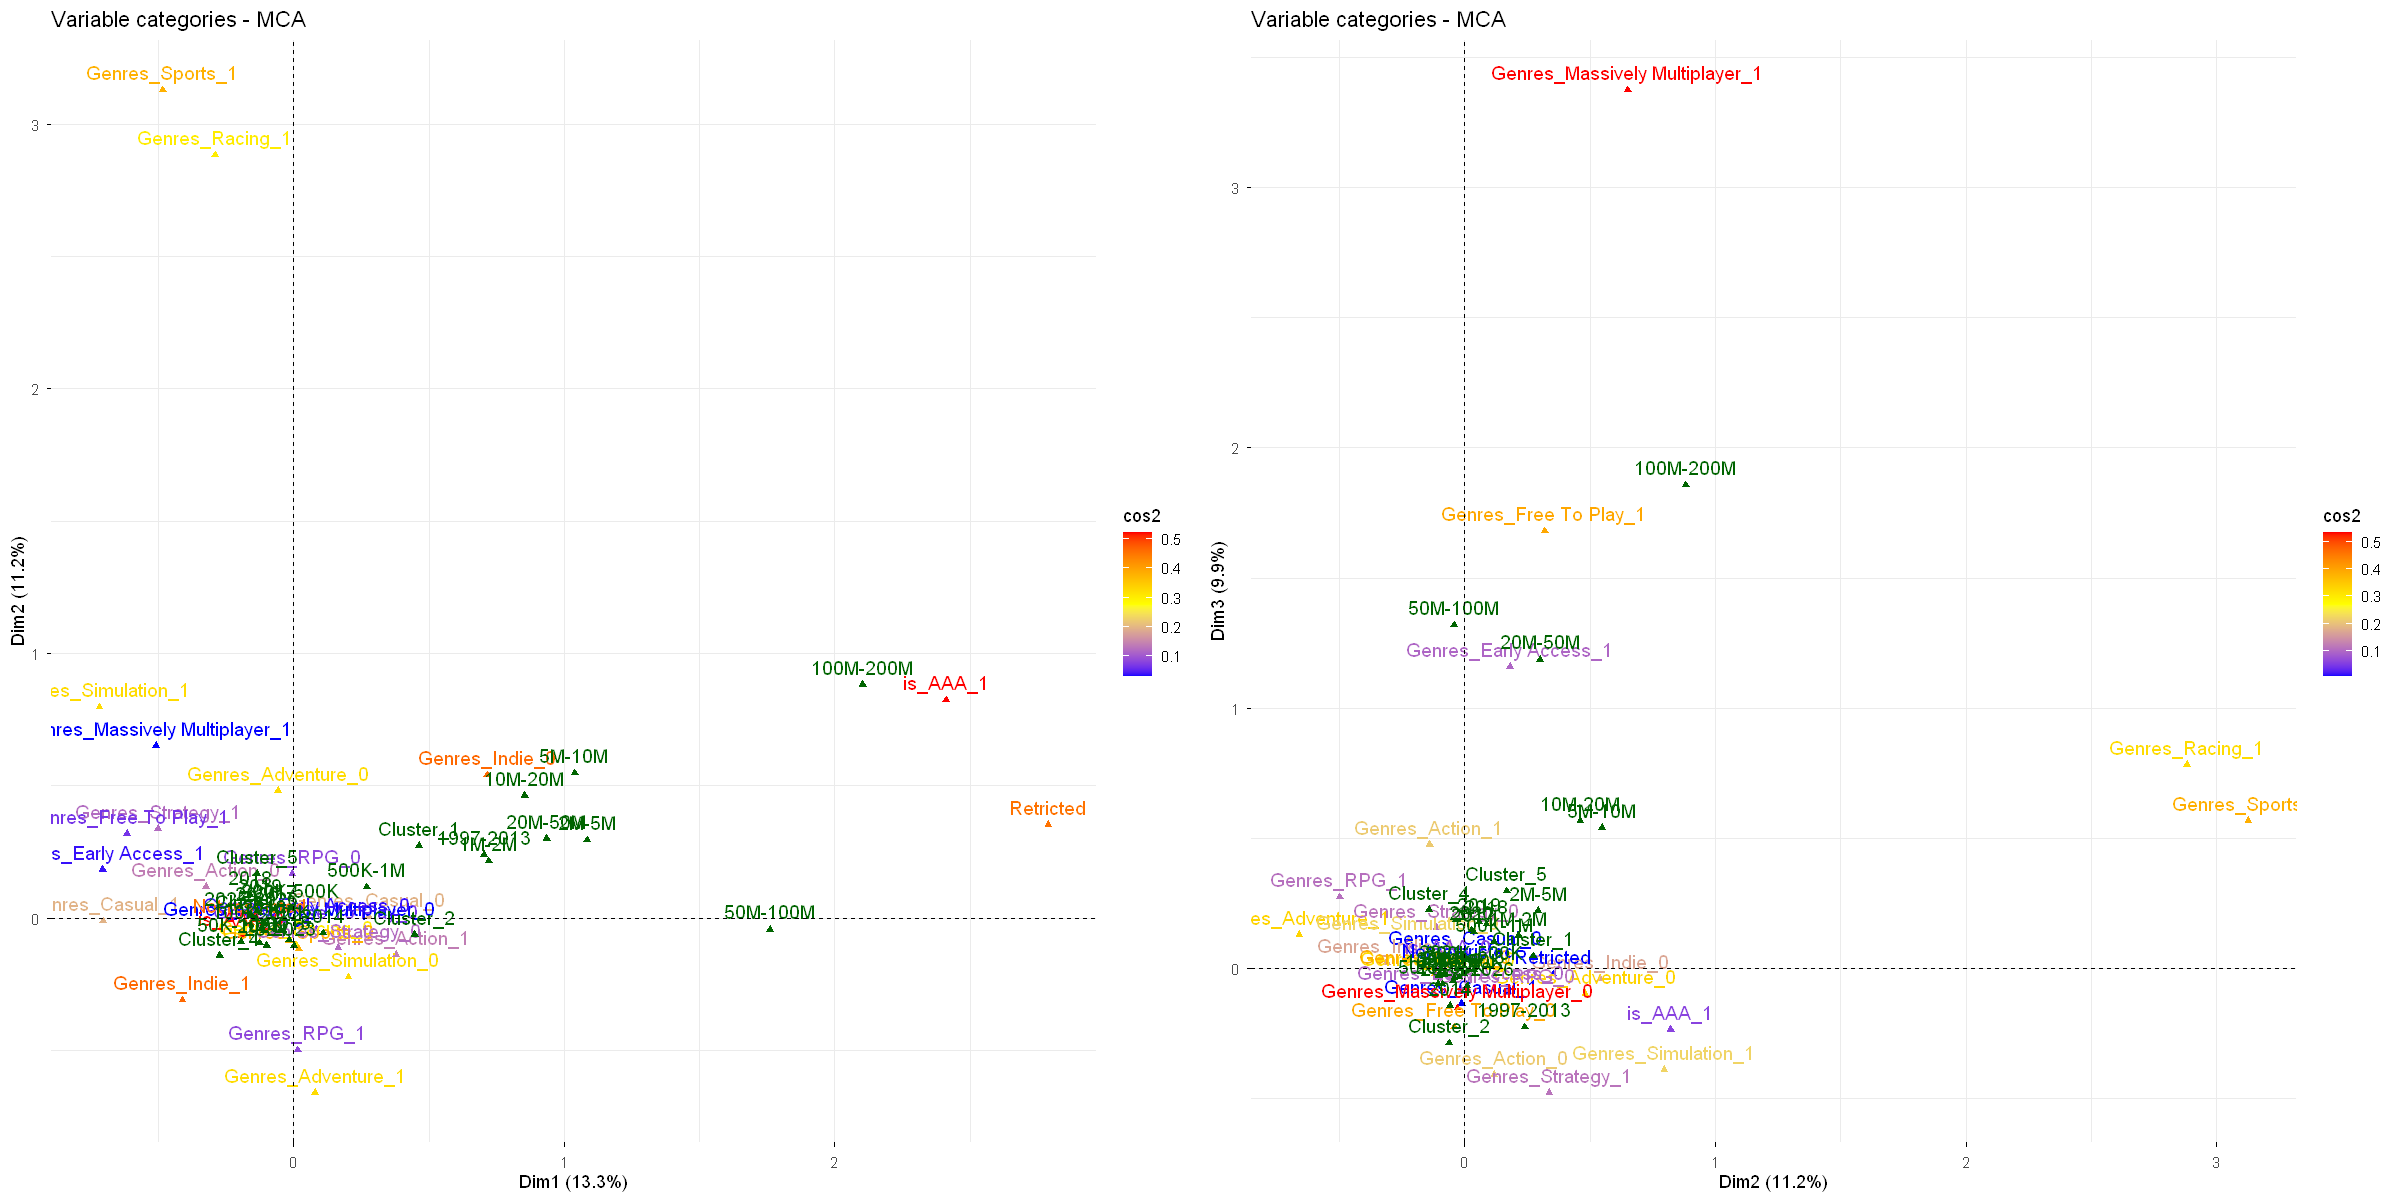

In [166]:
p1=fviz_mca_var(res.mca, col.var = "cos2",gradient.cols = c("blue", "yellow", "red"))
p2=fviz_mca_var(res.mca, col.var = "cos2",gradient.cols = c("blue", "yellow", "red"), axes=2:3)
grid.arrange(p1,p2,ncol=2)

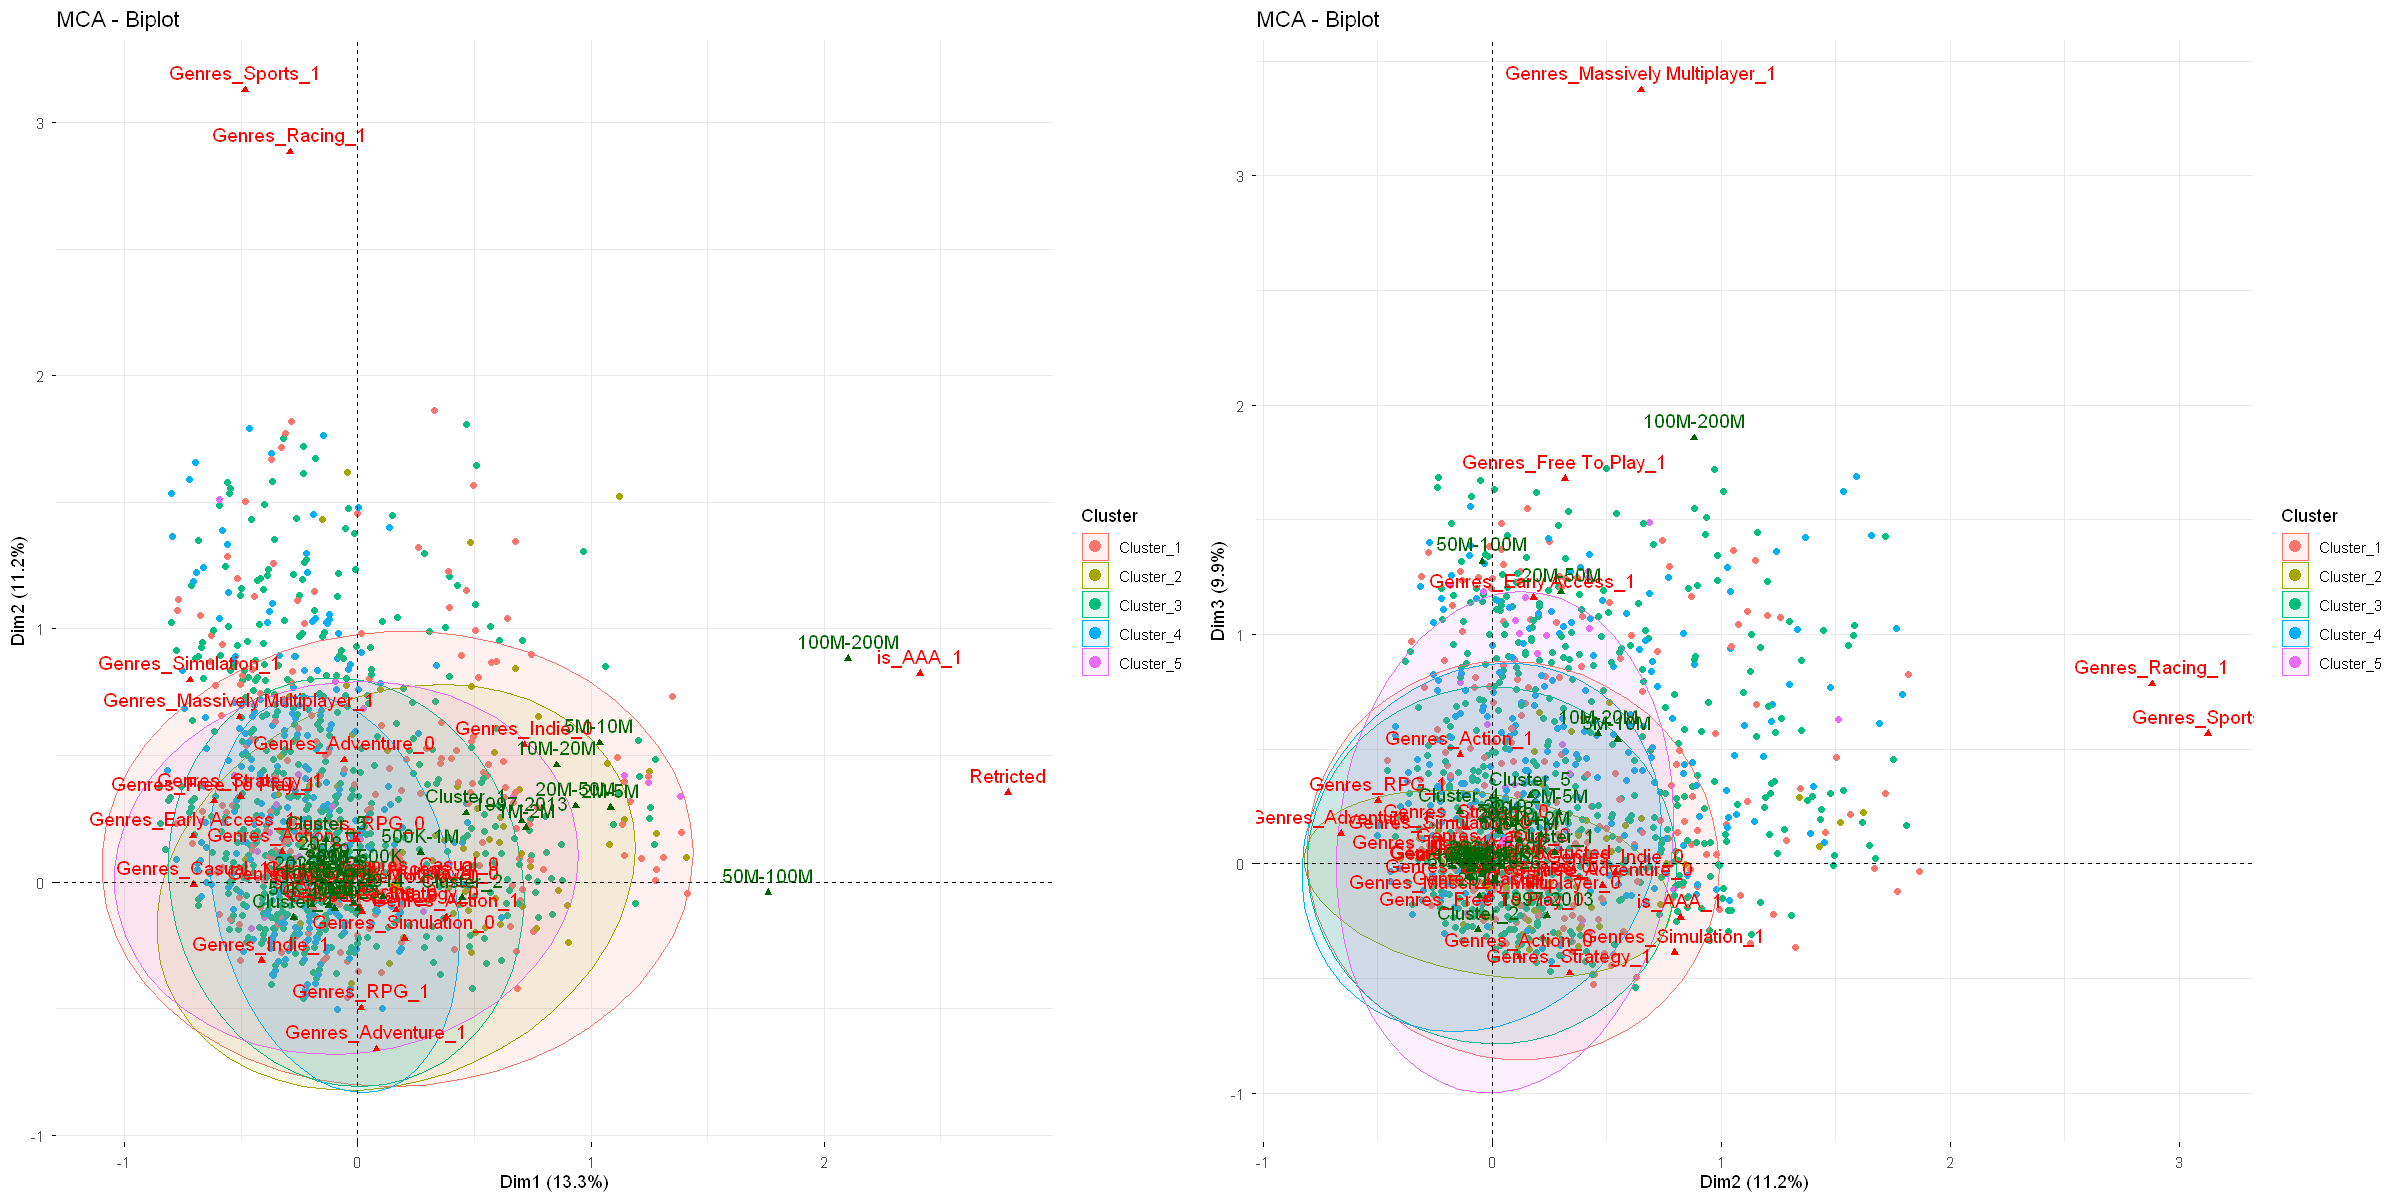

In [164]:
f1=fviz_mca_biplot(res.mca, 
               habillage = "Cluster", 
               addEllipses = TRUE, 
               label = "var")
f2=fviz_mca_biplot(res.mca, 
               habillage = "Cluster", 
               addEllipses = TRUE, 
               label = "var",
                axes=2:3)
grid.arrange(f1,f2,ncol=2)
#repel = TRUE

Le clustering montre que le succès sur Steam est multi-factoriel. Si les variables qualitatives (genres) ne suffisent pas à séparer nettement les groupes au centre, les clusters de tête (1 et 5) se distinguent par des signatures claires : le Cluster 1 suit un modèle industriel classique (AAA), tandis que le Cluster 5 s'appuie sur des modèles multijoueurs et persistants. Et Dimension 1 valide la domination commerciale des Clusters 1 et 2 (modèle AAA).

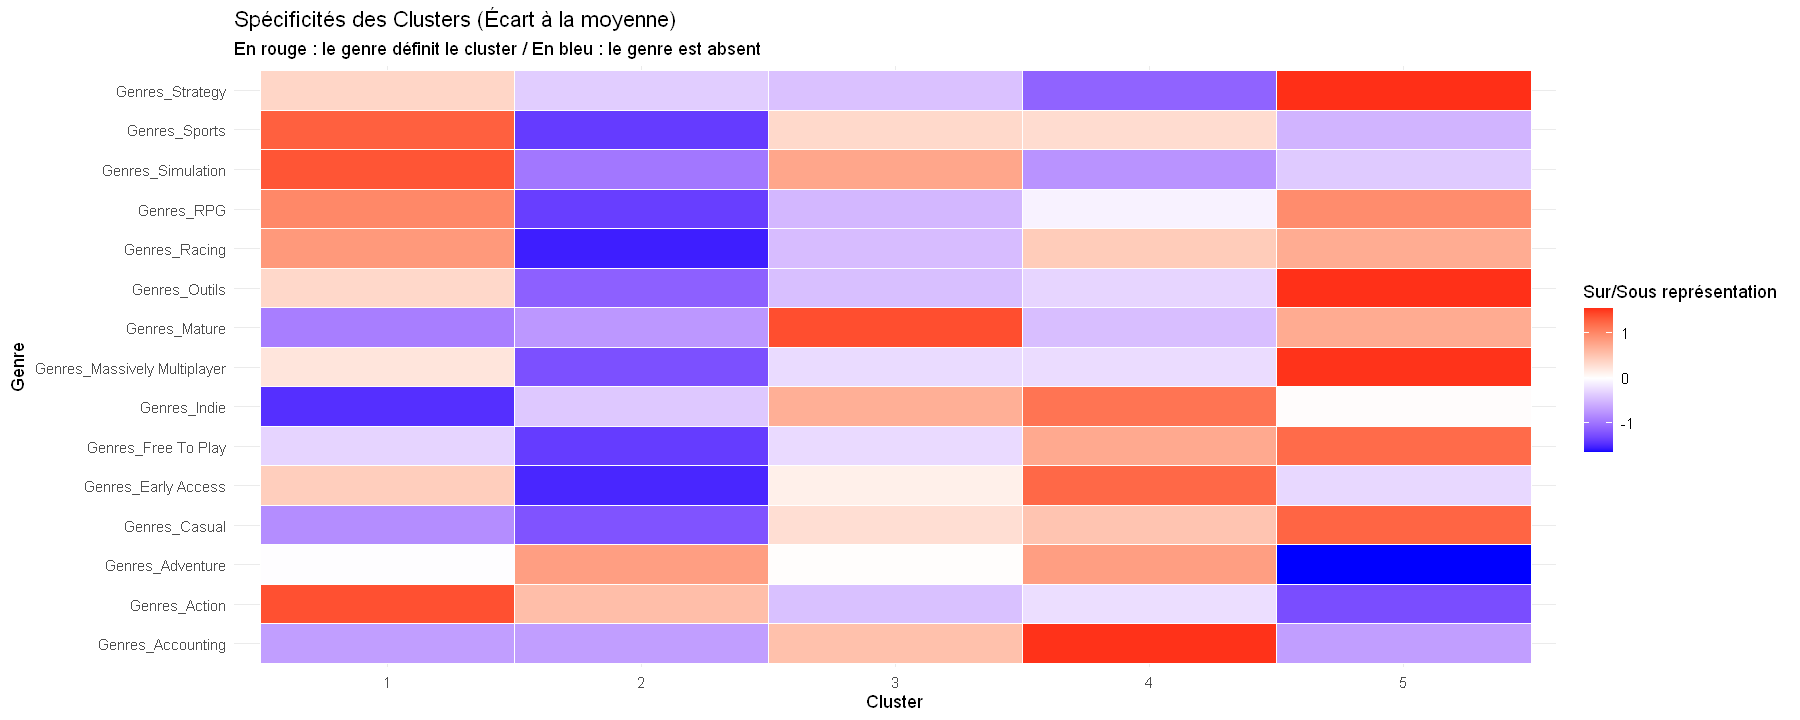

In [99]:
heatmap_stats <- data_mca %>%
  group_by(Cluster) %>%
  summarise(across(starts_with("Genres_"), ~ mean(as.numeric(as.character(.x)), na.rm = TRUE))) 

# 2. On normalise les fréquences des genres (écart à la moyenne par ligne)
# On soustrait la moyenne du genre et on divise par l'écart-type
heatmap_zscore <- heatmap_stats %>%
  mutate(across(-Cluster, ~ as.numeric(scale(.)))) %>%
  pivot_longer(cols = -Cluster, names_to = "Genre", values_to = "Zscore")

# 3. Affichage avec une échelle divergente (Bleu = Sous-représenté, Rouge = Sur-représenté)
ggplot(heatmap_zscore, aes(x = Cluster, y = Genre, fill = Zscore)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  labs(title = "Spécificités des Clusters (Écart à la moyenne)",
       fill = "Sur/Sous représentation",
       subtitle = "En rouge : le genre définit le cluster / En bleu : le genre est absent") +
  theme_minimal()

Cluster 5 (L'élite spécialisée) : C'est le plus intéressant ! Il est rouge vif sur Strategy, Massively Multiplayer, Free to Play et Casual. C'est un profil de jeux "service" ou compétitifs qui demandent beaucoup d'investissement (ce qui colle avec tes graphiques de playtime).

Cluster 2 (Le "Vide" relatif) : Il est très bleu partout. Cela signifie que c'est un cluster très "neutre" ou que ses jeux ne rentrent dans aucune des catégories classiques de manière marquée. C'est peut-être ton groupe de "Succès par la Critique" (Metacritic) qui ne dépend pas d'un genre précis.

Cluster 1 : Très marqué sur Sports, Racing, Simulation et Action. C'est le profil des "Simulations sportives" et des blockbusters d'action.

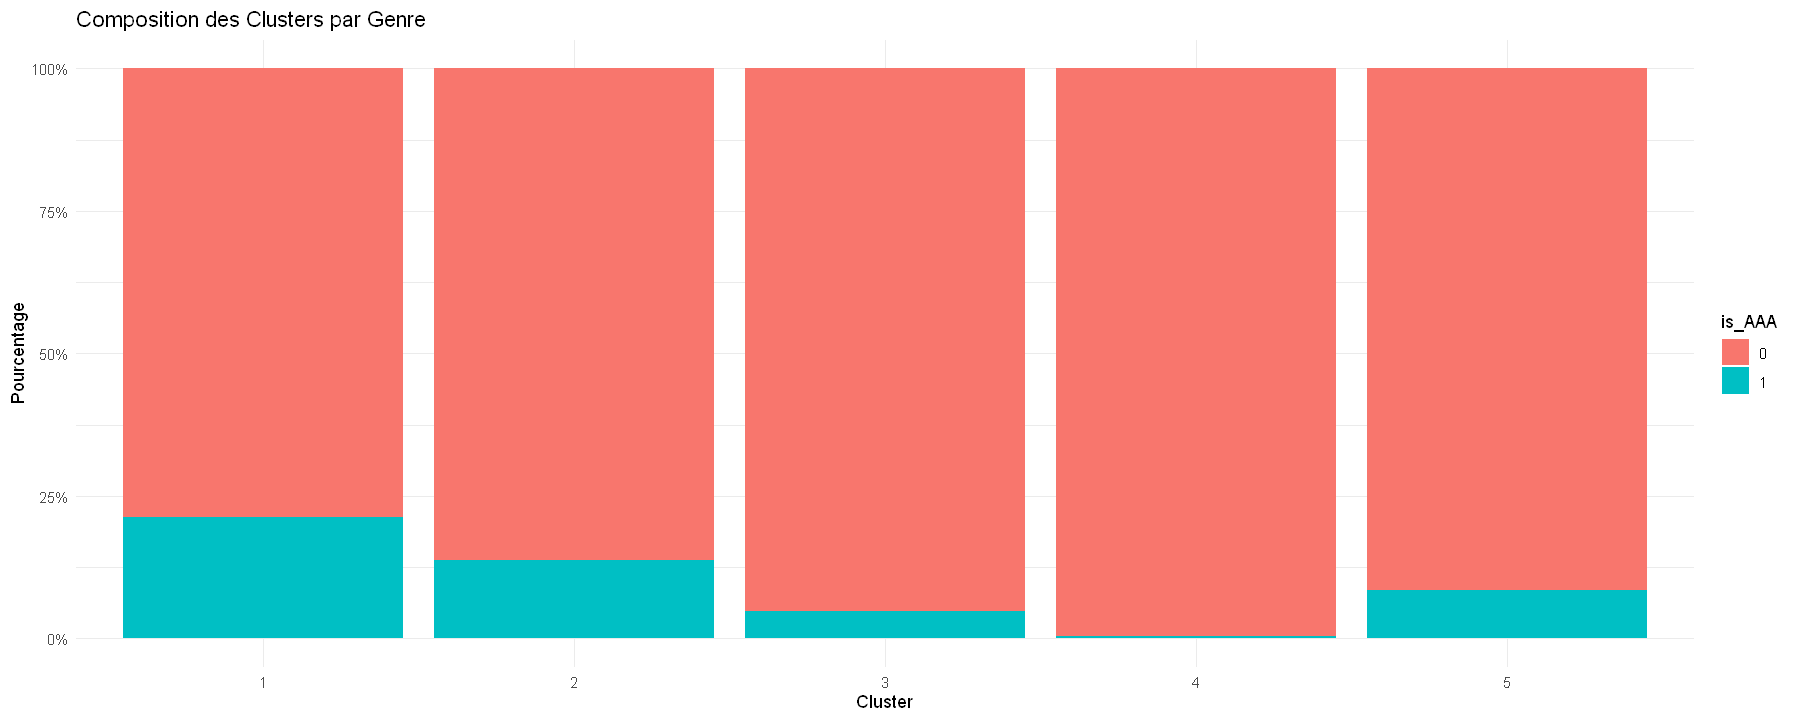

In [100]:
ggplot(data_mca, aes(x = Cluster, fill = is_AAA)) +
  geom_bar(position = "fill") + # "fill" met tout à 100% pour comparer les proportions
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Composition des Clusters par Genre",
       y = "Pourcentage",
       x = "Cluster") +
  theme_minimal()

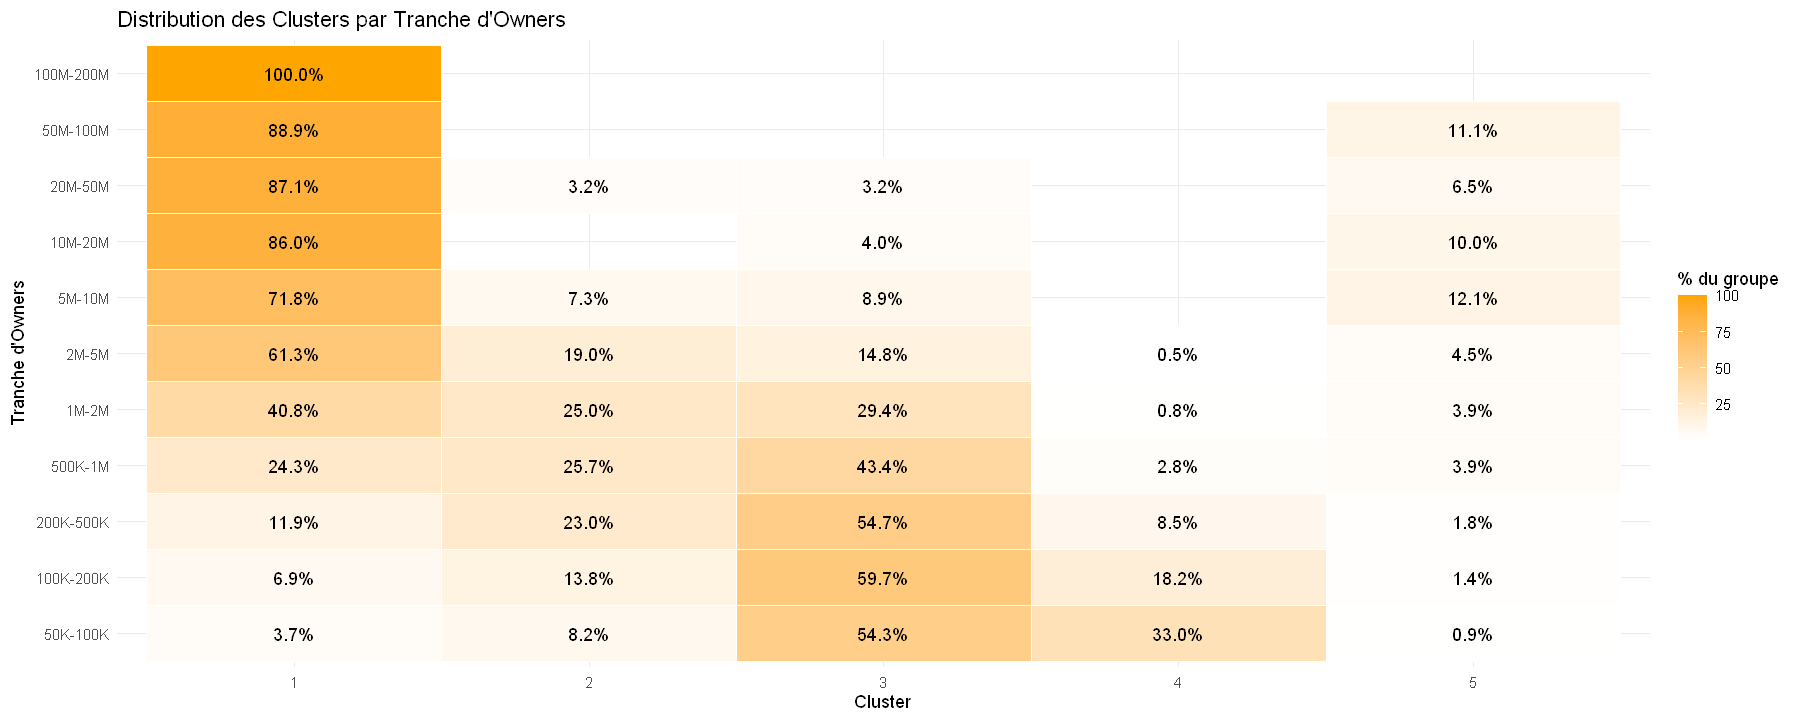

In [103]:
plot_data <- data_mca %>%
  group_by(Estimated.owners, Cluster) %>%
  tally() %>%
  group_by(Estimated.owners) %>%
  mutate(percentage = (n / sum(n)) * 100)

ggplot(plot_data, aes(x = Cluster, y = Estimated.owners, fill = percentage)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.1f%%", percentage)), color = "black") + # Affiche le %
  scale_fill_gradient(low = "white", high = "orange") +
  labs(title = "Distribution des Clusters par Tranche d'Owners",
       x = "Cluster",
       y = "Tranche d'Owners",
       fill = "% du groupe") +
  theme_minimal()

Point de vue "Marché" (Ventes) : On veut savoir comment les tranches de succès se répartissent. On utilise le calcul par ligne.

"Nous observons que plus le nombre d'owners augmente, plus la probabilité d'appartenir au Cluster 1 devient forte, atteignant 100% pour la tranche la plus haute."

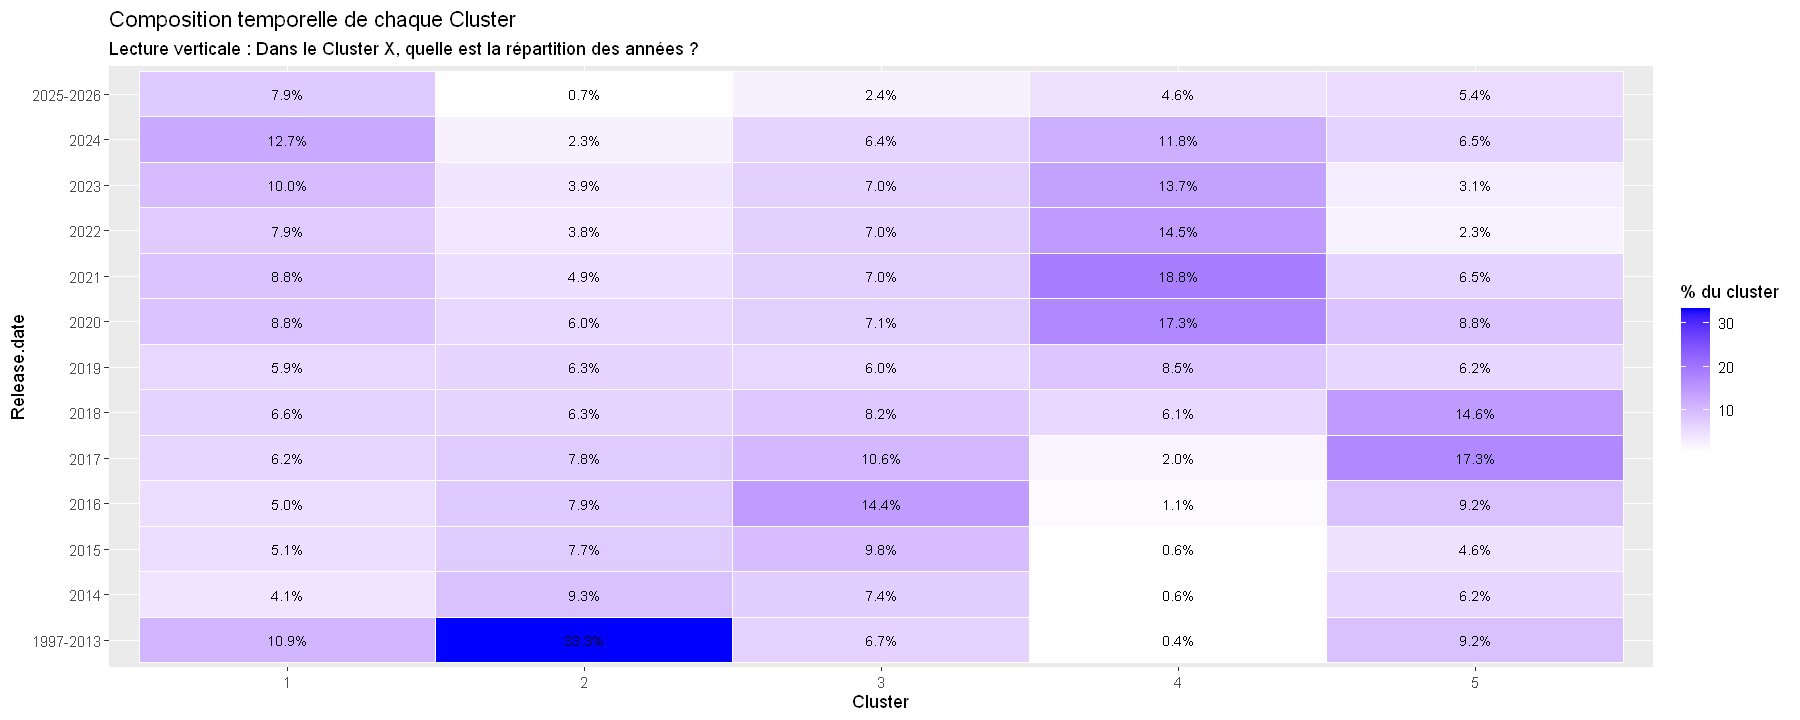

In [107]:
plot_data_inv <- data_mca %>%
  group_by(Cluster, Release.date) %>% # On inverse ici
  tally() %>%
  group_by(Cluster) %>% # On calcule le % au sein de chaque cluster
  mutate(percentage = (n / sum(n)) * 100)

ggplot(plot_data_inv, aes(x = Cluster, y = Release.date, fill = percentage)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.1f%%", percentage)), size = 3) +
  scale_fill_gradient(low = "white", high = "blue") +
  labs(title = "Composition temporelle de chaque Cluster",
       fill = "% du cluster")

In [112]:
data.frame(table(data_mca$Release.date))

Var1,Freq
<fct>,<int>
1997-2013,1424
2014,838
2015,999
2016,1361
2017,1149
2018,1050
2019,919
2020,1284
2021,1293


Point de vue "Profil" (Temps) : On veut connaître l'ADN du cluster. On utilise le calcul par colonne.
**Il faut vérifier aussi si il y a des différences d'effectifs entre les années**
"Chaque cluster possède une signature temporelle propre : le Cluster 2 regroupe les titres historiques de la plateforme, tandis que le Cluster 4 est le reflet de l'explosion du nombre de sorties ces quatre dernières années."

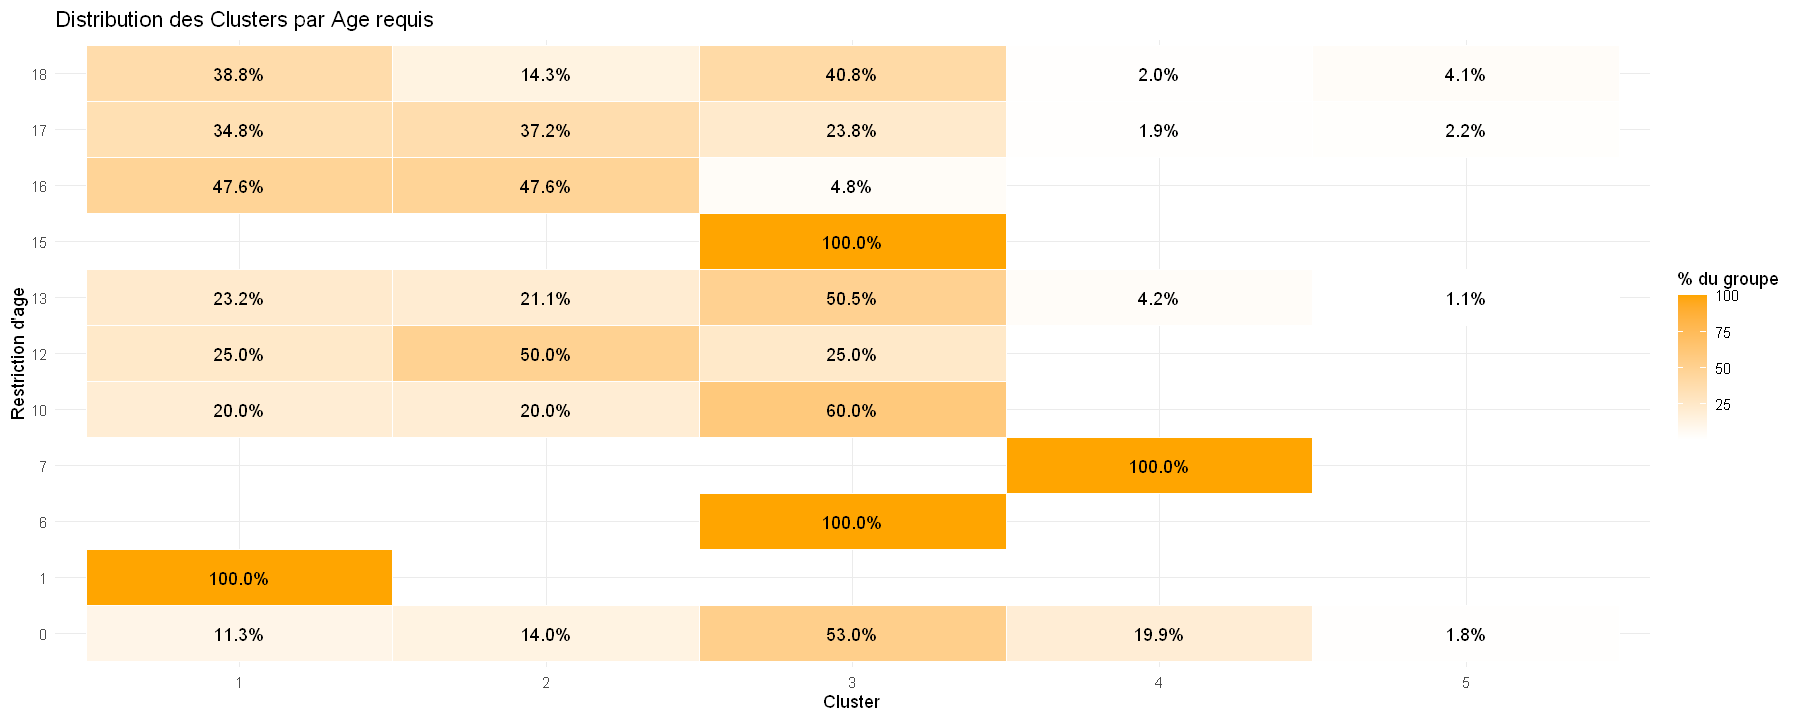

In [109]:
plot_data <- data_mca %>%
  group_by(Required.age, Cluster) %>%
  tally() %>%
  group_by(Required.age) %>%
  mutate(percentage = (n / sum(n)) * 100)

ggplot(plot_data, aes(x = Cluster, y = Required.age, fill = percentage)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.1f%%", percentage)), color = "black") + # Affiche le %
  scale_fill_gradient(low = "white", high = "orange") +
  labs(title = "Distribution des Clusters par Age requis",
       x = "Cluster",
       y = "Restriction d'age",
       fill = "% du groupe") +
  theme_minimal()

In [111]:
data.frame(table(data_mca$Required.age))

Var1,Freq
<fct>,<int>
0,13369
1,1
3,0
6,1
7,1
10,10
12,4
13,95
14,0


Au final pas de MCA car trop mauvaise:
Priorité aux variables structurantes : Les variables de performance (quantitatives) ont une variance beaucoup plus élevée et définissent des frontières claires entre les jeux (ex: le fossé entre un hit et un jeu moyen).

Validation externe : Utiliser le qualitatif en "post-traitement" permet de vérifier si les clusters mathématiques correspondent à des réalités métiers (ex: "Mon cluster de succès contient-il les éditeurs AAA ?").

Éviter le bruit : Une MCA sur des centaines de genres aurait introduit trop de "bruit" statistique, ce qui aurait pu rendre les clusters PCA moins précis.
Si ta MCA seule est mauvaise, la FAMD risque de l'être aussi ou d'être totalement dominée par les variables quantitatives.

# Quels sont les déterminants du profil d'un jeu évalué par la presse spécialisée (le score Metacritic) ?

Le score Métacritic est une note sur 100 représentant la moyenne pondérée des avis de journalistes et médias professionnels. Il accorde plus d'importance aux critiques les plus détaillées et prestigieuses. L'étude 1 sur les types de succès à montré que le cluster 2 est caractérisé par un score métacritic beaucoup plus élevé que la moyenne. Mais, étonnamment ce cluster n'est pas celui le plus marqué par les variables de succès (*Recommendation*, *Positive*, *Negative*, *PeakCCU*). En s'intéressant plus en détail aux jeux avec le plus de propriaitaires estimés n'ont même pas tous un score métacritic (valeur de la variable à 0), seulement 5 jeux sur les 13 ayant de plus 50 millions de propriétaires ont un score. Dans cette partie, en se demander si certaines de nos variables peuvent indiquer la présence de ce score.

**Quelles variables influencent la probabilité pour un jeu d'obtenir une évaluation Metacritic ?**

Pour répondre à cette problématique, on utilise une régression logistique.

In [86]:
summary(data_ready)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

On choisit de garder des variables qui ne sont pas redondantes comme les *playtimes* (seulement LAverage.playtime.forever) et qui n'ont pas trop de modalités comme *Genres*, *Tags*, *Categories*. On exclut aussi la variable *Window* car seulement 44 jeux ne l'ont pas.

In [169]:
# Création de la variable binaire A_un_score
data_ready <- data_ready %>% mutate(A_un_score = if_else(Metacritic.score > 0, 1, 0))

data_ready$A_un_score <- as.factor(data_ready$A_un_score)

# Sélection des variables explicatives que l'on choisit
data_reglog<- data_ready %>% select(A_un_score, LPrice, LLanguageCount, Achievements, Estimated.owners, LPositive, LNegative, Release.date, Required.age, LAverage.playtime.forever, LPeak.CCU, LDLC.count, Discount,Mac, Linux)

### Régression logistique

In [170]:
# On lance le modèle complet
modele_complet <- glm(A_un_score ~ LPrice + LLanguageCount + Achievements + 
                      LDLC.count + LPositive + LNegative + LPeak.CCU  +LAverage.playtime.forever + Estimated.owners
                      + Required.age + Release.date + Discount + Mac+ Linux,
                      data = data_reglog, family = binomial)

Pour sélectionner le modèle optimal, nous avons privilégié le critère BIC. Ce dernier pénalise plus fortement la complexité du modèle, un choix pertinent au vu de notre grand nombre de variables et du grand nombre de modalités pour certaines variables.

In [172]:
# Procédure BIC
modele_BIC <- step(modele_complet, k = log(nrow(data_reglog)),direction = "backward")

Start:  AIC=19187.2
A_un_score ~ LPrice + LLanguageCount + Achievements + LDLC.count + 
    LPositive + LNegative + LPeak.CCU + LAverage.playtime.forever + 
    Estimated.owners + Required.age + Release.date + Discount + 
    Mac + Linux

                            Df Deviance   AIC
- Required.age              14    18650 19081
- Estimated.owners          13    18640 19083
- Linux                      1    18593 19176
- LNegative                  1    18594 19176
<none>                            18593 19187
- Achievements               1    18607 19189
- Mac                        1    18625 19207
- LDLC.count                 1    18676 19258
- LAverage.playtime.forever  1    18692 19274
- LPeak.CCU                  1    18763 19346
- LLanguageCount             1    18867 19450
- Discount                   1    18987 19569
- LPositive                  1    18990 19573
- LPrice                     1    19075 19657
- Release.date              12    20645 21099

Step:  AIC=19081.44
A_un


Call:
glm(formula = A_un_score ~ LPrice + LLanguageCount + Achievements + 
    LDLC.count + LPositive + LPeak.CCU + LAverage.playtime.forever + 
    Release.date + Discount + Mac, family = binomial, data = data_reglog)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -5.5605036  0.1056836 -52.615  < 2e-16 ***
LPrice                     0.5543737  0.0251213  22.068  < 2e-16 ***
LLanguageCount             0.4541149  0.0250982  18.094  < 2e-16 ***
Achievements              -0.0007600  0.0002658  -2.859  0.00425 ** 
LDLC.count                 0.2583745  0.0282544   9.145  < 2e-16 ***
LPositive                  0.5426657  0.0162958  33.301  < 2e-16 ***
LPeak.CCU                 -0.2560817  0.0164874 -15.532  < 2e-16 ***
LAverage.playtime.forever  0.1367026  0.0118689  11.518  < 2e-16 ***
Release.date2014          -1.6662051  0.0919513 -18.121  < 2e-16 ***
Release.date2015          -2.0124204  0.0886491 -22.701  < 2e-16 ***
Releas

In [173]:
summary(modele_BIC)


Call:
glm(formula = A_un_score ~ LPrice + LLanguageCount + Achievements + 
    LDLC.count + LPositive + LPeak.CCU + LAverage.playtime.forever + 
    Release.date + Discount + Mac, family = binomial, data = data_reglog)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -5.5605036  0.1056836 -52.615  < 2e-16 ***
LPrice                     0.5543737  0.0251213  22.068  < 2e-16 ***
LLanguageCount             0.4541149  0.0250982  18.094  < 2e-16 ***
Achievements              -0.0007600  0.0002658  -2.859  0.00425 ** 
LDLC.count                 0.2583745  0.0282544   9.145  < 2e-16 ***
LPositive                  0.5426657  0.0162958  33.301  < 2e-16 ***
LPeak.CCU                 -0.2560817  0.0164874 -15.532  < 2e-16 ***
LAverage.playtime.forever  0.1367026  0.0118689  11.518  < 2e-16 ***
Release.date2014          -1.6662051  0.0919513 -18.121  < 2e-16 ***
Release.date2015          -2.0124204  0.0886491 -22.701  < 2e-16 ***
Releas

On remarque que la variable *Estimated.owners* n'a pas été retenu par la sélection de modèle ce qui confirme notre constat initial (les jeux avec le plus de propriétaires n'ont pas forcément un score).

Les coefficients de la régression expriment l'effet de chaque variable sur les chances que l'événement se produise (ici, avoir un score Metacritic), toutes choses égales par ailleurs. Un coefficient positif indique que la variable augmente la probabilité de présence d'un score, tandis qu'un coefficient négatif la diminue.

De ce fait, on remarque que les variables suivantes ont un effet positif sur la présence d'un score:
- LPrice (0.55): Plus le prix est élevé, plus le jeu a de chances d'être noté.
- LPositive (0.54): Plus un jeu a de reviews positives sur Steam, plus il a de chances d'avoir attiré l'attention de la presse.
- LLanguageCount (0.45): Un jeu traduit en beaucoup de langues est plus susceptible d'être évalué. C'est aussi un indicateur de l'investissement et du budget par l'éditeur, car la localisation d'un titre représente un coût financier important.


On observe aussi des freins:
- Release.date (Tous négatifs et très forts): La modalité de référence est la période la plus ancienne: 1997-2013. Le fait que tous les coefficients soient négatifs et de plus en plus intenses signifie que plus on avance dans le temps, moins un jeu a de chances d'avoir un score Metacritic. On peut potentiellement expliquer cela par l'explosion du nombre de jeux sur Steam au fil des années qui intensifie donc la concurrence pour obtenir une note. Cela rendrait l'obtention d'une note de plus en plus sélective au fil des années.
- Le coefficient négatif de LPeak.CCU (-0,27) suggère que les jeux avec des pics de joueurs simultanés très élevés ne sont pas forcément les cibles privilégiées des critiques.

In [108]:
cbind(Odds_Ratio = exp(modele_BIC$coefficients))

,Odds_Ratio
(Intercept),0.005593391
LPrice,1.588441815
LLanguageCount,1.669128353
Achievements,0.999080736
LDLC.count,1.339691185
LPositive,1.775584830
LPeak.CCU,0.760939701
LAverage.playtime.forever,1.170468535
Release.date2014,0.194928262
Release.date2015,0.135931006


L'analyse des Odds Ratios permet de quantifier l'impact réel des variables sur la probabilité pour un jeu d'obtenir un score Metacritic. Puisque les variables de performance et de prix sont exprimées en échelle logarithmique, une unité supplémentaire correspond ici à une multiplication de la valeur réelle par environ 2,7.

L'effet le plus puissant est temporel : le simple fait de sortir un jeu en 2024 divise les chances d'obtenir un score par près de 50 ($OR \approx 0,02$) par rapport à la période de référence.

L'effet positif le plus marqué parmi les variables est celui de LPositive, avec un ratio de 1,77. Concrètement, cela signifie qu'à caractéristiques égales, chaque multiplication du nombre de reviews positives par 2,71 (augmentation de une unité sur $Log(Positives)$ entraîne une multiplication des chances d'obtenir un score Metacritic par 1,77 (soit une hausse de 77 %).

On retrouve aussi de manière cohérente les variables identifiées précédemment comme leviers ou freins à la visibilité critique.

**Conclusion**

**Etudier pourquoi il y a de plus en plus de jeux qui sortent?**